# Simulación de Decisión Global con N=3 Agentes
## Estimación del Centroide #4 (2.5, 2.5)

Este notebook implementa:
1. Un entorno con 5 centroides predefinidos en ℝ²
2. 3 agentes que intentan estimar el centroide #4
3. Observaciones con ruido Gaussiano (diferente para cada agente)
4. Dinámica de actualización de creencias 
6. Visualización de la evolución de los estados y trayectorias

## 1. Importación de librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

# Configuración para reproducibilidad
np.random.seed(42)
random.seed(42)

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 2. Definición de los Centroides

Definimos 5 puntos en ℝ² como posibles centros de clúster. El objetivo es estimar el centroide #4.

Centroides definidos:
  Centroide 1: [0. 0.]
  Centroide 2: [5. 0.]
  Centroide 3: [0. 5.]
  Centroide 4: [2.5 2.5] <--- OBJETIVO
  Centroide 5: [5. 5.]


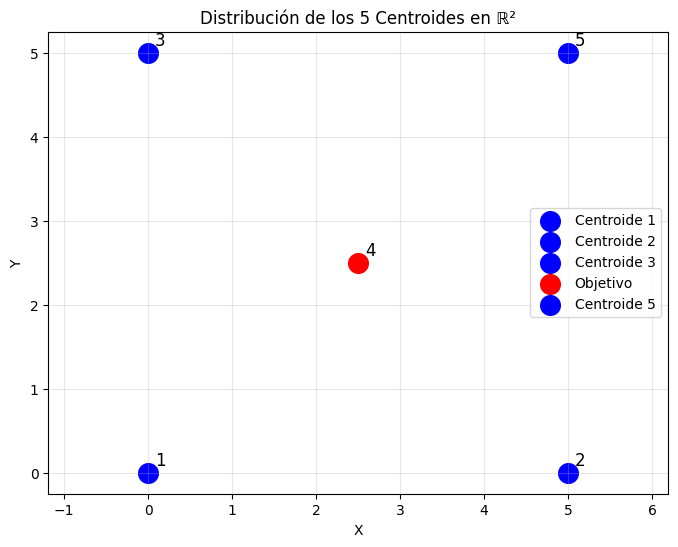

In [2]:
# Definición de los 5 centroides
centroides = {
    0: np.array([0.0, 0.0]),      # Centroide 1
    1: np.array([5.0, 0.0]),      # Centroide 2
    2: np.array([0.0, 5.0]),      # Centroide 3
    3: np.array([2.5, 2.5]),      # Centroide 4 (OBJETIVO)
    4: np.array([5.0, 5.0])       # Centroide 5
}

centroide_objetivo = 3  # Índice del centroide que queremos estimar (2.5, 2.5)
centroide_objetivo_coords = centroides[centroide_objetivo]

print("Centroides definidos:")
for idx, coord in centroides.items():
    marker = " <--- OBJETIVO" if idx == centroide_objetivo else ""
    print(f"  Centroide {idx+1}: {coord}{marker}")

# Visualización
plt.figure(figsize=(8, 6))
for idx, coord in centroides.items():
    color = 'red' if idx == centroide_objetivo else 'blue'
    plt.scatter(coord[0], coord[1], c=color, s=200, marker='o', 
                label=f'Centroide {idx+1}' if idx != centroide_objetivo else 'Objetivo')
    plt.annotate(f'{idx+1}', coord, xytext=(5, 5), textcoords='offset points', fontsize=12)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Distribución de los 5 Centroides en ℝ²')
plt.grid(True, alpha=0.3)
plt.legend()
plt.axis('equal')
plt.show()

## 3. Configuración de los Agentes

Cada agente tiene:
- Parámetros de ruido diferentes para sus observaciones
- Una creencia inicial (puede ser aleatoria o centrada)
- Capacidad de actualizar su creencia mediante observaciones y consultas

In [3]:
class Agente:
    """Agente con creencia sobre el centroide objetivo"""
    
    def __init__(self, id_agente, ruido_std, creencia_inicial=None):
        self.id = id_agente
        self.ruido_std = ruido_std  # Desviación estándar del ruido en observaciones
        
        if creencia_inicial is None:
            # Creencia inicial aleatoria alrededor del centroide objetivo
            self.creencia = centroide_objetivo_coords + np.random.randn(2) * 3.0
        else:
            self.creencia = creencia_inicial.copy()
        
        self.decision = None  # Almacena la decisión final (índice del centroide)
        self.ha_decidido = False
    
    def observar(self):
        """
        Simula una observación del centroide objetivo con ruido.
        Retorna: observación (x, y) con ruido Gaussiano
        """
        ruido = np.random.randn(2) * self.ruido_std
        observacion = centroide_objetivo_coords + ruido
        return observacion
    
    def actualizar_por_observacion(self, observacion, beta=2.0, alpha=0.3):
        """
        Actualización aditiva: combinar creencia con observación.
        Es más intuitiva y preserva la escala.
        """
        # Mover hacia la observación con factor alpha
        self.creencia = (1 - alpha) * self.creencia + alpha * observacion
        return self.creencia
    
    def consultar(self, otras_creencias):
        """
        Actualiza la creencia consultando a otros agentes.
        Combina las creencias usando un promedio ponderado.
        """
        todas_creencias = [self.creencia] + otras_creencias
        self.creencia = np.mean(todas_creencias, axis=0)
        return self.creencia
    
    def decidir(self):
        """
        Decide cuál centroide cree que es el correcto
        basado en la distancia mínima a su creencia actual.
        """
        distancias = {idx: np.linalg.norm(self.creencia - centroide) 
                     for idx, centroide in centroides.items()}
        self.decision = min(distancias, key=distancias.get)
        self.ha_decidido = True
        return self.decision
    
    def reset(self):
        """Reinicia el agente para un nuevo episodio"""
        self.creencia = centroide_objetivo_coords + np.random.randn(2) * 2.0
        self.decision = None
        self.ha_decidido = False

## 4. Entorno de Simulación

El entorno gestiona:
- Los 3 agentes
- Las acciones conjuntas
- La función de recompensa
- La evolución del estado

In [4]:
class EntornoDecisionGlobal:
    """Entorno para simulación de decisión global con N agentes"""
    
    def __init__(self, N=3, max_pasos=25):
        self.N = N
        self.max_pasos = max_pasos
        self.paso_actual = 0
        
        # Parámetros de ruido para cada agente (diferentes niveles de precisión)
        ruidos = [0.5, 1.0, 1.5]  # Agente 1 más preciso, Agente 3 menos preciso
        
        # Crear agentes
        self.agentes = [Agente(i, ruidos[i]) for i in range(N)]
        
        # Costos de acciones
        self.costos = {
            'esperar': -0.2,
            'observar': -1.0,
            'consultar': -0.5,
            'decidir': 0.0
        }
        
        # Historial de estados
        self.historial_creencias = []
        self.historial_recompensas = []
        self.historial_acciones = []
    
    def obtener_estado(self):
        """
        Retorna el estado actual como un vector de 2N dimensiones.
        Incluye las creencias de todos los agentes y flags de decisión.
        """
        estado = []
        for agente in self.agentes:
            estado.extend(agente.creencia)
            estado.append(1.0 if agente.ha_decidido else 0.0)
        return np.array(estado)
    
    def calcular_recompensa(self, acciones, decisiones_anteriores):
        """
        Calcula la recompensa según la función definida.
        """
        # Costo individual de acciones
        costo_total = sum(self.costos[acc] for acc in acciones)
        
        # Verificar acuerdos parciales
        decisiones_actuales = [a.decision for a in self.agentes if a.ha_decidido]
        
        delta_acuerdo = 0
        if len(decisiones_actuales) > 1:
            if len(set(decisiones_actuales)) == 1:
                delta_acuerdo = 30  # Todos los que decidieron coinciden
            else:
                delta_acuerdo = -20  # Hay desacuerdo
        
        # Verificar final del episodio
        delta_final = 0
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)
        
        if todos_han_decidido:
            decisiones = [a.decision for a in self.agentes]
            if len(set(decisiones)) == 1:
                delta_final = 100  # Todos coinciden y es correcto
            else:
                delta_final = -100  # Desacuerdo total
        
        return costo_total + delta_acuerdo + delta_final
    
    def step(self, acciones_conjuntas):
        """
        Ejecuta un paso en el entorno.
        
        Parámetros:
        - acciones_conjuntas: lista de strings de longitud N
          Cada string puede ser 'esperar', 'observar', 'consultar', 'decidir'
        
        Retorna:
        - nuevo_estado: vector de estado actualizado
        - recompensa: recompensa obtenida
        - done: booleano indicando si el episodio terminó
        - info: información adicional
        """
        self.paso_actual += 1
        
        # Guardar estado antes de la acción
        estado_anterior = self.obtener_estado()
        
        # Ejecutar acciones
        observaciones_realizadas = []
        
        for i, accion in enumerate(acciones_conjuntas):
            agente = self.agentes[i]
            
            if accion == 'observar' and not agente.ha_decidido:
                obs = agente.observar()
                observaciones_realizadas.append(obs)
                agente.actualizar_por_observacion(obs)
            elif accion == 'consultar' and not agente.ha_decidido:
                otras_creencias = [a.creencia for j, a in enumerate(self.agentes) 
                                  if j != i and not a.ha_decidido]
                if otras_creencias:
                    agente.consultar(otras_creencias)
            elif accion == 'decidir' and not agente.ha_decidido:
                # Solo puede decidir si su creencia está cerca de algún centroide
                distancias = [np.linalg.norm(agente.creencia - c) for c in centroides.values()]
                if min(distancias) <= 2.0:  # Umbral de decisión que habrá que ajustar
                    agente.decidir()
            # 'esperar' no hace nada
        
        # Calcular recompensa
        recompensa = self.calcular_recompensa(acciones_conjuntas, None)
        
        # Verificar si el episodio terminó
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)
        done = todos_han_decidido or self.paso_actual >= self.max_pasos
        
        # Guardar historial
        self.historial_creencias.append([a.creencia.copy() for a in self.agentes])
        self.historial_recompensas.append(recompensa)
        self.historial_acciones.append(acciones_conjuntas)
        
        nuevo_estado = self.obtener_estado()
        
        info = {
            'paso': self.paso_actual,
            'decisiones': [a.decision for a in self.agentes],
            'creencias': [a.creencia.copy() for a in self.agentes]
        }
        
        return nuevo_estado, recompensa, done, info
    
    def reset(self):
        """Reinicia el entorno para un nuevo episodio"""
        self.paso_actual = 0
        for agente in self.agentes:
            agente.reset()
        self.historial_creencias = [[a.creencia.copy() for a in self.agentes]]
        self.historial_recompensas = []
        self.historial_acciones = []
        return self.obtener_estado()
    
    def visualizar_trayectorias(self, titulo="Evolución de las Trayectorias de los Agentes"):
        """
        Visualiza las trayectorias completas de los 3 agentes en un solo gráfico.
        """
        n_pasos = len(self.historial_creencias)
        
        # Crear figura principal para trayectorias
        plt.figure(figsize=(12, 10))
        
        # Dibujar centroides
        for idx, coord in centroides.items():
            color = 'gold' if idx == centroide_objetivo else 'gray'
            size = 300 if idx == centroide_objetivo else 150
            marker = '*' if idx == centroide_objetivo else 'o'
            plt.scatter(coord[0], coord[1], c=color, s=size, marker=marker,
                       edgecolors='black', linewidth=2, zorder=5)
            plt.annotate(f'C{idx+1}', coord, xytext=(10, 10), textcoords='offset points', 
                        fontsize=12, fontweight='bold')
        
        # Colores para cada agente
        colores = ['red', 'green', 'blue']
        estilos_linea = ['-', '--', ':']
        nombres = ['Agente 1 (ruido=0.5)', 'Agente 2 (ruido=1.0)', 'Agente 3 (ruido=1.5)']
        
        # Dibujar trayectorias
        for i in range(3):
            evolucion_x = [creencias[i][0] for creencias in self.historial_creencias]
            evolucion_y = [creencias[i][1] for creencias in self.historial_creencias]
            
            # Dibujar línea de trayectoria
            plt.plot(evolucion_x, evolucion_y, color=colores[i], linestyle=estilos_linea[i],
                    linewidth=2.5, alpha=0.7, label=nombres[i])
            
            # Marcar puntos de la trayectoria
            for paso, (x, y) in enumerate(zip(evolucion_x, evolucion_y)):
                if paso == 0:
                    plt.scatter(x, y, c=colores[i], s=150, marker='s', 
                              edgecolors='black', linewidth=2, zorder=6)
                elif paso == len(evolucion_x) - 1:
                    plt.scatter(x, y, c=colores[i], s=150, marker='D',
                              edgecolors='black', linewidth=2, zorder=6)
                else:
                    plt.scatter(x, y, c=colores[i], s=50, marker='o', alpha=0.5)
        
        # Añadir flechas para indicar dirección
        for i in range(3):
            evolucion_x = [creencias[i][0] for creencias in self.historial_creencias]
            evolucion_y = [creencias[i][1] for creencias in self.historial_creencias]
            if len(evolucion_x) > 1:
                for j in range(len(evolucion_x)-1):
                    if j % max(1, len(evolucion_x)//5) == 0:  # Solo algunas flechas
                        dx = evolucion_x[j+1] - evolucion_x[j]
                        dy = evolucion_y[j+1] - evolucion_y[j]
                        plt.arrow(evolucion_x[j], evolucion_y[j], dx*0.5, dy*0.5,
                                 head_width=0.1, head_length=0.1, fc=colores[i], ec=colores[i], alpha=0.3)
        
        plt.xlabel('Coordenada X', fontsize=12)
        plt.ylabel('Coordenada Y', fontsize=12)
        plt.title(titulo, fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend(loc='best', fontsize=10)
        plt.xlim(-3, 8)
        plt.ylim(-3, 8)
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.2)
        plt.axvline(x=0, color='k', linestyle='-', alpha=0.2)
        plt.gca().set_aspect('equal')
        plt.tight_layout()
        plt.show()
    
    def visualizar_evolucion(self):
        """Visualiza la evolución de las creencias de los agentes en subplots"""
        n_pasos = len(self.historial_creencias)
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        colores = ['red', 'green', 'blue']
        nombres = ['Agente 1', 'Agente 2', 'Agente 3']
        
        for i in range(3):
            ax = axes[i]
            
            # Dibujar centroides
            for idx, coord in centroides.items():
                color = 'gold' if idx == centroide_objetivo else 'gray'
                ax.scatter(coord[0], coord[1], c=color, s=100, marker='*', 
                          edgecolors='black', linewidth=1)
                if idx == centroide_objetivo:
                    ax.annotate('Objetivo', coord, xytext=(5, 5), textcoords='offset points')
            
            # Extraer evolución de la creencia del agente i
            evolucion_x = [creencias[i][0] for creencias in self.historial_creencias]
            evolucion_y = [creencias[i][1] for creencias in self.historial_creencias]
            
            # Dibujar trayectoria
            ax.plot(evolucion_x, evolucion_y, 'o-', color=colores[i], 
                   markersize=6, linewidth=2, label=nombres[i])
            
            # Marcar inicio y fin
            ax.scatter(evolucion_x[0], evolucion_y[0], c=colores[i], s=150, 
                      marker='s', edgecolors='black', label='Inicio')
            ax.scatter(evolucion_x[-1], evolucion_y[-1], c=colores[i], s=150, 
                      marker='D', edgecolors='black', label='Final')
            
            # Añadir números de paso
            for paso, (x, y) in enumerate(zip(evolucion_x, evolucion_y)):
                if paso % max(1, len(evolucion_x)//5) == 0:
                    ax.annotate(str(paso), (x, y), xytext=(5, 5), textcoords='offset points',
                               fontsize=8, alpha=0.7)
            
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_title(f'{nombres[i]} - Ruido STD={self.agentes[i].ruido_std}')
            ax.grid(True, alpha=0.3)
            ax.legend()
            ax.set_xlim(-3, 8)
            ax.set_ylim(-3, 8)
        
        plt.suptitle(f'Evolución de las Creencias - {n_pasos} pasos', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Mostrar recompensas
        print(f"\nRecompensa total del episodio: {sum(self.historial_recompensas):.2f}")
        print(f"Decisiones finales: {[a.decision for a in self.agentes]}")
        print(f"Centroide objetivo: {centroide_objetivo} ({centroide_objetivo_coords})")
        
        # Gráfico de recompensas por paso
        # Gráfico de recompensas por paso y acumulado
        if self.historial_recompensas:
            fig, axes = plt.subplots(1, 2, figsize=(15, 5))
            
            # Gráfico 1: Recompensas por paso (original)
            axes[0].plot(range(1, len(self.historial_recompensas)+1), self.historial_recompensas, 
                        'bo-', linewidth=2, markersize=8)
            axes[0].set_xlabel('Paso')
            axes[0].set_ylabel('Recompensa')
            axes[0].set_title('Recompensas por paso')
            axes[0].grid(True, alpha=0.3)
            axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
            
            # Gráfico 2: Recompensa acumulada (NUEVO)
            recompensa_acumulada = np.cumsum(self.historial_recompensas)
            axes[1].plot(range(1, len(recompensa_acumulada)+1), recompensa_acumulada, 
                        'go-', linewidth=2, markersize=8, color='green')
            axes[1].set_xlabel('Paso')
            axes[1].set_ylabel('Recompensa Acumulada')
            axes[1].set_title('Recompensa Acumulada por paso')
            axes[1].grid(True, alpha=0.3)
            axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
            
            # Añadir valor final como anotación
            valor_final = recompensa_acumulada[-1]
            axes[1].annotate(f'Total: {valor_final:.2f}', 
                            xy=(len(recompensa_acumulada), valor_final),
                            xytext=(-50, 10), textcoords='offset points',
                            fontsize=10, fontweight='bold',
                            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
            
            plt.tight_layout()
            plt.show()

## 5. Simulación del PDM (sin aprendizaje)

Primero simulamos el entorno con una política fija para ver la evolución de los estados.

=== SIMULACIÓN CON POLÍTICA FIJA ===

Estado inicial (creencias de los 3 agentes):
  Agente 1: (2.70, 1.49)
  Agente 2: (-0.60, 2.64)
  Agente 3: (0.38, 3.45)

--- EVOLUCIÓN ---

Paso 1:
  Acciones: ['observar', 'observar', 'observar']
  Recompensa: -3.00
  Creencias actuales:
    Agente 1: (2.50, 2.03)
    Agente 2: (0.09, 2.50)
    Agente 3: (1.38, 2.61)

Paso 2:
  Acciones: ['observar', 'observar', 'observar']
  Recompensa: -3.00
  Creencias actuales:
    Agente 1: (2.54, 2.37)
    Agente 2: (0.33, 2.55)
    Agente 3: (1.83, 2.93)

Paso 3:
  Acciones: ['observar', 'observar', 'observar']
  Recompensa: -3.00
  Creencias actuales:
    Agente 1: (2.34, 2.21)
    Agente 2: (1.14, 2.63)
    Agente 3: (2.15, 2.96)

Paso 4:
  Acciones: ['observar', 'observar', 'observar']
  Recompensa: -3.00
  Creencias actuales:
    Agente 1: (2.29, 2.33)
    Agente 2: (1.64, 2.37)
    Agente 3: (3.09, 3.03)

Paso 5:
  Acciones: ['observar', 'observar', 'observar']
  Recompensa: -3.00
  Creencias actuales

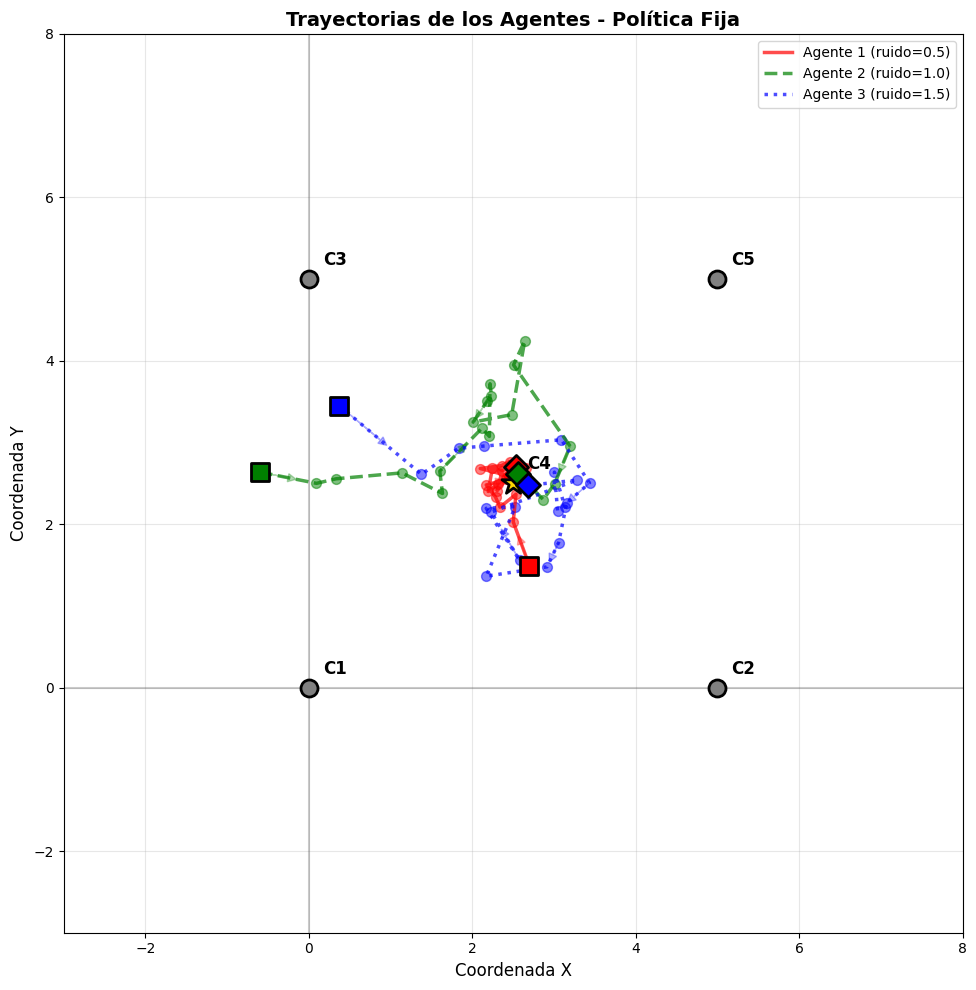

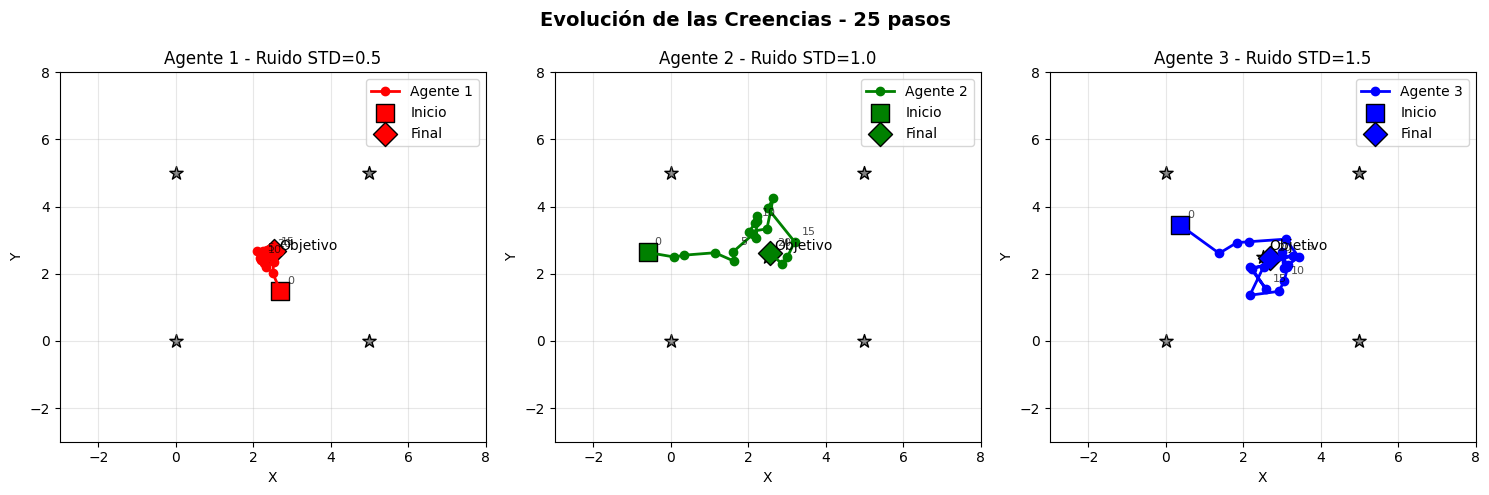


Recompensa total del episodio: 215.00
Decisiones finales: [3, 3, 3]
Centroide objetivo: 3 ([2.5 2.5])


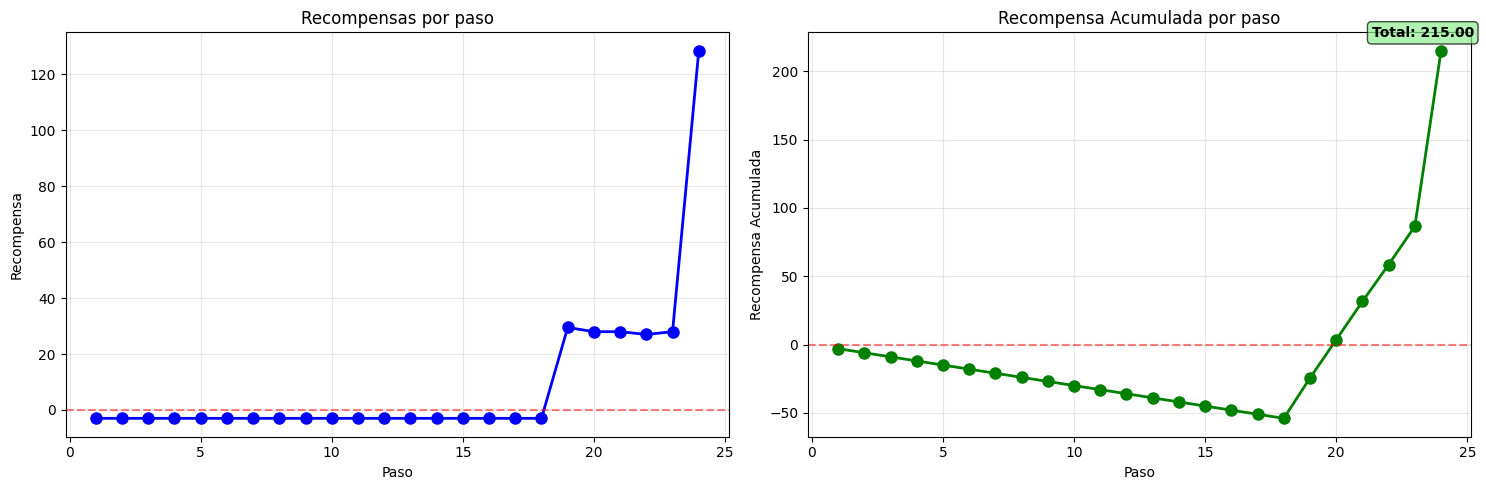

In [6]:
# Crear entorno
env = EntornoDecisionGlobal(N=3, max_pasos=25)

# Política fija para demostración
def politica_fija(paso):
    """
    Política heurística:
    - Pasos 0-3: Todos observan
    - Pasos 4-7: Todos consultan
    - Paso 8+: Todos deciden
    """
    if paso < 18:
        return ['observar', 'observar', 'observar']
    elif paso == 19:
        return ['consultar', 'observar', 'consultar']
    elif paso == 20:
        return ['consultar', 'consultar', 'observar']
    elif paso == 21:
        return ['observar', 'observar', 'observar']
    elif paso == 22:
        return ['consultar', 'observar', 'consultar']
    elif paso == 23:
        return ['decidir', 'consultar', 'observar']
    elif paso == 24:
        return ['consultar', 'consultar', 'consultar']
    elif paso < 26:
        return ['consultar', 'decidir', 'decidir']
    else:
        return ['decidir', 'decidir', 'decidir']

# Ejecutar simulación
estado = env.reset()
print("=== SIMULACIÓN CON POLÍTICA FIJA ===\n")
print(f"Estado inicial (creencias de los 3 agentes):")
for i, agente in enumerate(env.agentes):
    print(f"  Agente {i+1}: ({agente.creencia[0]:.2f}, {agente.creencia[1]:.2f})")

print("\n--- EVOLUCIÓN ---")
done = False
paso = 0

while not done:
    acciones = politica_fija(paso)
    nuevo_estado, recompensa, done, info = env.step(acciones)
    
    print(f"\nPaso {paso + 1}:")
    print(f"  Acciones: {acciones}")
    print(f"  Recompensa: {recompensa:.2f}")
    print(f"  Creencias actuales:")
    for i, creencia in enumerate(info['creencias']):
        print(f"    Agente {i+1}: ({creencia[0]:.2f}, {creencia[1]:.2f})")
    if any(d is not None for d in info['decisiones']):
        print(f"  Decisiones: {info['decisiones']}")
    paso += 1

print(f"\n=== EPISODIO COMPLETADO en {paso} pasos ===")

# Visualizar trayectorias (gráfico único)
env.visualizar_trayectorias("Trayectorias de los Agentes - Política Fija")

# Visualizar evolución detallada (subplots)
env.visualizar_evolucion()

In [7]:
env.historial_creencias

[[array([2.69930273, 1.49304869]),
  array([-0.60132686,  2.63712595]),
  array([0.37539257, 3.44718486])],
 [array([2.50159828, 2.02762424]),
  array([0.09409521, 2.49936971]),
  array([1.37885755, 2.60914046])],
 [array([2.53523778, 2.36540838]),
  array([0.33362168, 2.55494895]),
  array([1.83214754, 2.92821861])],
 [array([2.33912384, 2.20771738]),
  array([1.14011764, 2.62755967]),
  array([2.14522506, 2.95565472])],
 [array([2.28538298, 2.33024022]),
  array([1.63600409, 2.37498634]),
  array([3.09125607, 3.03218312])],
 [array([2.17107256, 2.47965119]),
  array([1.60279836, 2.64861582]),
  array([3.43524726, 2.50322114])],
 [array([2.41425721, 2.54767298]),
  array([2.1185769 , 3.17306897]),
  array([3.04424843, 2.16307353])],
 [array([2.30655288, 2.41099954]),
  array([2.20987332, 3.07349387]),
  array([3.00548476, 2.63638393])],
 [array([2.3665373 , 2.65572979]),
  array([2.21751427, 3.71749646]),
  array([3.13538964, 2.20974785])],
 [array([2.24594224, 2.68138171]),
  array([

=== ANIMACIÓN COMPLETADA ===
Recompensa total: 215.00


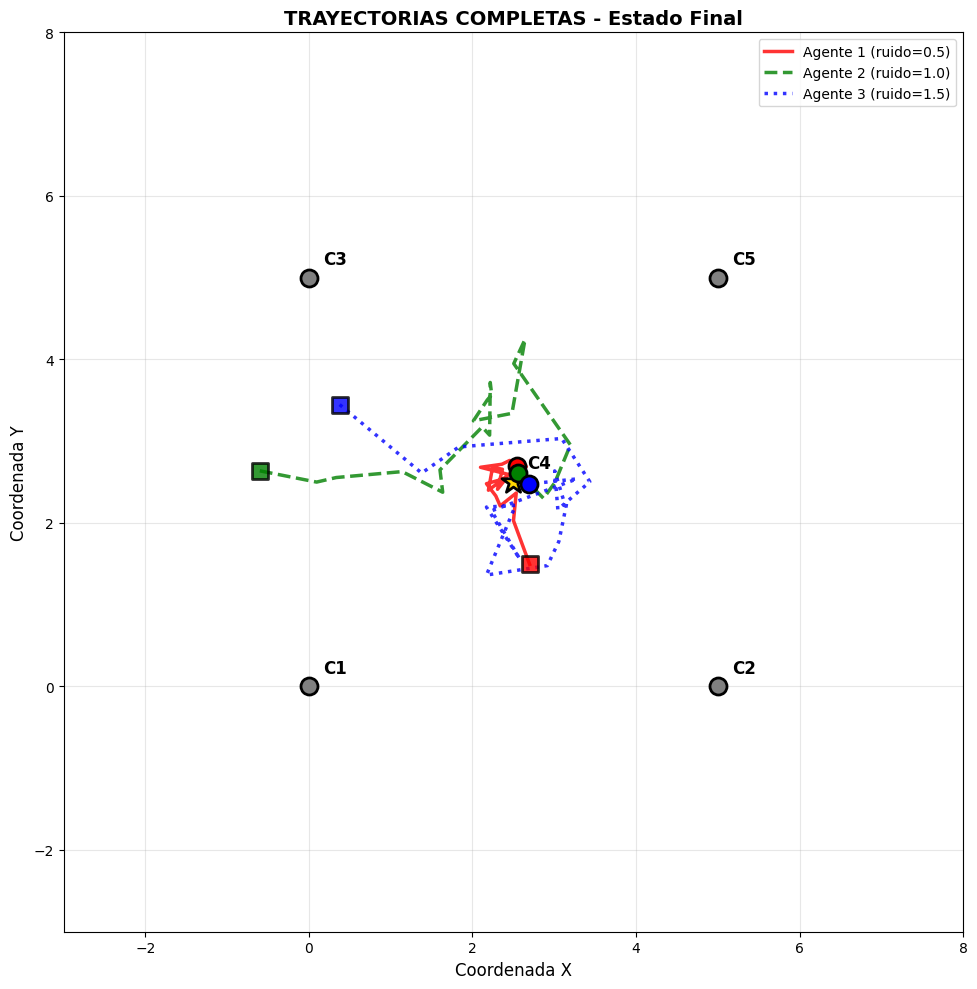

In [8]:
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np

def animacion_tiempo_real(env, centroides, centroide_objetivo, velocidad=0.5):
    """
    Muestra la evolución paso a paso en tiempo real con clear_output.
    
    Parámetros:
    - env: entorno con historial de creencias
    - centroides: diccionario con los centroides
    - centroide_objetivo: índice del centroide objetivo
    - velocidad: tiempo de pausa entre pasos (segundos)
    """
    n_pasos = len(env.historial_creencias)
    
    # Colores y estilos
    colores = ['red', 'green', 'blue']
    estilos = ['-', '--', ':']
    nombres = ['Agente 1 (ruido=0.5)', 'Agente 2 (ruido=1.0)', 'Agente 3 (ruido=1.5)']
    
    for paso in range(n_pasos):
        # Limpiar output anterior
        clear_output(wait=True)
        
        # Crear figura
        fig, ax = plt.subplots(figsize=(12, 10))
        
        # Dibujar centroides
        for idx, coord in centroides.items():
            color = 'gold' if idx == centroide_objetivo else 'gray'
            size = 300 if idx == centroide_objetivo else 150
            marker = '*' if idx == centroide_objetivo else 'o'
            ax.scatter(coord[0], coord[1], c=color, s=size, marker=marker,
                       edgecolors='black', linewidth=2, zorder=5)
            ax.annotate(f'C{idx+1}', coord, xytext=(10, 10), textcoords='offset points',
                        fontsize=12, fontweight='bold')
        
        # Dibujar trayectoria completa hasta el paso actual
        for i in range(3):
            x_data = [env.historial_creencias[t][i][0] for t in range(paso + 1)]
            y_data = [env.historial_creencias[t][i][1] for t in range(paso + 1)]
            
            # Línea de trayectoria
            ax.plot(x_data, y_data, color=colores[i], linestyle=estilos[i],
                   linewidth=2.5, alpha=0.7, label=nombres[i])
            
            # Punto actual
            ax.scatter(x_data[-1], y_data[-1], c=colores[i], s=150, marker='o',
                      edgecolors='black', linewidth=2, zorder=6)
        
        # Marcar inicio
        for i in range(3):
            x_inicio = env.historial_creencias[0][i][0]
            y_inicio = env.historial_creencias[0][i][1]
            ax.scatter(x_inicio, y_inicio, c=colores[i], s=100, marker='s',
                      edgecolors='black', linewidth=1.5, alpha=0.7, zorder=5)
        
        # Configurar gráfico
        ax.set_xlim(-3, 8)
        ax.set_ylim(-3, 8)
        ax.set_xlabel('Coordenada X', fontsize=12)
        ax.set_ylabel('Coordenada Y', fontsize=12)
        ax.set_title(f'Evolución Temporal - Paso {paso}/{n_pasos-1}', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        ax.legend(loc='upper right', fontsize=10)
        
        # Mostrar acciones del paso actual
        if hasattr(env, 'historial_acciones') and paso < len(env.historial_acciones):
            acciones = env.historial_acciones[paso]
            ax.text(0.02, 0.95, f'Acciones: {acciones}', transform=ax.transAxes,
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        
        # Mostrar información de recompensa
        recompensa_acum = sum(env.historial_recompensas[:paso+1]) if env.historial_recompensas else 0
        info_text = f"Paso: {paso}\nRecompensa acumulada: {recompensa_acum:.2f}"
        ax.text(0.02, 0.02, info_text, transform=ax.transAxes, fontsize=10,
               verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.show()
        
        # Pausa para controlar velocidad
        time.sleep(velocidad)
    
    # Mostrar gráfico final estático
    clear_output(wait=True)
    
    print("=== ANIMACIÓN COMPLETADA ===")
    print(f"Recompensa total: {sum(env.historial_recompensas):.2f}")
    
    # Gráfico final estático
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Dibujar centroides
    for idx, coord in centroides.items():
        color = 'gold' if idx == centroide_objetivo else 'gray'
        size = 300 if idx == centroide_objetivo else 150
        marker = '*' if idx == centroide_objetivo else 'o'
        ax.scatter(coord[0], coord[1], c=color, s=size, marker=marker,
                   edgecolors='black', linewidth=2, zorder=5)
        ax.annotate(f'C{idx+1}', coord, xytext=(10, 10), textcoords='offset points',
                    fontsize=12, fontweight='bold')
    
    # Dibujar trayectorias COMPLETAS
    for i in range(3):
        x_data = [env.historial_creencias[t][i][0] for t in range(n_pasos)]
        y_data = [env.historial_creencias[t][i][1] for t in range(n_pasos)]
        
        ax.plot(x_data, y_data, color=colores[i], linestyle=estilos[i],
               linewidth=2.5, alpha=0.8, label=nombres[i])
        
        # Punto inicial (cuadrado)
        ax.scatter(x_data[0], y_data[0], c=colores[i], s=120, marker='s',
                  edgecolors='black', linewidth=2, zorder=6, alpha=0.8)
        
        # Punto final (círculo)
        ax.scatter(x_data[-1], y_data[-1], c=colores[i], s=150, marker='o',
                  edgecolors='black', linewidth=2, zorder=6)
    
    ax.set_xlim(-3, 8)
    ax.set_ylim(-3, 8)
    ax.set_xlabel('Coordenada X', fontsize=12)
    ax.set_ylabel('Coordenada Y', fontsize=12)
    ax.set_title('TRAYECTORIAS COMPLETAS - Estado Final', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Ejecutar animación en tiempo real
print("=== ANIMACIÓN EN TIEMPO REAL ===\n")
animacion_tiempo_real(env, centroides, centroide_objetivo, velocidad=0.3)

Acciones totales para 3 agentes: 64
ENTRENAMIENTO Q-LEARNING - 3 AGENTES CON ESTADO SIMPLIFICADO

NUEVO ESPACIO DE ESTADOS:
   Estado simplificado: f(x1,y1,x2,y2,x3,y3) = sum_{i!=j} ||(xi,yi)-(xj,yj)||
   Discretizacion: 0, 0.5, 1, 1.5, ..., 10
   Total estados posibles: 21 (en lugar de 46,656)

PARAMETROS:
   Acciones posibles: 64
   Episodios: 5000
   Maximo pasos por episodio: 15
   alpha=0.1, gamma=0.95, epsilon_inicial=0.5
----------------------------------------------------------------------
Ep   500: R= -45.0, Exito=100.0%, Pasos=15.0, epsilon=0.500, tiempo=4s
Ep  1000: R= -45.0, Exito=100.0%, Pasos=15.0, epsilon=0.500, tiempo=8s
Ep  1500: R= -45.0, Exito=100.0%, Pasos=15.0, epsilon=0.500, tiempo=17s
Ep  2000: R= -45.0, Exito=100.0%, Pasos=15.0, epsilon=0.500, tiempo=31s
Ep  2500: R= -45.0, Exito=100.0%, Pasos=15.0, epsilon=0.390, tiempo=37s
Ep  3000: R= -45.0, Exito=100.0%, Pasos=15.0, epsilon=0.303, tiempo=41s
Ep  3500: R= -45.0, Exito=100.0%, Pasos=15.0, epsilon=0.236, tiempo

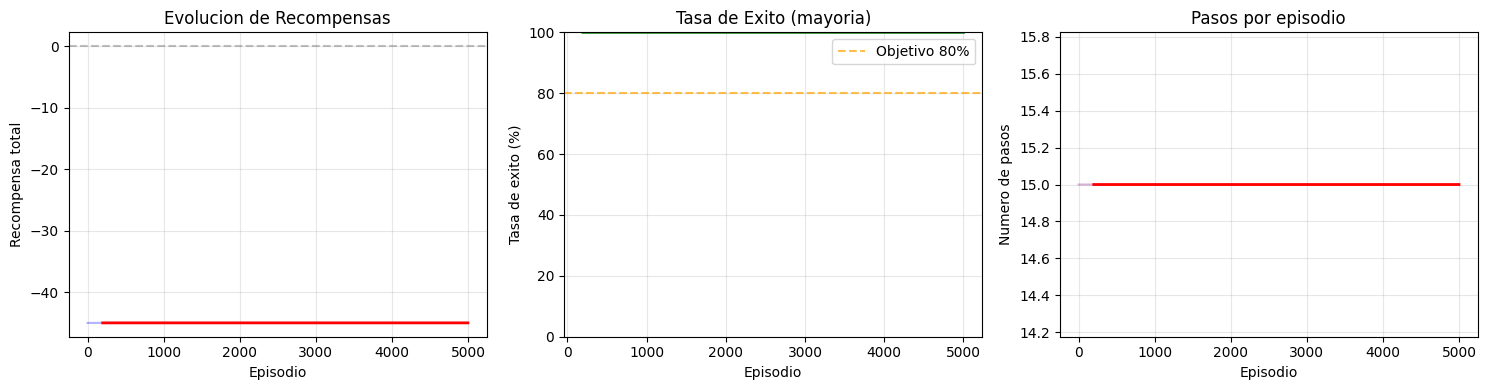


POLITICA OPTIMA APRENDIDA - MEJOR ACCION POR ESTADO

NOTA: El estado es la suma de distancias entre agentes discretizada
      Estado 0 = agentes muy juntos (distancia ~0)
      Estado 20 = agentes muy separados (distancia ~10)

--------------------------------------------------------------------------------
Estado   | Rango distancia      | Mejor accion (a1,a2,a3)             | Valor Q   
--------------------------------------------------------------------------------
0        | [0.0, 0.5)           | ('esperar', 'esperar', 'observar')  | 0.00      
1        | [0.5, 1.0)           | ('esperar', 'esperar', 'esperar')   | 0.00      
2        | [1.0, 1.5)           | ('esperar', 'esperar', 'esperar')   | 0.00      
3        | [1.5, 2.0)           | ('esperar', 'esperar', 'esperar')   | 0.00      
4        | [2.0, 2.5)           | ('esperar', 'esperar', 'esperar')   | 0.00      
5        | [2.5, 3.0)           | ('esperar', 'esperar', 'esperar')   | 0.00      
6        | [3.0, 3.5)      

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
import time

# ============================================================
# 1. CONFIGURACION DEL ESPACIO (3 AGENTES)
# ============================================================

N_BINS = 6
X_MIN, X_MAX = 0, 5
Y_MIN, Y_MAX = 0, 5

bins_x = np.linspace(X_MIN, X_MAX, N_BINS + 1)
bins_y = np.linspace(Y_MIN, Y_MAX, N_BINS + 1)

centroides = {
    0: np.array([0.5, 0.5]),
    1: np.array([4.5, 0.5]),
    2: np.array([0.5, 4.5]),
    3: np.array([2.5, 2.5]),  # OBJETIVO
    4: np.array([4.5, 4.5])
}

centroide_objetivo = 3
centroide_objetivo_coords = centroides[centroide_objetivo]
UMBRAL_DECISION = 0.5

# ============================================================
# NUEVA FUNCION DE ESTADO SIMPLIFICADO
# ============================================================

def estado_simplificado(env):
    """
    Calcula un estado simplificado basado en la suma de distancias entre agentes.
    
    f(x1,y1,x2,y2,x3,y3) = sum_{i!=j} ||(xi,yi) - (xj,yj)||
    
    Esto mide que tan dispersos o juntos estan los 3 agentes.
    
    Luego se discretiza en valores: 0, 0.5, 1, 1.5, ..., 10
    """
    # Obtener posiciones de los 3 agentes
    posiciones = []
    for agente in env.agentes:
        x = max(X_MIN, min(X_MAX, agente.creencia[0]))
        y = max(Y_MIN, min(Y_MAX, agente.creencia[1]))
        posiciones.append(np.array([x, y]))
    
    # Calcular suma de distancias entre todos los pares de agentes
    suma_distancias = 0
    for i in range(3):
        for j in range(i+1, 3):
            distancia = np.linalg.norm(posiciones[i] - posiciones[j])
            suma_distancias += distancia
    
    # Discretizar en pasos de 0.5 desde 0 hasta 10
    max_distancia = 10.0  # La maxima distancia posible en el espacio 5x5
    paso = 0.5
    
    # Encontrar el indice del bucket
    bucket = int(min(suma_distancias, max_distancia - 0.001) / paso)
    
    return bucket  # Retorna un entero entre 0 y 20

def discretizar_estado_completo(env):
    """
    Version original completa (se mantiene por compatibilidad)
    Discretiza el estado de 6 dimensiones: (x1, y1, x2, y2, x3, y3)
    """
    estado = []
    for agente in env.agentes:
        x = max(X_MIN, min(X_MAX, agente.creencia[0]))
        y = max(Y_MIN, min(Y_MAX, agente.creencia[1]))
        bin_x = np.digitize(x, bins_x) - 1
        bin_y = np.digitize(y, bins_y) - 1
        bin_x = max(0, min(N_BINS - 1, bin_x))
        bin_y = max(0, min(N_BINS - 1, bin_y))
        estado.append(bin_x)
        estado.append(bin_y)
    return tuple(estado)  # 6 elementos para 3 agentes

def ha_decidido(agente):
    """Determina si un agente ha decidido"""
    for centroide in centroides.values():
        if np.linalg.norm(agente.creencia - centroide) < UMBRAL_DECISION:
            return True
    return False

def obtener_decision(agente):
    """Retorna el indice del centroide elegido o None"""
    for idx, centroide in centroides.items():
        if np.linalg.norm(agente.creencia - centroide) < UMBRAL_DECISION:
            return idx
    return None


# ============================================================
# 2. CLASE AGENTE (MODELO DE CREENCIA)
# ============================================================

class Agente:
    """Agente con creencia bayesiana sobre el objetivo"""
    
    def __init__(self, id_agente, ruido_obs):
        self.id = id_agente
        self.ruido = ruido_obs
        self.reset()
    
    def reset(self):
        """Reinicia la creencia del agente"""
        # Creencia inicial: centro del espacio
        self.creencia = np.array([2.5, 2.5])
        self.ha_decidido = False
        self.decision = None
    
    def observar(self):
        """Simula una observacion ruidosa del objetivo"""
        observacion = centroide_objetivo_coords + np.random.normal(0, self.ruido, 2)
        observacion = np.clip(observacion, X_MIN, X_MAX)
        return observacion
    
    def actualizar_por_observacion(self, observacion):
        """Actualiza la creencia usando promedio ponderado"""
        self.creencia = 0.7 * self.creencia + 0.3 * observacion
        self.creencia = np.clip(self.creencia, X_MIN, X_MAX)
    
    def consultar(self, otras_creencias):
        """Consulta las creencias de otros agentes y las combina"""
        if otras_creencias:
            promedio_otras = np.mean(otras_creencias, axis=0)
            self.creencia = 0.5 * self.creencia + 0.5 * promedio_otras
    
    def decidir(self):
        """El agente decide un centroide basado en su creencia"""
        distancias = [np.linalg.norm(self.creencia - c) for c in centroides.values()]
        idx_min = np.argmin(distancias)
        self.decision = idx_min
        self.ha_decidido = True
        self.creencia = centroides[idx_min].copy()


# ============================================================
# 3. ENTORNO MODIFICADO PARA 3 AGENTES
# ============================================================

class Entorno3Agentes:
    """Entorno con 3 agentes y dinamica de colaboracion"""
    
    def __init__(self, max_pasos=25):
        self.N = 3
        self.max_pasos = max_pasos
        self.paso_actual = 0
        
        # Parametros de ruido para cada agente
        ruidos = [0.5, 1.0, 0.8]  # 3 agentes con diferente precision
        
        # Crear agentes
        self.agentes = [Agente(i, ruidos[i]) for i in range(3)]
        
        # Costos de acciones
        self.costos = {
            'esperar': -1,
            'observar': -1.0,
            'consultar': -0.5,
            'decidir': 0.0
        }
        
        # Historial
        self.historial_creencias = []
        self.historial_recompensas = []
        self.historial_acciones = []
    
    def obtener_estado(self):
        estado = []
        for agente in self.agentes:
            estado.extend(agente.creencia)
        return np.array(estado)
    
    def calcular_recompensa(self, acciones):
        """Funcion de recompensa para 3 agentes"""
        # Costo individual
        costo_total = sum(self.costos[acc] for acc in acciones)
        
        # Verificar acuerdos parciales (mayoria)
        decisiones_actuales = [a.decision for a in self.agentes if a.ha_decidido]
        
        delta_acuerdo = 0
        if len(decisiones_actuales) >= 2:  # Al menos 2 han decidido
            # Verificar si hay mayoria
            from collections import Counter
            conteo = Counter(decisiones_actuales)
            max_votos = max(conteo.values())
            if max_votos >= 2:  # Hay mayoria
                delta_acuerdo = 15
            else:
                delta_acuerdo = -30
        
        # Verificar final del episodio
        delta_final = 0
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)
        
        if todos_han_decidido:
            decisiones = [a.decision for a in self.agentes]
            if len(set(decisiones)) == 1 and decisiones[0] == centroide_objetivo:
                delta_final = 150  # Exito total: todos al objetivo
            elif len(set(decisiones)) == 1:
                delta_final = 30   # Todos de acuerdo pero objetivo equivocado
            elif len(set(decisiones)) == 2:
                # Mayoria al objetivo?
                if decisiones.count(centroide_objetivo) >= 2:
                    delta_final = 50  # Mayoria acerto
                else:
                    delta_final = -50
            else:
                delta_final = -100  # Desacuerdo total
        
        return costo_total + delta_acuerdo + delta_final
    
    def step(self, acciones):
        """Ejecuta un paso en el entorno"""
        self.paso_actual += 1
        
        # Ejecutar acciones
        for i, accion in enumerate(acciones):
            agente = self.agentes[i]
            
            if accion == 'observar' and not agente.ha_decidido:
                obs = agente.observar()
                agente.actualizar_por_observacion(obs)
            elif accion == 'consultar' and not agente.ha_decidido:
                otras_creencias = [a.creencia for j, a in enumerate(self.agentes) 
                                  if j != i and not a.ha_decidido]
                if otras_creencias:
                    agente.consultar(otras_creencias)
            elif accion == 'decidir' and not agente.ha_decidido:
                distancias = [np.linalg.norm(agente.creencia - c) for c in centroides.values()]
                if min(distancias) <= 2.0:
                    agente.decidir()
        
        # Calcular recompensa
        recompensa = self.calcular_recompensa(acciones)
        
        # Verificar si termino
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)
        done = todos_han_decidido or self.paso_actual >= self.max_pasos
        
        # Guardar historial
        self.historial_creencias.append([a.creencia.copy() for a in self.agentes])
        self.historial_recompensas.append(recompensa)
        self.historial_acciones.append(acciones)
        
        info = {
            'paso': self.paso_actual,
            'decisiones': [a.decision for a in self.agentes],
            'creencias': [a.creencia.copy() for a in self.agentes]
        }
        
        return self.obtener_estado(), recompensa, done, info
    
    def reset(self):
        """Reinicia el entorno"""
        self.paso_actual = 0
        for agente in self.agentes:
            agente.reset()
        self.historial_creencias = [[a.creencia.copy() for a in self.agentes]]
        self.historial_recompensas = []
        self.historial_acciones = []
        return self.obtener_estado()


# ============================================================
# 4. ACCIONES VALIDAS PARA 3 AGENTES
# ============================================================

# Todas las combinaciones posibles de acciones para 3 agentes
TODAS_ACCIONES = []
for a1 in ['esperar', 'observar', 'consultar', 'decidir']:
    for a2 in ['esperar', 'observar', 'consultar', 'decidir']:
        for a3 in ['esperar', 'observar', 'consultar', 'decidir']:
            TODAS_ACCIONES.append((a1, a2, a3))

print(f"Acciones totales para 3 agentes: {len(TODAS_ACCIONES)}")

def acciones_validas(env):
    """Filtra acciones: si ya decidio, solo puede esperar"""
    decididos = [ha_decidido(agente) for agente in env.agentes]
    validas = []
    for accion in TODAS_ACCIONES:
        valida = True
        for i in range(3):
            if decididos[i] and accion[i] != 'esperar':
                valida = False
                break
        if valida:
            validas.append(accion)
    return validas


# ============================================================
# 5. AGENTE Q-LEARNING CON ESTADO SIMPLIFICADO
# ============================================================

class AgenteQLearning:
    """
    Agente Q-Learning que usa el estado simplificado basado en distancias entre agentes.
    """
    
    def __init__(self, alpha=0.1, gamma=0.95, epsilon=0.5):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.Q = defaultdict(float)  # Ahora el estado es un entero (0-20)
        self.visitas = defaultdict(int)
    
    def seleccionar_accion(self, env):
        """
        Selecciona accion usando epsilon-greedy con el estado simplificado.
        """
        # Usamos el estado simplificado (un entero) en lugar del estado completo
        estado = estado_simplificado(env)
        acciones = acciones_validas(env)
        
        if not acciones:
            return ('esperar', 'esperar', 'esperar')
        
        if random.random() < self.epsilon:
            return random.choice(acciones)
        
        valores = [self.Q[(estado, a)] for a in acciones]
        max_valor = max(valores)
        mejores = [a for a, v in zip(acciones, valores) if v == max_valor]
        return random.choice(mejores)
    
    def actualizar(self, estado_anterior, accion, recompensa, env_siguiente, done):
        """
        Actualiza Q(s,a) usando la ecuacion de Bellman.
        """
        # Usamos el estado simplificado para el siguiente estado
        estado_siguiente = estado_simplificado(env_siguiente)
        acciones_sig = acciones_validas(env_siguiente)
        
        if done:
            objetivo = recompensa
        else:
            max_futuro = max([self.Q[(estado_siguiente, a)] for a in acciones_sig]) if acciones_sig else 0
            objetivo = recompensa + self.gamma * max_futuro
        
        clave = (estado_anterior, accion)
        self.Q[clave] = self.Q[clave] + self.alpha * (objetivo - self.Q[clave])
        self.visitas[clave] += 1
    
    def reducir_epsilon(self, factor=0.9995, minimo=0.05):
        self.epsilon = max(minimo, self.epsilon * factor)
    
    def imprimir_politica_optima(self):
        """
        IMPRIME LA MEJOR ACCION PARA CADA ESTADO
        Esta es la funcion que muestra los resultados finales
        """
        print("\n" + "=" * 80)
        print("POLITICA OPTIMA APRENDIDA - MEJOR ACCION POR ESTADO")
        print("=" * 80)
        print("\nNOTA: El estado es la suma de distancias entre agentes discretizada")
        print("      Estado 0 = agentes muy juntos (distancia ~0)")
        print("      Estado 20 = agentes muy separados (distancia ~10)")
        print("\n" + "-" * 80)
        print(f"{'Estado':<8} | {'Rango distancia':<20} | {'Mejor accion (a1,a2,a3)':<35} | {'Valor Q':<10}")
        print("-" * 80)
        
        # Para cada posible estado simplificado (0 a 20)
        for estado in range(21):
            # Calcular el rango de distancia que representa este estado
            distancia_min = estado * 0.5
            distancia_max = (estado + 1) * 0.5
            rango = f"[{distancia_min:.1f}, {distancia_max:.1f})"
            
            # Encontrar la mejor accion para este estado
            mejor_valor = -float('inf')
            mejor_accion = None
            
            # Buscar entre todas las acciones posibles
            for accion in TODAS_ACCIONES:
                valor = self.Q[(estado, accion)]
                if valor > mejor_valor:
                    mejor_valor = valor
                    mejor_accion = accion
            
            # Imprimir el resultado
            if mejor_accion is not None:
                print(f"{estado:<8} | {rango:<20} | {str(mejor_accion):<35} | {mejor_valor:<10.2f}")
        
        print("-" * 80)
        
        # Resumen de la politica
        print("\nRESUMEN DE LA POLITICA OPTIMA:")
        print("-" * 80)
        
        # Contar que acciones son mas frecuentes
        from collections import Counter
        conteo_acciones = Counter()
        for estado in range(21):
            mejor_valor = -float('inf')
            mejor_accion = None
            for accion in TODAS_ACCIONES:
                valor = self.Q[(estado, accion)]
                if valor > mejor_valor:
                    mejor_valor = valor
                    mejor_accion = accion
            if mejor_accion:
                conteo_acciones[mejor_accion] += 1
        
        print("\nFrecuencia de acciones en la politica optima:")
        for accion, count in conteo_acciones.most_common():
            print(f"  {accion}: {count} estados ({count/21*100:.1f}%)")
        
        print("=" * 80)


# ============================================================
# 6. ENTRENAMIENTO
# ============================================================

def entrenar(episodios=5000, max_pasos=15, verbose=True):
    """
    Entrenamiento con estado simplificado.
    CAMBIADO: episodios=5000 (antes era 50000)
    """
    agente = AgenteQLearning(alpha=0.1, gamma=0.95, epsilon=0.5)
    
    recompensas_por_episodio = []
    exitos_por_episodio = []
    pasos_por_episodio = []
    
    print("=" * 70)
    print("ENTRENAMIENTO Q-LEARNING - 3 AGENTES CON ESTADO SIMPLIFICADO")
    print("=" * 70)
    print()
    print("NUEVO ESPACIO DE ESTADOS:")
    print("   Estado simplificado: f(x1,y1,x2,y2,x3,y3) = sum_{i!=j} ||(xi,yi)-(xj,yj)||")
    print("   Discretizacion: 0, 0.5, 1, 1.5, ..., 10")
    print(f"   Total estados posibles: 21 (en lugar de {N_BINS**6:,})")
    print()
    print("PARAMETROS:")
    print(f"   Acciones posibles: {len(TODAS_ACCIONES)}")
    print(f"   Episodios: {episodios}")
    print(f"   Maximo pasos por episodio: {max_pasos}")
    print(f"   alpha={agente.alpha}, gamma={agente.gamma}, epsilon_inicial={agente.epsilon}")
    print("-" * 70)
    
    start_time = time.time()
    
    for episodio in range(episodios):
        env = Entorno3Agentes(max_pasos=max_pasos)
        # Usamos estado simplificado
        estado_actual = estado_simplificado(env)
        done = False
        recompensa_total = 0
        pasos = 0
        
        while not done:
            accion = agente.seleccionar_accion(env)
            _, recompensa, done, _ = env.step(accion)
            recompensa_total += recompensa
            
            estado_anterior = estado_actual
            estado_actual = estado_simplificado(env)
            agente.actualizar(estado_anterior, accion, recompensa, env, done)
            pasos += 1
        
        # Verificar exito (mayoria o unanimidad?)
        decisiones = [obtener_decision(a) for a in env.agentes]
        # Definimos exito como mayoria (al menos 2) acertaron al objetivo
        if None not in decisiones:
            exito = decisiones.count(centroide_objetivo) >= 2
        else:
            exito = False
        
        recompensas_por_episodio.append(recompensa_total)
        exitos_por_episodio.append(exito)
        pasos_por_episodio.append(pasos)
        
        # Reducir epsilon gradualmente
        if episodio > 2000:
            agente.reducir_epsilon(0.9995)
        
        # Mostrar progreso cada 500 episodios (mas frecuente por ser menos episodios)
        if verbose and (episodio + 1) % 500 == 0:
            avg_reward = np.mean(recompensas_por_episodio[-500:])
            avg_success = np.mean(exitos_por_episodio[-500:]) * 100
            avg_steps = np.mean(pasos_por_episodio[-500:])
            elapsed = time.time() - start_time
            print(f"Ep {episodio+1:5d}: R={avg_reward:6.1f}, Exito={avg_success:5.1f}%, "
                  f"Pasos={avg_steps:4.1f}, epsilon={agente.epsilon:.3f}, tiempo={elapsed:.0f}s")
    
    print("-" * 70)
    print(f"ENTRENAMIENTO COMPLETADO en {time.time() - start_time:.0f} segundos")
    print(f"Tasa de exito ultimos 500 episodios: {np.mean(exitos_por_episodio[-500:])*100:.1f}%")
    print("=" * 70)
    
    return agente, recompensas_por_episodio, exitos_por_episodio, pasos_por_episodio


# ============================================================
# 7. EVALUACION FINAL
# ============================================================

def evaluar(agente, n_pruebas=100):
    """Evalua la politica aprendida (sin exploracion)"""
    epsilon_original = agente.epsilon
    agente.epsilon = 0
    
    resultados = []
    
    print("\n" + "=" * 70)
    print("EVALUACION DE LA POLITICA APRENDIDA - 3 AGENTES")
    print("=" * 70)
    
    for i in range(n_pruebas):
        env = Entorno3Agentes(max_pasos=25)
        done = False
        recompensa_total = 0
        pasos = 0
        
        while not done:
            accion = agente.seleccionar_accion(env)
            _, recompensa, done, _ = env.step(accion)
            recompensa_total += recompensa
            pasos += 1
        
        decisiones = [obtener_decision(a) for a in env.agentes]
        if None not in decisiones:
            exito = decisiones.count(centroide_objetivo) >= 2
        else:
            exito = False
        
        resultados.append((recompensa_total, exito, pasos))
    
    exitos = [r[1] for r in resultados]
    recompensas = [r[0] for r in resultados]
    pasos_list = [r[2] for r in resultados]
    
    print(f"\nResultados sobre {n_pruebas} pruebas:")
    print(f"  Tasa de exito (mayoria al objetivo): {np.mean(exitos)*100:.1f}%")
    print(f"  Recompensa promedio: {np.mean(recompensas):.1f}")
    print(f"  Pasos promedio: {np.mean(pasos_list):.1f}")
    print(f"\nDistribucion:")
    print(f"  Exitos: {sum(exitos)}")
    print(f"  Fallos: {n_pruebas - sum(exitos)}")
    
    agente.epsilon = epsilon_original
    return resultados


# ============================================================
# 8. VISUALIZACION
# ============================================================

def graficar_resultados(recompensas, exitos, pasos):
    """Grafica las curvas de aprendizaje"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    window = 200  # Ventana mas pequeña para 5000 episodios
    
    # 1. Recompensas
    axes[0].plot(recompensas, alpha=0.3, color='blue')
    if len(recompensas) >= window:
        ma = np.convolve(recompensas, np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(recompensas)), ma, 'r-', linewidth=2)
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Episodio')
    axes[0].set_ylabel('Recompensa total')
    axes[0].set_title('Evolucion de Recompensas')
    axes[0].grid(True, alpha=0.3)
    
    # 2. Tasa de exito
    success_rates = []
    for i in range(len(exitos) - window + 1):
        success_rates.append(np.mean(exitos[i:i+window]) * 100)
    axes[1].plot(range(window-1, len(exitos)), success_rates, 'g-', linewidth=2)
    axes[1].axhline(y=80, color='orange', linestyle='--', alpha=0.7, label='Objetivo 80%')
    axes[1].set_xlabel('Episodio')
    axes[1].set_ylabel('Tasa de exito (%)')
    axes[1].set_title('Tasa de Exito (mayoria)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 100)
    
    # 3. Pasos por episodio
    axes[2].plot(pasos, alpha=0.3, color='purple')
    if len(pasos) >= window:
        ma_pasos = np.convolve(pasos, np.ones(window)/window, mode='valid')
        axes[2].plot(range(window-1, len(pasos)), ma_pasos, 'r-', linewidth=2)
    axes[2].set_xlabel('Episodio')
    axes[2].set_ylabel('Numero de pasos')
    axes[2].set_title('Pasos por episodio')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# ============================================================
# 9. EJECUCION PRINCIPAL
# ============================================================

if __name__ == "__main__":
    # Entrenar con 5000 episodios (cambiado de 50000 a 5000)
    agente, rewards, successes, steps = entrenar(episodios=5000, max_pasos=15)
    
    # Graficar
    graficar_resultados(rewards, successes, steps)
    
    # IMPRIMIR LA MEJOR ACCION PARA CADA ESTADO
    agente.imprimir_politica_optima()
    
    # Evaluar
    resultados = evaluar(agente, n_pruebas=100)

Acciones totales para 3 agentes: 64
ENTRENAMIENTO Q-LEARNING - 3 AGENTES CON ESTADO SIMPLIFICADO

NUEVO ESPACIO DE ESTADOS:
   Estado simplificado: f(x1,y1,x2,y2,x3,y3) = sum_{i<j} ||(xi,yi)-(xj,yj)||
   Discretizacion: 0, 0.5, 1, 1.5, ..., 10
   Total estados posibles: 21 (en lugar de 46,656)

PARAMETROS:
   Acciones posibles: 64
   Episodios: 5000
   Maximo pasos por episodio: 15
   alpha=0.1, gamma=0.95, epsilon_inicial=0.5
----------------------------------------------------------------------
Ep   500: R= -17.3, Exito= 49.2%, Pasos= 6.4, epsilon=0.500, tiempo=2s
Ep  1000: R=  23.3, Exito= 58.8%, Pasos= 6.1, epsilon=0.500, tiempo=4s
Ep  1500: R=  10.6, Exito= 50.8%, Pasos= 7.0, epsilon=0.500, tiempo=6s
Ep  2000: R=  16.9, Exito= 51.0%, Pasos= 7.7, epsilon=0.500, tiempo=7s
Ep  2500: R=  26.1, Exito= 51.8%, Pasos= 7.6, epsilon=0.390, tiempo=9s
Ep  3000: R=  34.4, Exito= 52.8%, Pasos= 8.6, epsilon=0.303, tiempo=12s
Ep  3500: R=  46.7, Exito= 46.0%, Pasos= 8.6, epsilon=0.236, tiempo=15s

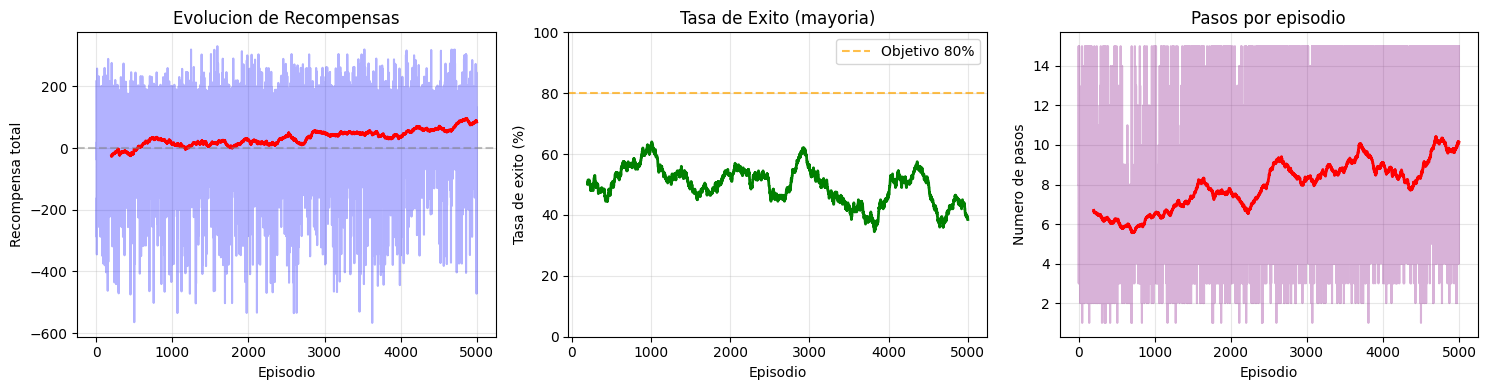


POLITICA OPTIMA APRENDIDA - MEJOR ACCION POR ESTADO

NOTA: El estado es la suma de distancias entre agentes discretizada
      Estado 0 = agentes muy juntos (distancia ~0)
      Estado 20 = agentes muy separados (distancia ~10)

------------------------------------------------------------------------------------------
Estado   | Rango distancia      | Mejor accion (a1,a2,a3)                  | Valor Q    | Visitas 
------------------------------------------------------------------------------------------
0        | [0.0, 0.5)           | ('decidir', 'esperar', 'observar')       | 81.34      | 36      
1        | [0.5, 1.0)           | ('esperar', 'decidir', 'esperar')        | 104.89     | 215     
2        | [1.0, 1.5)           | ('esperar', 'esperar', 'esperar')        | 100.32     | 1686    
3        | [1.5, 2.0)           | ('esperar', 'esperar', 'decidir')        | 78.93      | 614     
4        | [2.0, 2.5)           | ('esperar', 'consultar', 'consultar')    | 88.55      | 136

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
import time

# ============================================================
# 1. CONFIGURACION DEL ESPACIO (3 AGENTES)
# ============================================================

N_BINS = 6
X_MIN, X_MAX = 0, 5
Y_MIN, Y_MAX = 0, 5

bins_x = np.linspace(X_MIN, X_MAX, N_BINS + 1)
bins_y = np.linspace(Y_MIN, Y_MAX, N_BINS + 1)

centroides = {
    0: np.array([0.5, 0.5]),
    1: np.array([4.5, 0.5]),
    2: np.array([0.5, 4.5]),
    3: np.array([2.5, 2.5]),  # OBJETIVO
    4: np.array([4.5, 4.5])
}

centroide_objetivo = 3
centroide_objetivo_coords = centroides[centroide_objetivo]
UMBRAL_DECISION = 0.5

# ============================================================
# 2. CLASE AGENTE MEJORADA
# ============================================================

class Agente:
    """Agente con creencia sobre el centroide objetivo"""
    
    def __init__(self, id_agente, ruido_std, creencia_inicial=None):
        self.id = id_agente
        self.ruido_std = ruido_std  # Desviación estándar del ruido en observaciones
        
        if creencia_inicial is None:
            # Creencia inicial aleatoria alrededor del centroide objetivo
            self.creencia = centroide_objetivo_coords + np.random.randn(2) * 3.0
        else:
            self.creencia = creencia_inicial.copy()
        
        # Asegurar que la creencia está dentro de los límites
        self.creencia = np.clip(self.creencia, X_MIN, X_MAX)
        
        self.decision = None  # Almacena la decisión final (índice del centroide)
        self.ha_decidido = False
    
    def observar(self):
        """
        Simula una observación del centroide objetivo con ruido.
        Retorna: observación (x, y) con ruido Gaussiano
        """
        ruido = np.random.randn(2) * self.ruido_std
        observacion = centroide_objetivo_coords + ruido
        observacion = np.clip(observacion, X_MIN, X_MAX)
        return observacion
    
    def actualizar_por_observacion(self, observacion, beta=2.0, alpha=0.3):
        """
        Actualización aditiva: combinar creencia con observación.
        Es más intuitiva y preserva la escala.
        """
        # Mover hacia la observación con factor alpha
        self.creencia = (1 - alpha) * self.creencia + alpha * observacion
        self.creencia = np.clip(self.creencia, X_MIN, X_MAX)
        return self.creencia
    
    def consultar(self, otras_creencias):
        """
        Actualiza la creencia consultando a otros agentes.
        Combina las creencias usando un promedio ponderado.
        """
        todas_creencias = [self.creencia] + otras_creencias
        self.creencia = np.mean(todas_creencias, axis=0)
        self.creencia = np.clip(self.creencia, X_MIN, X_MAX)
        return self.creencia
    
    def decidir(self):
        """
        Decide cuál centroide cree que es el correcto
        basado en la distancia mínima a su creencia actual.
        """
        distancias = {idx: np.linalg.norm(self.creencia - centroide) 
                     for idx, centroide in centroides.items()}
        self.decision = min(distancias, key=distancias.get)
        self.ha_decidido = True
        return self.decision
    
    def reset(self):
        """Reinicia el agente para un nuevo episodio"""
        self.creencia = centroide_objetivo_coords + np.random.randn(2) * 2.0
        self.creencia = np.clip(self.creencia, X_MIN, X_MAX)
        self.decision = None
        self.ha_decidido = False

# ============================================================
# 3. FUNCION DE ESTADO SIMPLIFICADO
# ============================================================

def estado_simplificado(env):
    """
    Calcula un estado simplificado basado en la suma de distancias entre agentes.
    
    f(x1,y1,x2,y2,x3,y3) = sum_{i<j} ||(xi,yi) - (xj,yj)||
    
    Esto mide que tan dispersos o juntos estan los 3 agentes.
    Luego se discretiza en valores: 0, 0.5, 1, 1.5, ..., 10
    """
    # Obtener posiciones de los 3 agentes
    posiciones = []
    for agente in env.agentes:
        x = max(X_MIN, min(X_MAX, agente.creencia[0]))
        y = max(Y_MIN, min(Y_MAX, agente.creencia[1]))
        posiciones.append(np.array([x, y]))
    
    # Calcular suma de distancias entre todos los pares de agentes
    suma_distancias = 0
    for i in range(3):
        for j in range(i+1, 3):
            distancia = np.linalg.norm(posiciones[i] - posiciones[j])
            suma_distancias += distancia
    
    # Discretizar en pasos de 0.5 desde 0 hasta 10
    max_distancia = 10.0
    paso = 0.5
    
    # Encontrar el indice del bucket
    bucket = int(min(suma_distancias, max_distancia - 0.001) / paso)
    
    return bucket  # Retorna un entero entre 0 y 20

def ha_decidido(agente):
    """Determina si un agente ha decidido"""
    return agente.ha_decidido

def obtener_decision(agente):
    """Retorna el indice del centroide elegido o None"""
    return agente.decision if agente.ha_decidido else None


# ============================================================
# 4. ENTORNO PARA 3 AGENTES
# ============================================================

class Entorno3Agentes:
    """Entorno con 3 agentes y dinamica de colaboracion"""
    
    def __init__(self, max_pasos=25):
        self.N = 3
        self.max_pasos = max_pasos
        self.paso_actual = 0
        
        # Parametros de ruido para cada agente
        ruidos = [0.5, 1.0, 0.8]  # 3 agentes con diferente precision
        
        # Crear agentes con la nueva clase
        self.agentes = [Agente(i, ruidos[i]) for i in range(3)]
        
        # Costos de acciones
        self.costos = {
            'esperar': -0.2,
            'observar': -1.0,
            'consultar': -0.5,
            'decidir': 0.0
        }
        
        # Historial
        self.historial_creencias = []
        self.historial_recompensas = []
        self.historial_acciones = []
    
    def obtener_estado(self):
        estado = []
        for agente in self.agentes:
            estado.extend(agente.creencia)
        return np.array(estado)
    
    def calcular_recompensa(self, acciones):
        """Funcion de recompensa para 3 agentes"""
        # Costo individual
        costo_total = sum(self.costos[acc] for acc in acciones)
        
        # Verificar acuerdos parciales (mayoria)
        decisiones_actuales = [a.decision for a in self.agentes if a.ha_decidido]
        
        delta_acuerdo = 0
        if len(decisiones_actuales) >= 2:  # Al menos 2 han decidido
            # Verificar si hay mayoria
            from collections import Counter
            conteo = Counter(decisiones_actuales)
            max_votos = max(conteo.values())
            if max_votos >= 2:  # Hay mayoria
                delta_acuerdo = 15
            else:
                delta_acuerdo = -30
        
        # Verificar final del episodio
        delta_final = 0
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)
        
        if todos_han_decidido:
            decisiones = [a.decision for a in self.agentes]
            if len(set(decisiones)) == 1 and decisiones[0] == centroide_objetivo:
                delta_final = 150  # Exito total: todos al objetivo
            elif len(set(decisiones)) == 1:
                delta_final = 30   # Todos de acuerdo pero objetivo equivocado
            elif len(set(decisiones)) == 2:
                # Mayoria al objetivo?
                if decisiones.count(centroide_objetivo) >= 2:
                    delta_final = 50  # Mayoria acerto
                else:
                    delta_final = -50
            else:
                delta_final = -100  # Desacuerdo total
        
        return costo_total + delta_acuerdo + delta_final
    
    def step(self, acciones):
        """Ejecuta un paso en el entorno"""
        self.paso_actual += 1
        
        # Ejecutar acciones
        for i, accion in enumerate(acciones):
            agente = self.agentes[i]
            
            if accion == 'observar' and not agente.ha_decidido:
                obs = agente.observar()
                agente.actualizar_por_observacion(obs)
            elif accion == 'consultar' and not agente.ha_decidido:
                otras_creencias = [a.creencia for j, a in enumerate(self.agentes) 
                                  if j != i and not a.ha_decidido]
                if otras_creencias:
                    agente.consultar(otras_creencias)
            elif accion == 'decidir' and not agente.ha_decidido:
                agente.decidir()
        
        # Calcular recompensa
        recompensa = self.calcular_recompensa(acciones)
        
        # Verificar si termino
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)
        done = todos_han_decidido or self.paso_actual >= self.max_pasos
        
        # Guardar historial
        self.historial_creencias.append([a.creencia.copy() for a in self.agentes])
        self.historial_recompensas.append(recompensa)
        self.historial_acciones.append(acciones)
        
        info = {
            'paso': self.paso_actual,
            'decisiones': [a.decision for a in self.agentes],
            'creencias': [a.creencia.copy() for a in self.agentes]
        }
        
        return self.obtener_estado(), recompensa, done, info
    
    def reset(self):
        """Reinicia el entorno"""
        self.paso_actual = 0
        for agente in self.agentes:
            agente.reset()
        self.historial_creencias = [[a.creencia.copy() for a in self.agentes]]
        self.historial_recompensas = []
        self.historial_acciones = []
        return self.obtener_estado()


# ============================================================
# 5. ACCIONES VALIDAS PARA 3 AGENTES
# ============================================================

# Todas las combinaciones posibles de acciones para 3 agentes
TODAS_ACCIONES = []
for a1 in ['esperar', 'observar', 'consultar', 'decidir']:
    for a2 in ['esperar', 'observar', 'consultar', 'decidir']:
        for a3 in ['esperar', 'observar', 'consultar', 'decidir']:
            TODAS_ACCIONES.append((a1, a2, a3))

print(f"Acciones totales para 3 agentes: {len(TODAS_ACCIONES)}")

def acciones_validas(env):
    """Filtra acciones: si ya decidio, solo puede esperar"""
    decididos = [ha_decidido(agente) for agente in env.agentes]
    validas = []
    for accion in TODAS_ACCIONES:
        valida = True
        for i in range(3):
            if decididos[i] and accion[i] != 'esperar':
                valida = False
                break
        if valida:
            validas.append(accion)
    return validas


# ============================================================
# 6. AGENTE Q-LEARNING CON ESTADO SIMPLIFICADO
# ============================================================

class AgenteQLearning:
    """
    Agente Q-Learning que usa el estado simplificado basado en distancias entre agentes.
    """
    
    def __init__(self, alpha=0.1, gamma=0.95, epsilon=0.5):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.Q = defaultdict(float)  # Ahora el estado es un entero (0-20)
        self.visitas = defaultdict(int)
    
    def seleccionar_accion(self, env):
        """
        Selecciona accion usando epsilon-greedy con el estado simplificado.
        """
        # Usamos el estado simplificado (un entero) en lugar del estado completo
        estado = estado_simplificado(env)
        acciones = acciones_validas(env)
        
        if not acciones:
            return ('esperar', 'esperar', 'esperar')
        
        if random.random() < self.epsilon:
            return random.choice(acciones)
        
        valores = [self.Q[(estado, a)] for a in acciones]
        max_valor = max(valores)
        mejores = [a for a, v in zip(acciones, valores) if v == max_valor]
        return random.choice(mejores)
    
    def actualizar(self, estado_anterior, accion, recompensa, env_siguiente, done):
        """
        Actualiza Q(s,a) usando la ecuacion de Bellman.
        """
        # Usamos el estado simplificado para el siguiente estado
        estado_siguiente = estado_simplificado(env_siguiente)
        acciones_sig = acciones_validas(env_siguiente)
        
        if done:
            objetivo = recompensa
        else:
            max_futuro = max([self.Q[(estado_siguiente, a)] for a in acciones_sig]) if acciones_sig else 0
            objetivo = recompensa + self.gamma * max_futuro
        
        clave = (estado_anterior, accion)
        self.Q[clave] = self.Q[clave] + self.alpha * (objetivo - self.Q[clave])
        self.visitas[clave] += 1
    
    def reducir_epsilon(self, factor=0.9995, minimo=0.05):
        self.epsilon = max(minimo, self.epsilon * factor)
    
    def imprimir_politica_optima(self):
        """
        IMPRIME LA MEJOR ACCION PARA CADA ESTADO
        Esta es la funcion que muestra los resultados finales
        """
        print("\n" + "=" * 90)
        print("POLITICA OPTIMA APRENDIDA - MEJOR ACCION POR ESTADO")
        print("=" * 90)
        print("\nNOTA: El estado es la suma de distancias entre agentes discretizada")
        print("      Estado 0 = agentes muy juntos (distancia ~0)")
        print("      Estado 20 = agentes muy separados (distancia ~10)")
        print("\n" + "-" * 90)
        print(f"{'Estado':<8} | {'Rango distancia':<20} | {'Mejor accion (a1,a2,a3)':<40} | {'Valor Q':<10} | {'Visitas':<8}")
        print("-" * 90)
        
        # Para cada posible estado simplificado (0 a 20)
        for estado in range(21):
            # Calcular el rango de distancia que representa este estado
            distancia_min = estado * 0.5
            distancia_max = (estado + 1) * 0.5
            rango = f"[{distancia_min:.1f}, {distancia_max:.1f})"
            
            # Encontrar la mejor accion para este estado
            mejor_valor = -float('inf')
            mejor_accion = None
            visitas_mejor = 0
            
            # Buscar entre todas las acciones posibles
            for accion in TODAS_ACCIONES:
                valor = self.Q[(estado, accion)]
                if valor > mejor_valor:
                    mejor_valor = valor
                    mejor_accion = accion
                    visitas_mejor = self.visitas[(estado, accion)]
            
            # Imprimir el resultado
            if mejor_accion is not None:
                print(f"{estado:<8} | {rango:<20} | {str(mejor_accion):<40} | {mejor_valor:<10.2f} | {visitas_mejor:<8}")
        
        print("-" * 90)
        
        # Resumen de la politica
        print("\nRESUMEN DE LA POLITICA OPTIMA:")
        print("-" * 90)
        
        # Contar que acciones son mas frecuentes
        from collections import Counter
        conteo_acciones = Counter()
        for estado in range(21):
            mejor_valor = -float('inf')
            mejor_accion = None
            for accion in TODAS_ACCIONES:
                valor = self.Q[(estado, accion)]
                if valor > mejor_valor:
                    mejor_valor = valor
                    mejor_accion = accion
            if mejor_accion:
                conteo_acciones[mejor_accion] += 1
        
        print("\nFrecuencia de acciones en la politica optima:")
        for accion, count in conteo_acciones.most_common():
            print(f"  {accion}: {count} estados ({count/21*100:.1f}%)")
        
        print("=" * 90)


# ============================================================
# 7. ENTRENAMIENTO
# ============================================================

def entrenar(episodios=5000, max_pasos=15, verbose=True):
    """
    Entrenamiento con estado simplificado.
    """
    agente = AgenteQLearning(alpha=0.1, gamma=0.95, epsilon=0.5)
    
    recompensas_por_episodio = []
    exitos_por_episodio = []
    pasos_por_episodio = []
    
    print("=" * 70)
    print("ENTRENAMIENTO Q-LEARNING - 3 AGENTES CON ESTADO SIMPLIFICADO")
    print("=" * 70)
    print()
    print("NUEVO ESPACIO DE ESTADOS:")
    print("   Estado simplificado: f(x1,y1,x2,y2,x3,y3) = sum_{i<j} ||(xi,yi)-(xj,yj)||")
    print("   Discretizacion: 0, 0.5, 1, 1.5, ..., 10")
    print(f"   Total estados posibles: 21 (en lugar de {N_BINS**6:,})")
    print()
    print("PARAMETROS:")
    print(f"   Acciones posibles: {len(TODAS_ACCIONES)}")
    print(f"   Episodios: {episodios}")
    print(f"   Maximo pasos por episodio: {max_pasos}")
    print(f"   alpha={agente.alpha}, gamma={agente.gamma}, epsilon_inicial={agente.epsilon}")
    print("-" * 70)
    
    start_time = time.time()
    
    for episodio in range(episodios):
        env = Entorno3Agentes(max_pasos=max_pasos)
        # Usamos estado simplificado
        estado_actual = estado_simplificado(env)
        done = False
        recompensa_total = 0
        pasos = 0
        
        while not done:
            accion = agente.seleccionar_accion(env)
            _, recompensa, done, _ = env.step(accion)
            recompensa_total += recompensa
            
            estado_anterior = estado_actual
            estado_actual = estado_simplificado(env)
            agente.actualizar(estado_anterior, accion, recompensa, env, done)
            pasos += 1
        
        # Verificar exito (mayoria al objetivo)
        decisiones = [obtener_decision(a) for a in env.agentes]
        if None not in decisiones:
            exito = decisiones.count(centroide_objetivo) >= 2
        else:
            exito = False
        
        recompensas_por_episodio.append(recompensa_total)
        exitos_por_episodio.append(exito)
        pasos_por_episodio.append(pasos)
        
        # Reducir epsilon gradualmente
        if episodio > 2000:
            agente.reducir_epsilon(0.9995)
        
        # Mostrar progreso cada 500 episodios
        if verbose and (episodio + 1) % 500 == 0:
            avg_reward = np.mean(recompensas_por_episodio[-500:])
            avg_success = np.mean(exitos_por_episodio[-500:]) * 100
            avg_steps = np.mean(pasos_por_episodio[-500:])
            elapsed = time.time() - start_time
            print(f"Ep {episodio+1:5d}: R={avg_reward:6.1f}, Exito={avg_success:5.1f}%, "
                  f"Pasos={avg_steps:4.1f}, epsilon={agente.epsilon:.3f}, tiempo={elapsed:.0f}s")
    
    print("-" * 70)
    print(f"ENTRENAMIENTO COMPLETADO en {time.time() - start_time:.0f} segundos")
    print(f"Tasa de exito ultimos 500 episodios: {np.mean(exitos_por_episodio[-500:])*100:.1f}%")
    print("=" * 70)
    
    return agente, recompensas_por_episodio, exitos_por_episodio, pasos_por_episodio


# ============================================================
# 8. EVALUACION FINAL
# ============================================================

def evaluar(agente, n_pruebas=100):
    """Evalua la politica aprendida (sin exploracion)"""
    epsilon_original = agente.epsilon
    agente.epsilon = 0
    
    resultados = []
    
    print("\n" + "=" * 70)
    print("EVALUACION DE LA POLITICA APRENDIDA - 3 AGENTES")
    print("=" * 70)
    
    for i in range(n_pruebas):
        env = Entorno3Agentes(max_pasos=25)
        done = False
        recompensa_total = 0
        pasos = 0
        
        while not done:
            accion = agente.seleccionar_accion(env)
            _, recompensa, done, _ = env.step(accion)
            recompensa_total += recompensa
            pasos += 1
        
        decisiones = [obtener_decision(a) for a in env.agentes]
        if None not in decisiones:
            exito = decisiones.count(centroide_objetivo) >= 2
        else:
            exito = False
        
        resultados.append((recompensa_total, exito, pasos))
    
    exitos = [r[1] for r in resultados]
    recompensas = [r[0] for r in resultados]
    pasos_list = [r[2] for r in resultados]
    
    print(f"\nResultados sobre {n_pruebas} pruebas:")
    print(f"  Tasa de exito (mayoria al objetivo): {np.mean(exitos)*100:.1f}%")
    print(f"  Recompensa promedio: {np.mean(recompensas):.1f}")
    print(f"  Pasos promedio: {np.mean(pasos_list):.1f}")
    print(f"\nDistribucion:")
    print(f"  Exitos: {sum(exitos)}")
    print(f"  Fallos: {n_pruebas - sum(exitos)}")
    
    agente.epsilon = epsilon_original
    return resultados


# ============================================================
# 9. VISUALIZACION
# ============================================================

def graficar_resultados(recompensas, exitos, pasos):
    """Grafica las curvas de aprendizaje"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    window = 200  # Ventana mas pequena para 5000 episodios
    
    # 1. Recompensas
    axes[0].plot(recompensas, alpha=0.3, color='blue')
    if len(recompensas) >= window:
        ma = np.convolve(recompensas, np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(recompensas)), ma, 'r-', linewidth=2)
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Episodio')
    axes[0].set_ylabel('Recompensa total')
    axes[0].set_title('Evolucion de Recompensas')
    axes[0].grid(True, alpha=0.3)
    
    # 2. Tasa de exito
    success_rates = []
    for i in range(len(exitos) - window + 1):
        success_rates.append(np.mean(exitos[i:i+window]) * 100)
    axes[1].plot(range(window-1, len(exitos)), success_rates, 'g-', linewidth=2)
    axes[1].axhline(y=80, color='orange', linestyle='--', alpha=0.7, label='Objetivo 80%')
    axes[1].set_xlabel('Episodio')
    axes[1].set_ylabel('Tasa de exito (%)')
    axes[1].set_title('Tasa de Exito (mayoria)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 100)
    
    # 3. Pasos por episodio
    axes[2].plot(pasos, alpha=0.3, color='purple')
    if len(pasos) >= window:
        ma_pasos = np.convolve(pasos, np.ones(window)/window, mode='valid')
        axes[2].plot(range(window-1, len(pasos)), ma_pasos, 'r-', linewidth=2)
    axes[2].set_xlabel('Episodio')
    axes[2].set_ylabel('Numero de pasos')
    axes[2].set_title('Pasos por episodio')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# ============================================================
# 10. EJECUCION PRINCIPAL
# ============================================================

if __name__ == "__main__":
    # Entrenar con 5000 episodios
    agente, rewards, successes, steps = entrenar(episodios=5000, max_pasos=15)
    
    # Graficar
    graficar_resultados(rewards, successes, steps)
    
    # IMPRIMIR LA MEJOR ACCION PARA CADA ESTADO
    agente.imprimir_politica_optima()
    
    # Evaluar
    resultados = evaluar(agente, n_pruebas=100)

Acciones totales para 3 agentes: 64
ENTRENAMIENTO Q-LEARNING - 3 AGENTES CON ESTADO SIMPLIFICADO

NUEVO ESPACIO DE ESTADOS:
   Estado simplificado: f(x1,y1,x2,y2,x3,y3) = sum_{i<j} ||(xi,yi)-(xj,yj)||
PARAMETROS:
   Acciones posibles: 64
   Episodios: 15000
   Maximo pasos por episodio: 15
   alpha=0.1, gamma=0.95, epsilon_inicial=0.5
----------------------------------------------------------------------
Ep   500: R= -22.5, Exito= 48.6%, Pasos= 6.3, epsilon=0.500, tiempo=5s
Ep  1000: R=  13.8, Exito= 55.0%, Pasos= 5.8, epsilon=0.500, tiempo=6s
Ep  1500: R=  14.1, Exito= 55.0%, Pasos= 6.1, epsilon=0.500, tiempo=7s
Ep  2000: R=  20.9, Exito= 59.4%, Pasos= 6.3, epsilon=0.500, tiempo=10s
Ep  2500: R=  28.5, Exito= 55.6%, Pasos= 7.3, epsilon=0.390, tiempo=13s
Ep  3000: R=  45.1, Exito= 60.6%, Pasos= 7.5, epsilon=0.303, tiempo=16s
Ep  3500: R=  41.8, Exito= 51.4%, Pasos= 8.5, epsilon=0.236, tiempo=18s
Ep  4000: R=  65.7, Exito= 53.6%, Pasos= 8.9, epsilon=0.184, tiempo=20s
Ep  4500: R=  52.6,

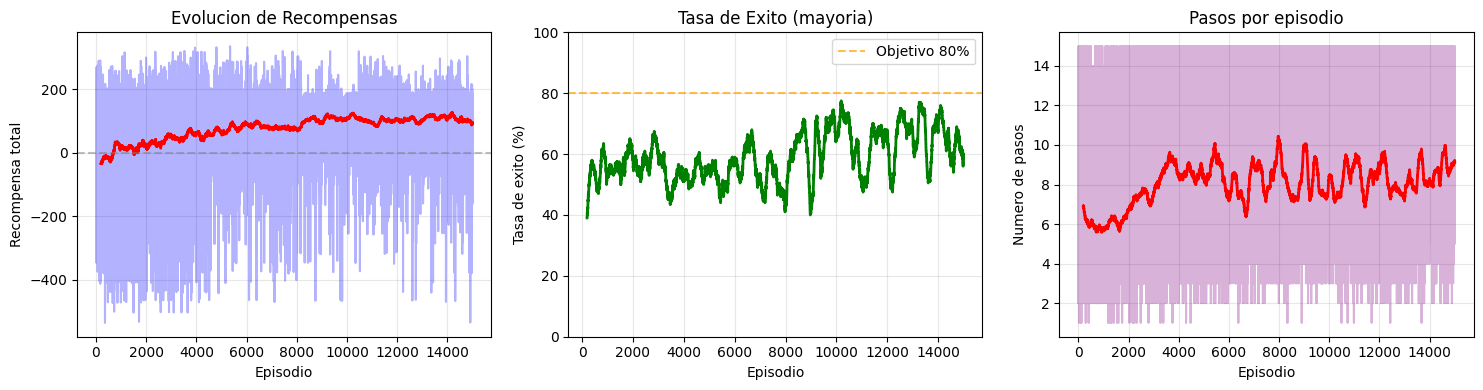


POLITICA OPTIMA APRENDIDA - MEJOR ACCION POR ESTADO

NOTA: El estado es la suma de distancias entre agentes discretizada
      Estado 0 = agentes muy juntos (distancia ~0)
      Estado 20 = agentes muy separados (distancia ~10)

------------------------------------------------------------------------------------------
Estado   | Rango distancia                          | Mejor accion (a1,a2,a3)                  | Valor Q    | Visitas 
------------------------------------------------------------------------------------------
0        | [0.0, 0.5)           | ('esperar', 'esperar', 'observar')       | 105.06     | 117     
1        | [0.5, 1.0)           | ('decidir', 'esperar', 'esperar')        | 111.08     | 1718    
2        | [1.0, 1.5)           | ('esperar', 'esperar', 'decidir')        | 106.92     | 2694    
3        | [1.5, 2.0)           | ('decidir', 'esperar', 'esperar')        | 109.55     | 2087    
4        | [2.0, 2.5)           | ('observar', 'esperar', 'consultar')   

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
import time

# ============================================================
# 1. CONFIGURACION DEL ESPACIO (3 AGENTES)
# ============================================================

N_BINS = 6
X_MIN, X_MAX = 0, 5
Y_MIN, Y_MAX = 0, 5

bins_x = np.linspace(X_MIN, X_MAX, N_BINS + 1)
bins_y = np.linspace(Y_MIN, Y_MAX, N_BINS + 1)

centroides = {
    0: np.array([0.5, 0.5]),
    1: np.array([4.5, 0.5]),
    2: np.array([0.5, 4.5]),
    3: np.array([2.5, 2.5]),  # OBJETIVO
    4: np.array([4.5, 4.5])
}

centroide_objetivo = 3
centroide_objetivo_coords = centroides[centroide_objetivo]
UMBRAL_DECISION = 0.5

# ============================================================
# 2. CLASE AGENTE MEJORADA
# ============================================================

class Agente:
    """Agente con creencia sobre el centroide objetivo"""
    
    def __init__(self, id_agente, ruido_std, creencia_inicial=None):
        self.id = id_agente
        self.ruido_std = ruido_std  # Desviación estándar del ruido en observaciones
        
        if creencia_inicial is None:
            # Creencia inicial aleatoria alrededor del centroide objetivo
            self.creencia = centroide_objetivo_coords + np.random.randn(2) * 3.0
        else:
            self.creencia = creencia_inicial.copy()
        
        # Asegurar que la creencia está dentro de los límites
        self.creencia = np.clip(self.creencia, X_MIN, X_MAX)
        
        self.decision = None  # Almacena la decisión final (índice del centroide)
        self.ha_decidido = False
    
    def observar(self):
        """
        Simula una observación del centroide objetivo con ruido.
        Retorna: observación (x, y) con ruido Gaussiano
        """
        ruido = np.random.randn(2) * self.ruido_std
        observacion = centroide_objetivo_coords + ruido
        observacion = np.clip(observacion, X_MIN, X_MAX)
        return observacion
    
    def actualizar_por_observacion(self, observacion, beta=2.0, alpha=0.3):
        """
        Actualización aditiva: combinar creencia con observación.
        Es más intuitiva y preserva la escala.
        """
        # Mover hacia la observación con factor alpha
        self.creencia = (1 - alpha) * self.creencia + alpha * observacion
        self.creencia = np.clip(self.creencia, X_MIN, X_MAX)
        return self.creencia
    
    def consultar(self, otras_creencias):
        """
        Actualiza la creencia consultando a otros agentes.
        Combina las creencias usando un promedio ponderado.
        """
        todas_creencias = [self.creencia] + otras_creencias
        self.creencia = np.mean(todas_creencias, axis=0)
        self.creencia = np.clip(self.creencia, X_MIN, X_MAX)
        return self.creencia
    
    def decidir(self):
        """
        Decide cuál centroide cree que es el correcto
        basado en la distancia mínima a su creencia actual.
        """
        distancias = {idx: np.linalg.norm(self.creencia - centroide) 
                     for idx, centroide in centroides.items()}
        self.decision = min(distancias, key=distancias.get)
        self.ha_decidido = True
        return self.decision
    
    def reset(self):
        """Reinicia el agente para un nuevo episodio"""
        self.creencia = centroide_objetivo_coords + np.random.randn(2) * 2.0
        self.creencia = np.clip(self.creencia, X_MIN, X_MAX)
        self.decision = None
        self.ha_decidido = False

# ============================================================
# 3. FUNCION DE ESTADO SIMPLIFICADO
# ============================================================

def estado_simplificado(env, max_distancia=14.0, num_buckets=40):
    """
    Calcula un estado simplificado basado en la suma de distancias entre agentes.
    
    f(x1,y1,x2,y2,x3,y3) = sum_{i<j} ||(xi,yi) - (xj,yj)||
    
    Esto mide que tan dispersos o juntos estan los 3 agentes.
    Luego se discretiza en num_buckets buckets desde 0 hasta max_distancia.
    
    Parametros:
    - env: entorno con los agentes
    - max_distancia: valor maximo de la suma de distancias (por defecto 10.0)
    - num_buckets: numero de buckets/estados (por defecto 21)
    
    Retorna:
    - bucket: entero entre 0 y num_buckets-1
    """
    # Obtener posiciones de los 3 agentes
    posiciones = []
    for agente in env.agentes:
        x = max(X_MIN, min(X_MAX, agente.creencia[0]))
        y = max(Y_MIN, min(Y_MAX, agente.creencia[1]))
        posiciones.append(np.array([x, y]))
    
    # Calcular suma de distancias entre todos los pares de agentes
    suma_distancias = 0
    for i in range(3):
        for j in range(i+1, 3):
            distancia = np.linalg.norm(posiciones[i] - posiciones[j])
            suma_distancias += distancia
    
    # Calcular el bucket usando division directa
    # El tamanio de cada bucket es max_distancia / num_buckets
    bucket_size = max_distancia / num_buckets
    
    # El bucket es el piso de (suma_distancias / bucket_size)
    # Si suma_distancias >= max_distancia, bucket sera >= num_buckets
    bucket = int(suma_distancias / bucket_size)
    
    # Ajustar para que no supere el maximo indice
    # Si suma_distancias es muy grande, bucket puede ser mayor que num_buckets-1
    # En ese caso, lo asignamos al ultimo bucket
    if bucket >= num_buckets:
        bucket = num_buckets - 1
    
    return bucket  # Retorna un entero entre 0 y num_buckets-1

def ha_decidido(agente):
    """Determina si un agente ha decidido"""
    return agente.ha_decidido

def obtener_decision(agente):
    """Retorna el indice del centroide elegido o None"""
    return agente.decision if agente.ha_decidido else None


# ============================================================
# 4. ENTORNO PARA 3 AGENTES
# ============================================================

class Entorno3Agentes:
    """Entorno con 3 agentes y dinamica de colaboracion"""
    
    def __init__(self, max_pasos=25):
        self.N = 3
        self.max_pasos = max_pasos
        self.paso_actual = 0
        
        # Parametros de ruido para cada agente
        ruidos = [0.5, 1.0, 0.8]  # 3 agentes con diferente precision
        
        # Crear agentes con la nueva clase
        self.agentes = [Agente(i, ruidos[i]) for i in range(3)]
        
        # Costos de acciones
        self.costos = {
            'esperar': -0.2,
            'observar': -1.0,
            'consultar': -0.5,
            'decidir': 0.0
        }
        
        # Historial
        self.historial_creencias = []
        self.historial_recompensas = []
        self.historial_acciones = []
    
    def obtener_estado(self):
        estado = []
        for agente in self.agentes:
            estado.extend(agente.creencia)
        return np.array(estado)
    
    def calcular_recompensa(self, acciones):
        """Funcion de recompensa para 3 agentes"""
        # Costo individual
        costo_total = sum(self.costos[acc] for acc in acciones)
        
        # Verificar acuerdos parciales (mayoria)
        decisiones_actuales = [a.decision for a in self.agentes if a.ha_decidido]
        
        delta_acuerdo = 0
        if len(decisiones_actuales) >= 2:  # Al menos 2 han decidido
            # Verificar si hay mayoria
            from collections import Counter
            conteo = Counter(decisiones_actuales)
            max_votos = max(conteo.values())
            if max_votos >= 2:  # Hay mayoria
                delta_acuerdo = 15
            else:
                delta_acuerdo = -30
        
        # Verificar final del episodio
        delta_final = 0
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)
        
        if todos_han_decidido:
            decisiones = [a.decision for a in self.agentes]
            if len(set(decisiones)) == 1 and decisiones[0] == centroide_objetivo:
                delta_final = 150  # Exito total: todos al objetivo
            elif len(set(decisiones)) == 1:
                delta_final = 30   # Todos de acuerdo pero objetivo equivocado
            elif len(set(decisiones)) == 2:
                # Mayoria al objetivo?
                if decisiones.count(centroide_objetivo) >= 2:
                    delta_final = 50  # Mayoria acerto
                else:
                    delta_final = -50
            else:
                delta_final = -100  # Desacuerdo total
        
        return costo_total + delta_acuerdo + delta_final
    
    def step(self, acciones):
        """Ejecuta un paso en el entorno"""
        self.paso_actual += 1
        
        # Ejecutar acciones
        for i, accion in enumerate(acciones):
            agente = self.agentes[i]
            
            if accion == 'observar' and not agente.ha_decidido:
                obs = agente.observar()
                agente.actualizar_por_observacion(obs)
            elif accion == 'consultar' and not agente.ha_decidido:
                otras_creencias = [a.creencia for j, a in enumerate(self.agentes) 
                                  if j != i and not a.ha_decidido]
                if otras_creencias:
                    agente.consultar(otras_creencias)
            elif accion == 'decidir' and not agente.ha_decidido:
                agente.decidir()
        
        # Calcular recompensa
        recompensa = self.calcular_recompensa(acciones)
        
        # Verificar si termino
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)
        done = todos_han_decidido or self.paso_actual >= self.max_pasos
        
        # Guardar historial
        self.historial_creencias.append([a.creencia.copy() for a in self.agentes])
        self.historial_recompensas.append(recompensa)
        self.historial_acciones.append(acciones)
        
        info = {
            'paso': self.paso_actual,
            'decisiones': [a.decision for a in self.agentes],
            'creencias': [a.creencia.copy() for a in self.agentes]
        }
        
        return self.obtener_estado(), recompensa, done, info
    
    def reset(self):
        """Reinicia el entorno"""
        self.paso_actual = 0
        for agente in self.agentes:
            agente.reset()
        self.historial_creencias = [[a.creencia.copy() for a in self.agentes]]
        self.historial_recompensas = []
        self.historial_acciones = []
        return self.obtener_estado()


# ============================================================
# 5. ACCIONES VALIDAS PARA 3 AGENTES
# ============================================================

# Todas las combinaciones posibles de acciones para 3 agentes
TODAS_ACCIONES = []
for a1 in ['esperar', 'observar', 'consultar', 'decidir']:
    for a2 in ['esperar', 'observar', 'consultar', 'decidir']:
        for a3 in ['esperar', 'observar', 'consultar', 'decidir']:
            TODAS_ACCIONES.append((a1, a2, a3))

print(f"Acciones totales para 3 agentes: {len(TODAS_ACCIONES)}")

def acciones_validas(env):
    """Filtra acciones: si ya decidio, solo puede esperar"""
    decididos = [ha_decidido(agente) for agente in env.agentes]
    validas = []
    for accion in TODAS_ACCIONES:
        valida = True
        for i in range(3):
            if decididos[i] and accion[i] != 'esperar':
                valida = False
                break
        if valida:
            validas.append(accion)
    return validas


# ============================================================
# 6. AGENTE Q-LEARNING CON ESTADO SIMPLIFICADO
# ============================================================

class AgenteQLearning:
    """
    Agente Q-Learning que usa el estado simplificado basado en distancias entre agentes.
    """
    
    def __init__(self, alpha=0.1, gamma=0.95, epsilon=0.5):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.Q = defaultdict(float)  # Ahora el estado es un entero (0-20)
        self.visitas = defaultdict(int)
    
    def seleccionar_accion(self, env):
        """
        Selecciona accion usando epsilon-greedy con el estado simplificado.
        """
        # Usamos el estado simplificado (un entero) en lugar del estado completo
        estado = estado_simplificado(env)
        acciones = acciones_validas(env)
        
        if not acciones:
            return ('esperar', 'esperar', 'esperar')
        
        if random.random() < self.epsilon:
            return random.choice(acciones)
        
        valores = [self.Q[(estado, a)] for a in acciones]
        max_valor = max(valores)
        mejores = [a for a, v in zip(acciones, valores) if v == max_valor]
        return random.choice(mejores)
    
    def actualizar(self, estado_anterior, accion, recompensa, env_siguiente, done):
        """
        Actualiza Q(s,a) usando la ecuacion de Bellman.
        """
        # Usamos el estado simplificado para el siguiente estado
        estado_siguiente = estado_simplificado(env_siguiente)
        acciones_sig = acciones_validas(env_siguiente)
        
        if done:
            objetivo = recompensa
        else:
            max_futuro = max([self.Q[(estado_siguiente, a)] for a in acciones_sig]) if acciones_sig else 0
            objetivo = recompensa + self.gamma * max_futuro
        
        clave = (estado_anterior, accion)
        self.Q[clave] = self.Q[clave] + self.alpha * (objetivo - self.Q[clave])
        self.visitas[clave] += 1
    
    def reducir_epsilon(self, factor=0.9995, minimo=0.05):
        self.epsilon = max(minimo, self.epsilon * factor)
    
    def imprimir_politica_optima(self):
        """
        IMPRIME LA MEJOR ACCION PARA CADA ESTADO
        Esta es la funcion que muestra los resultados finales
        """
        print("\n" + "=" * 90)
        print("POLITICA OPTIMA APRENDIDA - MEJOR ACCION POR ESTADO")
        print("=" * 90)
        print("\nNOTA: El estado es la suma de distancias entre agentes discretizada")
        print("      Estado 0 = agentes muy juntos (distancia ~0)")
        print("      Estado 20 = agentes muy separados (distancia ~10)")
        print("\n" + "-" * 90)
        print(f"{'Estado':<8} | {'Rango distancia':<40} | {'Mejor accion (a1,a2,a3)':<40} | {'Valor Q':<10} | {'Visitas':<8}")
        print("-" * 90)
        
        # Para cada posible estado simplificado (0 a 20)
        for estado in range(21):
            # Calcular el rango de distancia que representa este estado
            distancia_min = estado * 0.5
            distancia_max = (estado + 1) * 0.5
            rango = f"[{distancia_min:.1f}, {distancia_max:.1f})"
            
            # Encontrar la mejor accion para este estado
            mejor_valor = -float('inf')
            mejor_accion = None
            visitas_mejor = 0
            
            # Buscar entre todas las acciones posibles
            for accion in TODAS_ACCIONES:
                valor = self.Q[(estado, accion)]
                if valor > mejor_valor:
                    mejor_valor = valor
                    mejor_accion = accion
                    visitas_mejor = self.visitas[(estado, accion)]
            
            # Imprimir el resultado
            if mejor_accion is not None:
                print(f"{estado:<8} | {rango:<20} | {str(mejor_accion):<40} | {mejor_valor:<10.2f} | {visitas_mejor:<8}")
        
        print("-" * 90)
        
        # Resumen de la politica
        print("\nRESUMEN DE LA POLITICA OPTIMA:")
        print("-" * 90)
        
        # Contar que acciones son mas frecuentes
        from collections import Counter
        conteo_acciones = Counter()
        for estado in range(21):
            mejor_valor = -float('inf')
            mejor_accion = None
            for accion in TODAS_ACCIONES:
                valor = self.Q[(estado, accion)]
                if valor > mejor_valor:
                    mejor_valor = valor
                    mejor_accion = accion
            if mejor_accion:
                conteo_acciones[mejor_accion] += 1
        
        print("\nFrecuencia de acciones en la politica optima:")
        for accion, count in conteo_acciones.most_common():
            print(f"  {accion}: {count} estados ({count/21*100:.1f}%)")
        
        print("=" * 90)


# ============================================================
# 7. ENTRENAMIENTO
# ============================================================

def entrenar(episodios=5000, max_pasos=15, verbose=True):
    """
    Entrenamiento con estado simplificado.
    """
    agente = AgenteQLearning(alpha=0.1, gamma=0.95, epsilon=0.5)
    
    recompensas_por_episodio = []
    exitos_por_episodio = []
    pasos_por_episodio = []
    
    print("=" * 70)
    print("ENTRENAMIENTO Q-LEARNING - 3 AGENTES CON ESTADO SIMPLIFICADO")
    print("=" * 70)
    print()
    print("NUEVO ESPACIO DE ESTADOS:")
    print("   Estado simplificado: f(x1,y1,x2,y2,x3,y3) = sum_{i<j} ||(xi,yi)-(xj,yj)||")
    print("PARAMETROS:")
    print(f"   Acciones posibles: {len(TODAS_ACCIONES)}")
    print(f"   Episodios: {episodios}")
    print(f"   Maximo pasos por episodio: {max_pasos}")
    print(f"   alpha={agente.alpha}, gamma={agente.gamma}, epsilon_inicial={agente.epsilon}")
    print("-" * 70)
    
    start_time = time.time()
    
    for episodio in range(episodios):
        env = Entorno3Agentes(max_pasos=max_pasos)
        # Usamos estado simplificado
        estado_actual = estado_simplificado(env)
        done = False
        recompensa_total = 0
        pasos = 0
        
        while not done:
            accion = agente.seleccionar_accion(env)
            _, recompensa, done, _ = env.step(accion)
            recompensa_total += recompensa
            
            estado_anterior = estado_actual
            estado_actual = estado_simplificado(env)
            agente.actualizar(estado_anterior, accion, recompensa, env, done)
            pasos += 1
        
        # Verificar exito (mayoria al objetivo)
        decisiones = [obtener_decision(a) for a in env.agentes]
        if None not in decisiones:
            exito = decisiones.count(centroide_objetivo) >= 2
        else:
            exito = False
        
        recompensas_por_episodio.append(recompensa_total)
        exitos_por_episodio.append(exito)
        pasos_por_episodio.append(pasos)
        
        # Reducir epsilon gradualmente
        if episodio > 2000:
            agente.reducir_epsilon(0.9995)
        
        # Mostrar progreso cada 500 episodios
        if verbose and (episodio + 1) % 500 == 0:
            avg_reward = np.mean(recompensas_por_episodio[-500:])
            avg_success = np.mean(exitos_por_episodio[-500:]) * 100
            avg_steps = np.mean(pasos_por_episodio[-500:])
            elapsed = time.time() - start_time
            print(f"Ep {episodio+1:5d}: R={avg_reward:6.1f}, Exito={avg_success:5.1f}%, "
                  f"Pasos={avg_steps:4.1f}, epsilon={agente.epsilon:.3f}, tiempo={elapsed:.0f}s")
    
    print("-" * 70)
    print(f"ENTRENAMIENTO COMPLETADO en {time.time() - start_time:.0f} segundos")
    print(f"Tasa de exito ultimos 500 episodios: {np.mean(exitos_por_episodio[-500:])*100:.1f}%")
    print("=" * 70)
    
    return agente, recompensas_por_episodio, exitos_por_episodio, pasos_por_episodio


# ============================================================
# 8. EVALUACION FINAL
# ============================================================

def evaluar(agente, n_pruebas=100):
    """Evalua la politica aprendida (sin exploracion)"""
    epsilon_original = agente.epsilon
    agente.epsilon = 0
    
    resultados = []
    
    print("\n" + "=" * 70)
    print("EVALUACION DE LA POLITICA APRENDIDA - 3 AGENTES")
    print("=" * 70)
    
    for i in range(n_pruebas):
        env = Entorno3Agentes(max_pasos=25)
        done = False
        recompensa_total = 0
        pasos = 0
        
        while not done:
            accion = agente.seleccionar_accion(env)
            _, recompensa, done, _ = env.step(accion)
            recompensa_total += recompensa
            pasos += 1
        
        decisiones = [obtener_decision(a) for a in env.agentes]
        if None not in decisiones:
            exito = decisiones.count(centroide_objetivo) >= 2
        else:
            exito = False
        
        resultados.append((recompensa_total, exito, pasos))
    
    exitos = [r[1] for r in resultados]
    recompensas = [r[0] for r in resultados]
    pasos_list = [r[2] for r in resultados]
    
    print(f"\nResultados sobre {n_pruebas} pruebas:")
    print(f"  Tasa de exito (mayoria al objetivo): {np.mean(exitos)*100:.1f}%")
    print(f"  Recompensa promedio: {np.mean(recompensas):.1f}")
    print(f"  Pasos promedio: {np.mean(pasos_list):.1f}")
    print(f"\nDistribucion:")
    print(f"  Exitos: {sum(exitos)}")
    print(f"  Fallos: {n_pruebas - sum(exitos)}")
    
    agente.epsilon = epsilon_original
    return resultados


# ============================================================
# 9. VISUALIZACION
# ============================================================

def graficar_resultados(recompensas, exitos, pasos):
    """Grafica las curvas de aprendizaje"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    window = 200  # Ventana mas pequena para 5000 episodios
    
    # 1. Recompensas
    axes[0].plot(recompensas, alpha=0.3, color='blue')
    if len(recompensas) >= window:
        ma = np.convolve(recompensas, np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(recompensas)), ma, 'r-', linewidth=2)
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Episodio')
    axes[0].set_ylabel('Recompensa total')
    axes[0].set_title('Evolucion de Recompensas')
    axes[0].grid(True, alpha=0.3)
    
    # 2. Tasa de exito
    success_rates = []
    for i in range(len(exitos) - window + 1):
        success_rates.append(np.mean(exitos[i:i+window]) * 100)
    axes[1].plot(range(window-1, len(exitos)), success_rates, 'g-', linewidth=2)
    axes[1].axhline(y=80, color='orange', linestyle='--', alpha=0.7, label='Objetivo 80%')
    axes[1].set_xlabel('Episodio')
    axes[1].set_ylabel('Tasa de exito (%)')
    axes[1].set_title('Tasa de Exito (mayoria)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 100)
    
    # 3. Pasos por episodio
    axes[2].plot(pasos, alpha=0.3, color='purple')
    if len(pasos) >= window:
        ma_pasos = np.convolve(pasos, np.ones(window)/window, mode='valid')
        axes[2].plot(range(window-1, len(pasos)), ma_pasos, 'r-', linewidth=2)
    axes[2].set_xlabel('Episodio')
    axes[2].set_ylabel('Numero de pasos')
    axes[2].set_title('Pasos por episodio')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# ============================================================
# 10. EJECUCION PRINCIPAL
# ============================================================

if __name__ == "__main__":
    # Entrenar con 5000 episodios
    agente, rewards, successes, steps = entrenar(episodios=15000, max_pasos=15)
    
    # Graficar
    graficar_resultados(rewards, successes, steps)
    
    # IMPRIMIR LA MEJOR ACCION PARA CADA ESTADO
    agente.imprimir_politica_optima()
    
    # Evaluar
    resultados = evaluar(agente, n_pruebas=100)

ALGORITMO 3.4.1 - Q-LEARNING

PASO 1: Inicialización
  - Q0(x,a) = 0 para todo (x,a)
  - N = 5000 iteraciones
  - αn(x,a) = 1/(1+visitas) → cumple ∑αn=∞ y ∑αn²<∞
  - γ = 0.95
  - ε inicial = 0.9
  - ε final = 0.05

ESTADO SIMPLIFICADO:
  - f(x1,y1,x2,y2,x3,y3) = sum_{i<j} distancia entre agentes
  - Discretizado en 21 buckets (0 a 20)
  - Total estados posibles: 21
  - Total acciones posibles: 64
--------------------------------------------------------------------------------
n=  500/5000: R= -46.5, Éxito= 61.4%, Pasos= 7.3, ε=0.815
n= 1000/5000: R= -40.7, Éxito= 62.0%, Pasos= 7.9, ε=0.730
n= 1500/5000: R= -23.4, Éxito= 66.2%, Pasos= 8.5, ε=0.645
n= 2000/5000: R=   4.2, Éxito= 63.4%, Pasos= 8.9, ε=0.560
n= 2500/5000: R=  -8.6, Éxito= 59.6%, Pasos= 9.4, ε=0.475
n= 3000/5000: R=  -2.1, Éxito= 51.8%, Pasos=10.1, ε=0.390
n= 3500/5000: R= -37.5, Éxito= 47.4%, Pasos=10.7, ε=0.305
n= 4000/5000: R= -11.2, Éxito= 37.6%, Pasos=11.7, ε=0.220
n= 4500/5000: R=   3.8, Éxito= 32.8%, Pasos=12.4, ε=0.1

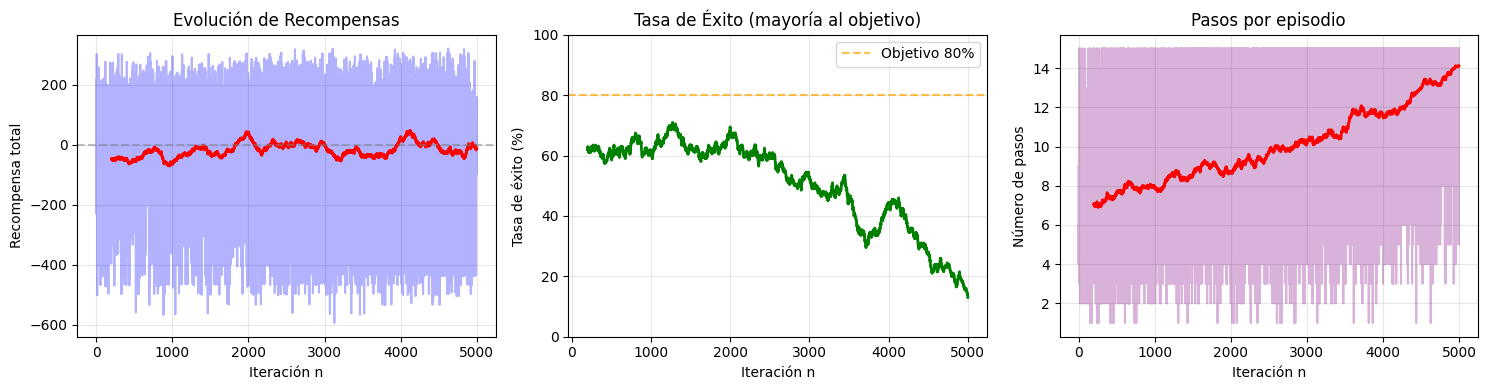


EVALUACIÓN DE LA POLÍTICA APRENDIDA
Usando ε=0 (solo explotación)
--------------------------------------------------------------------------------

RESULTADOS (100 pruebas):
  Tasa de éxito: 0.0% (0/100)
  Recompensa promedio: -89.11
  Pasos promedio: 25.00


In [22]:
import numpy as np
import random
from collections import defaultdict
import matplotlib.pyplot as plt

"""
================================================================================
ALGORITMO 3.4.1 - Q-LEARNING
================================================================================

Este código implementa paso a paso el algoritmo Q-learning para 3 agentes
con un estado simplificado basado en la suma de distancias entre agentes.

PASOS DEL ALGORITMO:
1. Inicializar Q0, N, n=0, y αn(x,a) con ∑αn = ∞ y ∑αn² < ∞
2. Seleccionar estado Xn = xn y acción Yn = an (ε-greedy)
3. Observar r(xn,an) y nuevo estado Xn+1 = s
4. Actualizar Qn+1 usando ecuación (3.4.1)
5. Si n+1 = N, ir al paso 6, sino n=n+1 y volver paso 2 con Xn=s
6. Obtener política óptima dN(x) = argmax_a QN(x,a)

================================================================================
"""

# ============================================================================
# CONFIGURACION INICIAL
# ============================================================================

# Espacio de coordenadas
X_MIN, X_MAX = 0, 5
Y_MIN, Y_MAX = 0, 5

# Centroides (puntos de interés)
centroides = {
    0: np.array([0.5, 0.5]),
    1: np.array([4.5, 0.5]),
    2: np.array([0.5, 4.5]),
    3: np.array([2.5, 2.5]),  # OBJETIVO
    4: np.array([4.5, 4.5])
}
centroide_objetivo = 3
centroide_objetivo_coords = centroides[centroide_objetivo]

# ============================================================================
# CLASE AGENTE
# ============================================================================

class Agente:
    """Agente con creencia sobre el centroide objetivo"""
    
    def __init__(self, id_agente, ruido_std):
        self.id = id_agente
        self.ruido_std = ruido_std
        self.reset()
    
    def reset(self):
        """Reinicia el agente para un nuevo episodio"""
        # Creencia inicial aleatoria alrededor del centroide objetivo
        self.creencia = centroide_objetivo_coords + np.random.randn(2) * 2.0
        self.creencia = np.clip(self.creencia, X_MIN, X_MAX)
        self.decision = None
        self.ha_decidido = False
    
    def observar(self):
        """Simula una observación con ruido"""
        ruido = np.random.randn(2) * self.ruido_std
        observacion = centroide_objetivo_coords + ruido
        return np.clip(observacion, X_MIN, X_MAX)
    
    def actualizar_por_observacion(self, observacion, alpha=0.3):
        """Actualiza creencia hacia la observación"""
        self.creencia = (1 - alpha) * self.creencia + alpha * observacion
        self.creencia = np.clip(self.creencia, X_MIN, X_MAX)
    
    def consultar(self, otras_creencias):
        """Promedia creencia con otros agentes"""
        if otras_creencias:
            todas = [self.creencia] + otras_creencias
            self.creencia = np.mean(todas, axis=0)
            self.creencia = np.clip(self.creencia, X_MIN, X_MAX)
    
    def decidir(self):
        """Decide el centroide más cercano a su creencia"""
        distancias = {idx: np.linalg.norm(self.creencia - c) 
                     for idx, c in centroides.items()}
        self.decision = min(distancias, key=distancias.get)
        self.ha_decidido = True
        return self.decision

# ============================================================================
# FUNCION DE ESTADO SIMPLIFICADO (PASO 2 - OBTENER Xn)
# ============================================================================

def obtener_estado_simplificado(env, max_distancia=10.0, num_buckets=21):
    """
    Convierte las posiciones de los 3 agentes en un estado discreto.
    
    f(x1,y1,x2,y2,x3,y3) = sum_{i<j} ||(xi,yi)-(xj,yj)||
    """
    # Obtener posiciones
    posiciones = []
    for agente in env.agentes:
        posiciones.append(agente.creencia.copy())
    
    # Calcular suma de distancias entre pares
    suma_distancias = 0
    for i in range(3):
        for j in range(i+1, 3):
            distancia = np.linalg.norm(posiciones[i] - posiciones[j])
            suma_distancias += distancia
    
    # Discretizar
    bucket_size = max_distancia / num_buckets
    bucket = int(suma_distancias / bucket_size)
    
    # Asegurar que está en rango
    if bucket >= num_buckets:
        bucket = num_buckets - 1
    
    return bucket  # Estado entre 0 y num_buckets-1

# ============================================================================
# ENTORNO PARA 3 AGENTES
# ============================================================================

class Entorno:
    """Entorno con 3 agentes"""
    
    def __init__(self, max_pasos=25):
        self.max_pasos = max_pasos
        self.paso_actual = 0
        
        # 3 agentes con diferente precisión
        ruidos = [0.5, 1.0, 0.8]
        self.agentes = [Agente(i, ruidos[i]) for i in range(3)]
        
        # Costos de acciones
        self.costos = {
            'esperar': -1.2,
            'observar': -1.0,
            'consultar': -0.5,
            'decidir': 0.0
        }
    
    def _calcular_recompensa(self, acciones):
        """Calcula la recompensa según las acciones tomadas"""
        
        # Costo individual
        costo_total = sum(self.costos[acc] for acc in acciones)
        
        # Recompensa por acuerdos parciales
        decisiones = [a.decision for a in self.agentes if a.ha_decidido]
        delta_acuerdo = 0
        
        if len(decisiones) >= 2:
            if decisiones.count(centroide_objetivo) >= 2:
                delta_acuerdo = 15
            else:
                delta_acuerdo = -30
        
        # Recompensa final del episodio
        delta_final = 0
        todos_decidieron = all(a.ha_decidido for a in self.agentes)
        
        if todos_decidieron:
            decisions = [a.decision for a in self.agentes]
            if decisions.count(centroide_objetivo) == 3:
                delta_final = 150  # Éxito total
            elif decisions.count(centroide_objetivo) >= 2:
                delta_final = 50   # Éxito por mayoría
            elif len(set(decisions)) == 1:
                delta_final = 30   # Acuerdo pero no objetivo
            else:
                delta_final = -100  # Desacuerdo
        
        return costo_total + delta_acuerdo + delta_final
    
    def step(self, acciones):
        """Ejecuta un paso (PASO 3 del algoritmo)"""
        self.paso_actual += 1
        
        # Ejecutar acciones
        for i, accion in enumerate(acciones):
            agente = self.agentes[i]
            
            if accion == 'observar' and not agente.ha_decidido:
                obs = agente.observar()
                agente.actualizar_por_observacion(obs)
            elif accion == 'consultar' and not agente.ha_decidido:
                otras = [a.creencia for j, a in enumerate(self.agentes) 
                        if j != i and not a.ha_decidido]
                if otras:
                    agente.consultar(otras)
            elif accion == 'decidir' and not agente.ha_decidido:
                agente.decidir()
        
        # Calcular recompensa
        recompensa = self._calcular_recompensa(acciones)
        
        # Verificar si terminó
        terminado = all(a.ha_decidido for a in self.agentes) or self.paso_actual >= self.max_pasos
        
        return recompensa, terminado
    
    def reset(self):
        """Reinicia el entorno"""
        self.paso_actual = 0
        for agente in self.agentes:
            agente.reset()

# ============================================================================
# ACCIONES POSIBLES
# ============================================================================

ACCIONES = ['esperar', 'observar', 'consultar', 'decidir']

# Todas las combinaciones para 3 agentes
TODAS_ACCIONES = []
for a1 in ACCIONES:
    for a2 in ACCIONES:
        for a3 in ACCIONES:
            TODAS_ACCIONES.append((a1, a2, a3))

def acciones_validas(env):
    """Filtra acciones según qué agentes ya decidieron"""
    decididos = [a.ha_decidido for a in env.agentes]
    validas = []
    for accion in TODAS_ACCIONES:
        valida = True
        for i in range(3):
            if decididos[i] and accion[i] != 'esperar':
                valida = False
                break
        if valida:
            validas.append(accion)
    return validas

# ============================================================================
# ALGORITMO 3.4.1 - Q-LEARNING
# ============================================================================

class QLearning:
    """
    Implementación del Algoritmo 3.4.1
    """
    
    def __init__(self, gamma=0.95, alpha_inicial=0.5):
        """
        Inicialización (PASO 1 del algoritmo)
        
        Q0 ∈ Q: Tabla Q inicializada en 0
        N: Número de iteraciones (se define en entrenar)
        n = 0: Contador de iteraciones
        αn: Tasa de aprendizaje que cumple ∑αn = ∞ y ∑αn² < ∞
        """
        self.gamma = gamma              # Factor de descuento
        self.alpha_inicial = alpha_inicial  # α inicial
        self.Q = defaultdict(float)     # Q0 = 0 para todo (x,a)
        self.visitas = defaultdict(int) # Contador de visitas para αn(x,a)
        self.n = 0                      # Contador de iteraciones
        
    def alpha_n(self, estado, accion):
        """
        αn(x,a) = 1 / (1 + visitas(x,a))
        
        Esta función cumple:
        ∑αn = ∞ (porque es serie armónica)
        ∑αn² < ∞ (porque ∑1/n² converge)
        """
        v = self.visitas[(estado, accion)]
        return 1.0 / (1.0 + v)
    
    def seleccionar_accion(self, env, epsilon):
        """
        PASO 2: Seleccionar Yn = an ∈ A(xn)
        
        Usamos política ε-greedy:
        - Con probabilidad ε: acción aleatoria (exploración)
        - Con probabilidad 1-ε: argmax_a Q(xn, a) (explotación)
        """
        # Obtener estado actual Xn = xn
        estado = obtener_estado_simplificado(env)
        
        # Obtener acciones válidas A(xn)
        acciones = acciones_validas(env)
        
        if not acciones:
            return ('esperar', 'esperar', 'esperar')
        
        # Decisión ε-greedy
        if random.random() < epsilon:
            # Exploración: acción aleatoria
            return random.choice(acciones)
        else:
            # Explotación: argmax_a Q(xn, a)
            valores = [self.Q[(estado, a)] for a in acciones]
            max_valor = max(valores)
            mejores = [a for a, v in zip(acciones, valores) if v == max_valor]
            return random.choice(mejores)
    
    def actualizar(self, estado_anterior, accion, recompensa, nuevo_estado, es_terminal):
        """
        PASO 4: Actualizar Qn+1 usando ecuación (3.4.1)
        
        Qn+1(x,a) = {
            (1-αn)Qn(x,a) + αn(r + γ·Wn(s))  si (x,a) = (xn,an)
            Qn(x,a)                           si (x,a) ≠ (xn,an)
        }
        
        donde Wn(s) = max_{a'} Qn(s, a')
        """
        
        # Calcular αn(xn, an)
        alpha = self.alpha_n(estado_anterior, accion)
        
        # Calcular Wn(s) = max_{a'} Qn(s, a')
        if es_terminal:
            # Si es terminal, no hay futuro
            objetivo = recompensa
        else:
            # Obtener acciones válidas para el nuevo estado
            # Para simplificar, usamos todas las acciones (el filtro se aplica en selección)
            acciones_futuro = TODAS_ACCIONES
            
            # Calcular max_{a'} Qn(s, a')
            valores_futuro = [self.Q[(nuevo_estado, a)] for a in acciones_futuro]
            max_futuro = max(valores_futuro) if valores_futuro else 0
            
            # Target de Bellman: r + γ·Wn(s)
            objetivo = recompensa + self.gamma * max_futuro
        
        # Obtener Qn(xn, an) actual
        clave = (estado_anterior, accion)
        q_actual = self.Q[clave]
        
        # Ecuación (3.4.1): Qn+1 = (1-αn)Qn + αn(objetivo)
        q_nuevo = (1 - alpha) * q_actual + alpha * objetivo
        
        # Actualizar solo (xn, an), los demás pares quedan igual
        self.Q[clave] = q_nuevo
        
        # Incrementar contador de visitas para este par
        self.visitas[clave] += 1
    
    def obtener_politica_optima(self):
        """
        PASO 6: Obtener dN(x) = argmax_a QN(x,a)
        
        Esta es la política final después del entrenamiento
        """
        politica = {}
        
        # Número de estados posibles (0 a 20 con la discretización actual)
        num_estados = 21
        
        for estado in range(num_estados):
            mejor_valor = -float('inf')
            mejor_accion = None
            
            for accion in TODAS_ACCIONES:
                valor = self.Q[(estado, accion)]
                if valor > mejor_valor:
                    mejor_valor = valor
                    mejor_accion = accion
            
            politica[estado] = (mejor_accion, mejor_valor)
        
        return politica

# ============================================================================
# ENTRENAMIENTO (PASOS 2-5 DEL ALGORITMO)
# ============================================================================

def entrenar_qlearning(episodios=5000, max_pasos=15, epsilon_inicial=0.9, epsilon_final=0.05):
    """
    Ejecuta el Algoritmo 3.4.1 completo
    
    PARÁMETROS:
    - episodios: Número de iteraciones (N)
    - max_pasos: Máximo de pasos por episodio
    - epsilon_inicial: Tasa de exploración inicial
    - epsilon_final: Tasa de exploración final
    """
    
    # PASO 1: Inicialización
    ql = QLearning(gamma=0.95, alpha_inicial=0.5)
    estadisticas = {
        'recompensas': [],
        'exitos': [],
        'pasos': [],
        'epsilon': []
    }
    
    print("=" * 80)
    print("ALGORITMO 3.4.1 - Q-LEARNING")
    print("=" * 80)
    print("\nPASO 1: Inicialización")
    print(f"  - Q0(x,a) = 0 para todo (x,a)")
    print(f"  - N = {episodios} iteraciones")
    print(f"  - αn(x,a) = 1/(1+visitas) → cumple ∑αn=∞ y ∑αn²<∞")
    print(f"  - γ = {ql.gamma}")
    print(f"  - ε inicial = {epsilon_inicial}")
    print(f"  - ε final = {epsilon_final}")
    print()
    print("ESTADO SIMPLIFICADO:")
    print("  - f(x1,y1,x2,y2,x3,y3) = sum_{i<j} distancia entre agentes")
    print("  - Discretizado en 21 buckets (0 a 20)")
    print("  - Total estados posibles: 21")
    print(f"  - Total acciones posibles: {len(TODAS_ACCIONES)}")
    print("-" * 80)
    
    # Bucle principal de entrenamiento
    for n in range(episodios):
        
        # Reiniciar entorno para nuevo episodio
        env = Entorno(max_pasos=max_pasos)
        
        # PASO 2: Seleccionar estado inicial X0 = x0
        estado_actual = obtener_estado_simplificado(env)
        
        # Calcular epsilon (decreciente)
        epsilon = epsilon_inicial - (epsilon_inicial - epsilon_final) * (n / episodios)
        
        terminado = False
        recompensa_total = 0
        pasos = 0
        
        # ================================================================
        # BUCLE POR PASOS DEL EPISODIO (PASOS 2-5)
        # ================================================================
        
        while not terminado:
            
            # PASO 2: Seleccionar acción Yn = an
            accion = ql.seleccionar_accion(env, epsilon)
            
            # PASO 3: Observar r(xn,an) y nuevo estado Xn+1 = s
            recompensa, terminado = env.step(accion)
            nuevo_estado = obtener_estado_simplificado(env)
            
            recompensa_total += recompensa
            pasos += 1
            
            # PASO 4: Actualizar Qn+1 usando ecuación (3.4.1)
            ql.actualizar(estado_actual, accion, recompensa, nuevo_estado, terminado)
            
            # PASO 5: Incrementar n (implícito) y regresar al paso 2 con Xn = s
            estado_actual = nuevo_estado
        
        # ================================================================
        # FIN DEL EPISODIO
        # ================================================================
        
        # Determinar si fue éxito
        decisiones = [a.decision for a in env.agentes if a.ha_decidido]
        exito = False
        if len(decisiones) == 3:
            exito = decisiones.count(centroide_objetivo) >= 2
        
        # Guardar estadísticas
        estadisticas['recompensas'].append(recompensa_total)
        estadisticas['exitos'].append(exito)
        estadisticas['pasos'].append(pasos)
        estadisticas['epsilon'].append(epsilon)
        
        # Mostrar progreso cada 500 episodios
        if (n + 1) % 500 == 0:
            avg_reward = np.mean(estadisticas['recompensas'][-500:])
            avg_success = np.mean(estadisticas['exitos'][-500:]) * 100
            avg_steps = np.mean(estadisticas['pasos'][-500:])
            print(f"n={n+1:5d}/{episodios}: R={avg_reward:6.1f}, "
                  f"Éxito={avg_success:5.1f}%, Pasos={avg_steps:4.1f}, ε={epsilon:.3f}")
    
    print("-" * 80)
    print("ENTRENAMIENTO COMPLETADO")
    print(f"Tasa de éxito últimos 500 episodios: {np.mean(estadisticas['exitos'][-500:])*100:.1f}%")
    print("=" * 80)
    
    return ql, estadisticas

# ============================================================================
# PASO 6: OBTENER POLÍTICA ÓPTIMA
# ============================================================================

def imprimir_politica_optima(ql):
    """
    PASO 6: dN(x) = argmax_a QN(x,a)
    """
    politica = ql.obtener_politica_optima()
    
    print("\n" + "=" * 90)
    print("PASO 6: POLÍTICA ÓPTIMA dN(x) = argmax_a QN(x,a)")
    print("=" * 90)
    print("\nESTADO | SUMA DISTANCIAS    | MEJOR ACCIÓN (a1,a2,a3)                    | VALOR Q")
    print("-" * 90)
    
    for estado in range(21):
        rango_min = estado * 0.476  # 10/21 ≈ 0.476
        rango_max = (estado + 1) * 0.476
        accion, valor = politica[estado]
        
        if accion:
            print(f"  {estado:2d}   | [{rango_min:4.1f}, {rango_max:4.1f})        | {str(accion):<40} | {valor:8.2f}")
    
    print("-" * 90)
    
    # Resumen de acciones más frecuentes
    from collections import Counter
    conteo = Counter()
    for estado in range(21):
        accion, _ = politica[estado]
        if accion:
            conteo[accion] += 1
    
    print("\nRESUMEN DE LA POLÍTICA ÓPTIMA:")
    for accion, count in conteo.most_common(5):
        print(f"  {accion}: {count} estados ({count/21*100:.1f}%)")
    
    print("=" * 90)

# ============================================================================
# EVALUACIÓN DE LA POLÍTICA APRENDIDA
# ============================================================================

def evaluar_politica(ql, n_pruebas=100):
    """
    Evalúa la política aprendida (sin exploración)
    """
    print("\n" + "=" * 80)
    print("EVALUACIÓN DE LA POLÍTICA APRENDIDA")
    print("=" * 80)
    print("Usando ε=0 (solo explotación)")
    print("-" * 80)
    
    exitos = 0
    recompensas = []
    pasos_lista = []
    
    for i in range(n_pruebas):
        env = Entorno(max_pasos=25)
        terminado = False
        recompensa_total = 0
        pasos = 0
        
        while not terminado:
            # Usar ε=0 para solo explotación
            estado = obtener_estado_simplificado(env)
            acciones = acciones_validas(env)
            
            if not acciones:
                break
            
            # Solo explotación: argmax_a Q(x,a)
            valores = [ql.Q[(estado, a)] for a in acciones]
            max_valor = max(valores)
            mejores = [a for a, v in zip(acciones, valores) if v == max_valor]
            accion = random.choice(mejores)
            
            recompensa, terminado = env.step(accion)
            recompensa_total += recompensa
            pasos += 1
        
        decisiones = [a.decision for a in env.agentes if a.ha_decidido]
        if len(decisiones) == 3 and decisiones.count(centroide_objetivo) >= 2:
            exitos += 1
        
        recompensas.append(recompensa_total)
        pasos_lista.append(pasos)
    
    print(f"\nRESULTADOS ({n_pruebas} pruebas):")
    print(f"  Tasa de éxito: {exitos/n_pruebas*100:.1f}% ({exitos}/{n_pruebas})")
    print(f"  Recompensa promedio: {np.mean(recompensas):.2f}")
    print(f"  Pasos promedio: {np.mean(pasos_lista):.2f}")
    print("=" * 80)
    
    return exitos / n_pruebas

# ============================================================================
# VISUALIZACIÓN
# ============================================================================

def graficar_resultados(estadisticas):
    """Grafica las curvas de aprendizaje"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    window = 200
    
    # 1. Recompensas
    axes[0].plot(estadisticas['recompensas'], alpha=0.3, color='blue')
    if len(estadisticas['recompensas']) >= window:
        ma = np.convolve(estadisticas['recompensas'], np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(estadisticas['recompensas'])), ma, 'r-', linewidth=2)
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Iteración n')
    axes[0].set_ylabel('Recompensa total')
    axes[0].set_title('Evolución de Recompensas')
    axes[0].grid(True, alpha=0.3)
    
    # 2. Tasa de éxito
    success_rates = []
    for i in range(len(estadisticas['exitos']) - window + 1):
        success_rates.append(np.mean(estadisticas['exitos'][i:i+window]) * 100)
    axes[1].plot(range(window-1, len(estadisticas['exitos'])), success_rates, 'g-', linewidth=2)
    axes[1].axhline(y=80, color='orange', linestyle='--', alpha=0.7, label='Objetivo 80%')
    axes[1].set_xlabel('Iteración n')
    axes[1].set_ylabel('Tasa de éxito (%)')
    axes[1].set_title('Tasa de Éxito (mayoría al objetivo)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 100)
    
    # 3. Pasos por episodio
    axes[2].plot(estadisticas['pasos'], alpha=0.3, color='purple')
    if len(estadisticas['pasos']) >= window:
        ma_pasos = np.convolve(estadisticas['pasos'], np.ones(window)/window, mode='valid')
        axes[2].plot(range(window-1, len(estadisticas['pasos'])), ma_pasos, 'r-', linewidth=2)
    axes[2].set_xlabel('Iteración n')
    axes[2].set_ylabel('Número de pasos')
    axes[2].set_title('Pasos por episodio')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# EJECUCIÓN PRINCIPAL
# ============================================================================

if __name__ == "__main__":
    
    # EJECUTAR ALGORITMO 3.4.1 (PASOS 1-5)
    ql, estadisticas = entrenar_qlearning(episodios=5000, max_pasos=15)
    
    # PASO 6: Obtener y mostrar política óptima
    imprimir_politica_optima(ql)
    
    # Visualizar resultados
    graficar_resultados(estadisticas)
    
    # Evaluar política aprendida
    evaluar_politica(ql, n_pruebas=100)

ALGORITMO 3.4.1 - Q-LEARNING

PASO 1: Inicialización
  - Q0(x,a) = 0 para todo (x,a)
  - N = 5000 iteraciones
  - αn(x,a) = 1/(1+visitas) → cumple ∑αn=∞ y ∑αn²<∞
  - γ = 0.95
  - ε inicial = 0.9
  - ε final = 0.05

ESTADO SIMPLIFICADO:
  - f(x1,y1,x2,y2,x3,y3) = sum_{i<j} distancia entre agentes
  - max_distancia = 15.0
  - num_buckets = 40
  - bucket_size = 0.375
  - Total estados posibles: 40 (0 a 39)
  - Total acciones posibles: 64
--------------------------------------------------------------------------------
n=  500/5000: R= -43.3, Éxito= 61.0%, Pasos= 7.0, ε=0.815
n= 1000/5000: R= -37.0, Éxito= 64.6%, Pasos= 7.8, ε=0.730
n= 1500/5000: R= -33.2, Éxito= 62.6%, Pasos= 8.3, ε=0.645
n= 2000/5000: R=  -9.8, Éxito= 63.6%, Pasos= 9.0, ε=0.560
n= 2500/5000: R= -24.6, Éxito= 59.4%, Pasos= 9.6, ε=0.475
n= 3000/5000: R= -25.4, Éxito= 56.0%, Pasos=10.4, ε=0.390
n= 3500/5000: R= -23.3, Éxito= 52.0%, Pasos=10.5, ε=0.305
n= 4000/5000: R= -33.2, Éxito= 37.4%, Pasos=11.7, ε=0.220
n= 4500/5000: R=

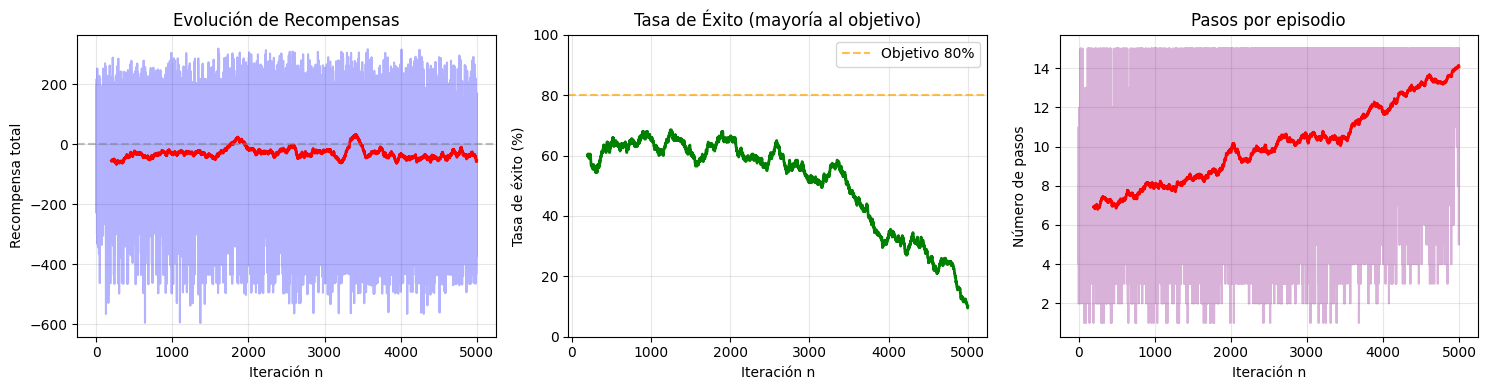


EVALUACIÓN DE LA POLÍTICA APRENDIDA
Usando ε=0 (solo explotación)
--------------------------------------------------------------------------------

RESULTADOS (100 pruebas):
  Tasa de éxito: 0.0% (0/100)
  Recompensa promedio: -131.48
  Pasos promedio: 24.79


In [24]:
import numpy as np
import random
from collections import defaultdict
import matplotlib.pyplot as plt

"""
================================================================================
ALGORITMO 3.4.1 - Q-LEARNING
================================================================================

Este código implementa paso a paso el algoritmo Q-learning para 3 agentes
con un estado simplificado basado en la suma de distancias entre agentes.

PASOS DEL ALGORITMO:
1. Inicializar Q0, N, n=0, y αn(x,a) con ∑αn = ∞ y ∑αn² < ∞
2. Seleccionar estado Xn = xn y acción Yn = an (ε-greedy)
3. Observar r(xn,an) y nuevo estado Xn+1 = s
4. Actualizar Qn+1 usando ecuación (3.4.1)
5. Si n+1 = N, ir al paso 6, sino n=n+1 y volver paso 2 con Xn=s
6. Obtener política óptima dN(x) = argmax_a QN(x,a)

================================================================================
"""

# ============================================================================
# CONFIGURACION INICIAL
# ============================================================================

# Espacio de coordenadas
X_MIN, X_MAX = 0, 5
Y_MIN, Y_MAX = 0, 5

# Centroides (puntos de interés)
centroides = {
    0: np.array([0.5, 0.5]),
    1: np.array([4.5, 0.5]),
    2: np.array([0.5, 4.5]),
    3: np.array([2.5, 2.5]),  # OBJETIVO
    4: np.array([4.5, 4.5])
}
centroide_objetivo = 3
centroide_objetivo_coords = centroides[centroide_objetivo]

# PARAMETROS DEL ESTADO SIMPLIFICADO
MAX_DISTANCIA = 15.0      # Máxima suma de distancias esperada
NUM_BUCKETS = 40          # Número de buckets/estados (0 a 20)
BUCKET_SIZE = MAX_DISTANCIA / NUM_BUCKETS  # Tamaño de cada bucket

# ============================================================================
# CLASE AGENTE
# ============================================================================

class Agente:
    """Agente con creencia sobre el centroide objetivo"""
    
    def __init__(self, id_agente, ruido_std):
        self.id = id_agente
        self.ruido_std = ruido_std
        self.reset()
    
    def reset(self):
        """Reinicia el agente para un nuevo episodio"""
        # Creencia inicial aleatoria alrededor del centroide objetivo
        self.creencia = centroide_objetivo_coords + np.random.randn(2) * 2.0
        self.creencia = np.clip(self.creencia, X_MIN, X_MAX)
        self.decision = None
        self.ha_decidido = False
    
    def observar(self):
        """Simula una observación con ruido"""
        ruido = np.random.randn(2) * self.ruido_std
        observacion = centroide_objetivo_coords + ruido
        return np.clip(observacion, X_MIN, X_MAX)
    
    def actualizar_por_observacion(self, observacion, alpha=0.3):
        """Actualiza creencia hacia la observación"""
        self.creencia = (1 - alpha) * self.creencia + alpha * observacion
        self.creencia = np.clip(self.creencia, X_MIN, X_MAX)
    
    def consultar(self, otras_creencias):
        """Promedia creencia con otros agentes"""
        if otras_creencias:
            todas = [self.creencia] + otras_creencias
            self.creencia = np.mean(todas, axis=0)
            self.creencia = np.clip(self.creencia, X_MIN, X_MAX)
    
    def decidir(self):
        """Decide el centroide más cercano a su creencia"""
        distancias = {idx: np.linalg.norm(self.creencia - c) 
                     for idx, c in centroides.items()}
        self.decision = min(distancias, key=distancias.get)
        self.ha_decidido = True
        return self.decision

# ============================================================================
# FUNCION DE ESTADO SIMPLIFICADO
# ============================================================================

def obtener_estado_simplificado(env, max_distancia=MAX_DISTANCIA, num_buckets=NUM_BUCKETS):
    """
    Convierte las posiciones de los 3 agentes en un estado discreto.
    
    f(x1,y1,x2,y2,x3,y3) = sum_{i<j} ||(xi,yi)-(xj,yj)||
    
    PARAMETROS:
    - env: entorno con los agentes
    - max_distancia: valor máximo de la suma de distancias
    - num_buckets: número de buckets (estados posibles)
    
    RETORNA:
    - estado: entero entre 0 y num_buckets-1
    - suma_distancias: valor real (para información)
    """
    # Obtener posiciones
    posiciones = []
    for agente in env.agentes:
        posiciones.append(agente.creencia.copy())
    
    # Calcular suma de distancias entre pares
    suma_distancias = 0
    for i in range(3):
        for j in range(i+1, 3):
            distancia = np.linalg.norm(posiciones[i] - posiciones[j])
            suma_distancias += distancia
    
    # Discretizar
    bucket_size = max_distancia / num_buckets
    estado = int(suma_distancias / bucket_size)
    
    # Asegurar que está en rango
    if estado >= num_buckets:
        estado = num_buckets - 1
    
    return estado, suma_distancias

# ============================================================================
# ENTORNO PARA 3 AGENTES
# ============================================================================

class Entorno:
    """Entorno con 3 agentes"""
    
    def __init__(self, max_pasos=25):
        self.max_pasos = max_pasos
        self.paso_actual = 0
        
        # 3 agentes con diferente precisión
        ruidos = [0.5, 1.0, 0.8]
        self.agentes = [Agente(i, ruidos[i]) for i in range(3)]
        
        # Costos de acciones
        self.costos = {
            'esperar': -1.2,
            'observar': -1.0,
            'consultar': -0.5,
            'decidir': 0.0
        }
    
    def _calcular_recompensa(self, acciones):
        """Calcula la recompensa según las acciones tomadas"""
        
        # Costo individual
        costo_total = sum(self.costos[acc] for acc in acciones)
        
        # Recompensa por acuerdos parciales
        decisiones = [a.decision for a in self.agentes if a.ha_decidido]
        delta_acuerdo = 0
        
        if len(decisiones) >= 2:
            if decisiones.count(centroide_objetivo) >= 2:
                delta_acuerdo = 15
            else:
                delta_acuerdo = -30
        
        # Recompensa final del episodio
        delta_final = 0
        todos_decidieron = all(a.ha_decidido for a in self.agentes)
        
        if todos_decidieron:
            decisions = [a.decision for a in self.agentes]
            if decisions.count(centroide_objetivo) == 3:
                delta_final = 150  # Éxito total
            elif decisions.count(centroide_objetivo) >= 2:
                delta_final = 50   # Éxito por mayoría
            elif len(set(decisions)) == 1:
                delta_final = 30   # Acuerdo pero no objetivo
            else:
                delta_final = -100  # Desacuerdo
        
        return costo_total + delta_acuerdo + delta_final
    
    def step(self, acciones):
        """Ejecuta un paso (PASO 3 del algoritmo)"""
        self.paso_actual += 1
        
        # Ejecutar acciones
        for i, accion in enumerate(acciones):
            agente = self.agentes[i]
            
            if accion == 'observar' and not agente.ha_decidido:
                obs = agente.observar()
                agente.actualizar_por_observacion(obs)
            elif accion == 'consultar' and not agente.ha_decidido:
                otras = [a.creencia for j, a in enumerate(self.agentes) 
                        if j != i and not a.ha_decidido]
                if otras:
                    agente.consultar(otras)
            elif accion == 'decidir' and not agente.ha_decidido:
                agente.decidir()
        
        # Calcular recompensa
        recompensa = self._calcular_recompensa(acciones)
        
        # Verificar si terminó
        terminado = all(a.ha_decidido for a in self.agentes) or self.paso_actual >= self.max_pasos
        
        return recompensa, terminado
    
    def reset(self):
        """Reinicia el entorno"""
        self.paso_actual = 0
        for agente in self.agentes:
            agente.reset()

# ============================================================================
# ACCIONES POSIBLES
# ============================================================================

ACCIONES = ['esperar', 'observar', 'consultar', 'decidir']

# Todas las combinaciones para 3 agentes
TODAS_ACCIONES = []
for a1 in ACCIONES:
    for a2 in ACCIONES:
        for a3 in ACCIONES:
            TODAS_ACCIONES.append((a1, a2, a3))

def acciones_validas(env):
    """Filtra acciones según qué agentes ya decidieron"""
    decididos = [a.ha_decidido for a in env.agentes]
    validas = []
    for accion in TODAS_ACCIONES:
        valida = True
        for i in range(3):
            if decididos[i] and accion[i] != 'esperar':
                valida = False
                break
        if valida:
            validas.append(accion)
    return validas

# ============================================================================
# ALGORITMO 3.4.1 - Q-LEARNING
# ============================================================================

class QLearning:
    """
    Implementación del Algoritmo 3.4.1
    """
    
    def __init__(self, gamma=0.95, alpha_inicial=0.5):
        """
        Inicialización (PASO 1 del algoritmo)
        
        Q0 ∈ Q: Tabla Q inicializada en 0
        N: Número de iteraciones (se define en entrenar)
        n = 0: Contador de iteraciones
        αn: Tasa de aprendizaje que cumple ∑αn = ∞ y ∑αn² < ∞
        """
        self.gamma = gamma              # Factor de descuento
        self.alpha_inicial = alpha_inicial  # α inicial
        self.Q = defaultdict(float)     # Q0 = 0 para todo (x,a)
        self.visitas = defaultdict(int) # Contador de visitas para αn(x,a)
        self.n = 0                      # Contador de iteraciones
    
    def get_num_estados(self):
        """Retorna el número de estados posibles según la discretización"""
        return NUM_BUCKETS
    
    def alpha_n(self, estado, accion):
        """
        αn(x,a) = 1 / (1 + visitas(x,a))
        
        Esta función cumple:
        ∑αn = ∞ (porque es serie armónica)
        ∑αn² < ∞ (porque ∑1/n² converge)
        """
        v = self.visitas[(estado, accion)]
        return 1.0 / (1.0 + v)
    
    def seleccionar_accion(self, env, epsilon):
        """
        PASO 2: Seleccionar Yn = an ∈ A(xn)
        
        Usamos política ε-greedy:
        - Con probabilidad ε: acción aleatoria (exploración)
        - Con probabilidad 1-ε: argmax_a Q(xn, a) (explotación)
        """
        # Obtener estado actual Xn = xn
        estado, _ = obtener_estado_simplificado(env)
        
        # Obtener acciones válidas A(xn)
        acciones = acciones_validas(env)
        
        if not acciones:
            return ('esperar', 'esperar', 'esperar')
        
        # Decisión ε-greedy
        if random.random() < epsilon:
            # Exploración: acción aleatoria
            return random.choice(acciones)
        else:
            # Explotación: argmax_a Q(xn, a)
            valores = [self.Q[(estado, a)] for a in acciones]
            max_valor = max(valores)
            mejores = [a for a, v in zip(acciones, valores) if v == max_valor]
            return random.choice(mejores)
    
    def actualizar(self, estado_anterior, accion, recompensa, nuevo_estado, es_terminal):
        """
        PASO 4: Actualizar Qn+1 usando ecuación (3.4.1)
        
        Qn+1(x,a) = {
            (1-αn)Qn(x,a) + αn(r + γ·Wn(s))  si (x,a) = (xn,an)
            Qn(x,a)                           si (x,a) ≠ (xn,an)
        }
        
        donde Wn(s) = max_{a'} Qn(s, a')
        """
        
        # Calcular αn(xn, an)
        alpha = self.alpha_n(estado_anterior, accion)
        
        # Calcular Wn(s) = max_{a'} Qn(s, a')
        if es_terminal:
            # Si es terminal, no hay futuro
            objetivo = recompensa
        else:
            # Obtener acciones válidas para el nuevo estado
            acciones_futuro = TODAS_ACCIONES
            
            # Calcular max_{a'} Qn(s, a')
            valores_futuro = [self.Q[(nuevo_estado, a)] for a in acciones_futuro]
            max_futuro = max(valores_futuro) if valores_futuro else 0
            
            # Target de Bellman: r + γ·Wn(s)
            objetivo = recompensa + self.gamma * max_futuro
        
        # Obtener Qn(xn, an) actual
        clave = (estado_anterior, accion)
        q_actual = self.Q[clave]
        
        # Ecuación (3.4.1): Qn+1 = (1-αn)Qn + αn(objetivo)
        q_nuevo = (1 - alpha) * q_actual + alpha * objetivo
        
        # Actualizar solo (xn, an), los demás pares quedan igual
        self.Q[clave] = q_nuevo
        
        # Incrementar contador de visitas para este par
        self.visitas[clave] += 1
    
    def obtener_politica_optima(self):
        """
        PASO 6: Obtener dN(x) = argmax_a QN(x,a)
        
        Esta es la política final después del entrenamiento
        """
        politica = {}
        
        # Número de estados según la discretización
        num_estados = self.get_num_estados()
        
        for estado in range(num_estados):
            mejor_valor = -float('inf')
            mejor_accion = None
            
            for accion in TODAS_ACCIONES:
                valor = self.Q[(estado, accion)]
                if valor > mejor_valor:
                    mejor_valor = valor
                    mejor_accion = accion
            
            politica[estado] = (mejor_accion, mejor_valor)
        
        return politica

# ============================================================================
# ENTRENAMIENTO (PASOS 2-5 DEL ALGORITMO)
# ============================================================================

def entrenar_qlearning(episodios=10000, max_pasos=15, epsilon_inicial=0.9, epsilon_final=0.05):
    """
    Ejecuta el Algoritmo 3.4.1 completo
    
    PARÁMETROS:
    - episodios: Número de iteraciones (N)
    - max_pasos: Máximo de pasos por episodio
    - epsilon_inicial: Tasa de exploración inicial
    - epsilon_final: Tasa de exploración final
    """
    
    # PASO 1: Inicialización
    ql = QLearning(gamma=0.95, alpha_inicial=0.5)
    estadisticas = {
        'recompensas': [],
        'exitos': [],
        'pasos': [],
        'epsilon': []
    }
    
    print("=" * 80)
    print("ALGORITMO 3.4.1 - Q-LEARNING")
    print("=" * 80)
    print("\nPASO 1: Inicialización")
    print(f"  - Q0(x,a) = 0 para todo (x,a)")
    print(f"  - N = {episodios} iteraciones")
    print(f"  - αn(x,a) = 1/(1+visitas) → cumple ∑αn=∞ y ∑αn²<∞")
    print(f"  - γ = {ql.gamma}")
    print(f"  - ε inicial = {epsilon_inicial}")
    print(f"  - ε final = {epsilon_final}")
    print()
    print("ESTADO SIMPLIFICADO:")
    print(f"  - f(x1,y1,x2,y2,x3,y3) = sum_{{i<j}} distancia entre agentes")
    print(f"  - max_distancia = {MAX_DISTANCIA}")
    print(f"  - num_buckets = {NUM_BUCKETS}")
    print(f"  - bucket_size = {BUCKET_SIZE:.3f}")
    print(f"  - Total estados posibles: {NUM_BUCKETS} (0 a {NUM_BUCKETS-1})")
    print(f"  - Total acciones posibles: {len(TODAS_ACCIONES)}")
    print("-" * 80)
    
    # Bucle principal de entrenamiento
    for n in range(episodios):
        
        # Reiniciar entorno para nuevo episodio
        env = Entorno(max_pasos=max_pasos)
        
        # PASO 2: Seleccionar estado inicial X0 = x0
        estado_actual, _ = obtener_estado_simplificado(env)
        
        # Calcular epsilon (decreciente)
        epsilon = epsilon_inicial - (epsilon_inicial - epsilon_final) * (n / episodios)
        
        terminado = False
        recompensa_total = 0
        pasos = 0
        
        # ================================================================
        # BUCLE POR PASOS DEL EPISODIO (PASOS 2-5)
        # ================================================================
        
        while not terminado:
            
            # PASO 2: Seleccionar acción Yn = an
            accion = ql.seleccionar_accion(env, epsilon)
            
            # PASO 3: Observar r(xn,an) y nuevo estado Xn+1 = s
            recompensa, terminado = env.step(accion)
            nuevo_estado, _ = obtener_estado_simplificado(env)
            
            recompensa_total += recompensa
            pasos += 1
            
            # PASO 4: Actualizar Qn+1 usando ecuación (3.4.1)
            ql.actualizar(estado_actual, accion, recompensa, nuevo_estado, terminado)
            
            # PASO 5: Incrementar n (implícito) y regresar al paso 2 con Xn = s
            estado_actual = nuevo_estado
        
        # ================================================================
        # FIN DEL EPISODIO
        # ================================================================
        
        # Determinar si fue éxito
        decisiones = [a.decision for a in env.agentes if a.ha_decidido]
        exito = False
        if len(decisiones) == 3:
            exito = decisiones.count(centroide_objetivo) >= 2
        
        # Guardar estadísticas
        estadisticas['recompensas'].append(recompensa_total)
        estadisticas['exitos'].append(exito)
        estadisticas['pasos'].append(pasos)
        estadisticas['epsilon'].append(epsilon)
        
        # Mostrar progreso cada 500 episodios
        if (n + 1) % 500 == 0:
            avg_reward = np.mean(estadisticas['recompensas'][-500:])
            avg_success = np.mean(estadisticas['exitos'][-500:]) * 100
            avg_steps = np.mean(estadisticas['pasos'][-500:])
            print(f"n={n+1:5d}/{episodios}: R={avg_reward:6.1f}, "
                  f"Éxito={avg_success:5.1f}%, Pasos={avg_steps:4.1f}, ε={epsilon:.3f}")
    
    print("-" * 80)
    print("ENTRENAMIENTO COMPLETADO")
    print(f"Tasa de éxito últimos 500 episodios: {np.mean(estadisticas['exitos'][-500:])*100:.1f}%")
    print("=" * 80)
    
    return ql, estadisticas

# ============================================================================
# PASO 6: OBTENER POLÍTICA ÓPTIMA
# ============================================================================

def imprimir_politica_optima(ql):
    """
    PASO 6: dN(x) = argmax_a QN(x,a)
    
    Imprime TODOS los estados posibles según la discretización
    """
    politica = ql.obtener_politica_optima()
    num_estados = ql.get_num_estados()
    
    print("\n" + "=" * 100)
    print(f"PASO 6: POLÍTICA ÓPTIMA dN(x) = argmax_a QN(x,a)")
    print("=" * 100)
    print(f"\nTotal de estados posibles: {num_estados} (0 a {num_estados-1})")
    print(f"Discretización: {BUCKET_SIZE:.3f} unidades por bucket")
    print(f"Bucket size = max_distancia / num_buckets = {MAX_DISTANCIA} / {NUM_BUCKETS} = {BUCKET_SIZE:.3f}")
    print()
    print(f"{'Estado':<8} | {'Rango suma distancias':<25} | {'Mejor accion (a1,a2,a3)':<45} | {'Valor Q':<10}")
    print("-" * 100)
    
    # Imprimir TODOS los estados
    for estado in range(num_estados):
        rango_min = estado * BUCKET_SIZE
        rango_max = (estado + 1) * BUCKET_SIZE
        accion, valor = politica[estado]
        
        if accion is not None:
            # Formatear el rango
            if estado == num_estados - 1:
                rango_str = f"[{rango_min:.2f}, {MAX_DISTANCIA:.2f}]"
            else:
                rango_str = f"[{rango_min:.2f}, {rango_max:.2f})"
            
            # Formatear acción
            accion_str = str(accion)
            
            print(f"  {estado:3d}     | {rango_str:<25} | {accion_str:<45} | {valor:8.2f}")
    
    print("-" * 100)
    
    # Resumen de acciones más frecuentes
    from collections import Counter
    conteo = Counter()
    for estado in range(num_estados):
        accion, _ = politica[estado]
        if accion:
            conteo[accion] += 1
    
    print("\nRESUMEN DE LA POLÍTICA ÓPTIMA:")
    print(f"  Total estados analizados: {num_estados}")
    for accion, count in conteo.most_common(10):
        print(f"  {accion}: {count} estados ({count/num_estados*100:.1f}%)")
    
    print("=" * 100)

# ============================================================================
# EVALUACIÓN DE LA POLÍTICA APRENDIDA
# ============================================================================

def evaluar_politica(ql, n_pruebas=100):
    """
    Evalúa la política aprendida (sin exploración)
    """
    print("\n" + "=" * 80)
    print("EVALUACIÓN DE LA POLÍTICA APRENDIDA")
    print("=" * 80)
    print("Usando ε=0 (solo explotación)")
    print("-" * 80)
    
    exitos = 0
    recompensas = []
    pasos_lista = []
    
    for i in range(n_pruebas):
        env = Entorno(max_pasos=25)
        terminado = False
        recompensa_total = 0
        pasos = 0
        
        while not terminado:
            # Usar ε=0 para solo explotación
            estado, _ = obtener_estado_simplificado(env)
            acciones = acciones_validas(env)
            
            if not acciones:
                break
            
            # Solo explotación: argmax_a Q(x,a)
            valores = [ql.Q[(estado, a)] for a in acciones]
            max_valor = max(valores)
            mejores = [a for a, v in zip(acciones, valores) if v == max_valor]
            accion = random.choice(mejores)
            
            recompensa, terminado = env.step(accion)
            recompensa_total += recompensa
            pasos += 1
        
        decisiones = [a.decision for a in env.agentes if a.ha_decidido]
        if len(decisiones) == 3 and decisiones.count(centroide_objetivo) >= 2:
            exitos += 1
        
        recompensas.append(recompensa_total)
        pasos_lista.append(pasos)
    
    print(f"\nRESULTADOS ({n_pruebas} pruebas):")
    print(f"  Tasa de éxito: {exitos/n_pruebas*100:.1f}% ({exitos}/{n_pruebas})")
    print(f"  Recompensa promedio: {np.mean(recompensas):.2f}")
    print(f"  Pasos promedio: {np.mean(pasos_lista):.2f}")
    print("=" * 80)
    
    return exitos / n_pruebas

# ============================================================================
# VISUALIZACIÓN
# ============================================================================

def graficar_resultados(estadisticas):
    """Grafica las curvas de aprendizaje"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    window = 200
    
    # 1. Recompensas
    axes[0].plot(estadisticas['recompensas'], alpha=0.3, color='blue')
    if len(estadisticas['recompensas']) >= window:
        ma = np.convolve(estadisticas['recompensas'], np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(estadisticas['recompensas'])), ma, 'r-', linewidth=2)
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Iteración n')
    axes[0].set_ylabel('Recompensa total')
    axes[0].set_title('Evolución de Recompensas')
    axes[0].grid(True, alpha=0.3)
    
    # 2. Tasa de éxito
    success_rates = []
    for i in range(len(estadisticas['exitos']) - window + 1):
        success_rates.append(np.mean(estadisticas['exitos'][i:i+window]) * 100)
    axes[1].plot(range(window-1, len(estadisticas['exitos'])), success_rates, 'g-', linewidth=2)
    axes[1].axhline(y=80, color='orange', linestyle='--', alpha=0.7, label='Objetivo 80%')
    axes[1].set_xlabel('Iteración n')
    axes[1].set_ylabel('Tasa de éxito (%)')
    axes[1].set_title('Tasa de Éxito (mayoría al objetivo)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 100)
    
    # 3. Pasos por episodio
    axes[2].plot(estadisticas['pasos'], alpha=0.3, color='purple')
    if len(estadisticas['pasos']) >= window:
        ma_pasos = np.convolve(estadisticas['pasos'], np.ones(window)/window, mode='valid')
        axes[2].plot(range(window-1, len(estadisticas['pasos'])), ma_pasos, 'r-', linewidth=2)
    axes[2].set_xlabel('Iteración n')
    axes[2].set_ylabel('Número de pasos')
    axes[2].set_title('Pasos por episodio')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# EJECUCIÓN PRINCIPAL
# ============================================================================

if __name__ == "__main__":
    
    # EJECUTAR ALGORITMO 3.4.1 (PASOS 1-5)
    ql, estadisticas = entrenar_qlearning(episodios=5000, max_pasos=15)
    
    # PASO 6: Obtener y mostrar política óptima (TODOS los estados)
    imprimir_politica_optima(ql)
    
    # Visualizar resultados
    graficar_resultados(estadisticas)
    
    # Evaluar política aprendida
    evaluar_politica(ql, n_pruebas=100)

ALGORITMO 3.4.1 - Q-LEARNING

PASO 1: Inicializacion
  Q0(x,a) = 0 para todo (x,a)
  N = 10000
  n = 0
  αn(x,a) = 1/(1+visitas) → cumple ∑αn=∞ y ∑αn²<∞
  γ = 0.95
  Estados posibles (X): 40 (0 a 39)
  Acciones por agente: ['esperar', 'observar', 'consultar', 'decidir']
  Total acciones combinadas: 64
--------------------------------------------------------------------------------
n=  500/10000: R= 209.8, Exito= 95.0%, Pasos= 7.2, ε=0.858
n= 1000/10000: R= 209.6, Exito= 94.0%, Pasos= 6.8, ε=0.815
n= 1500/10000: R= 211.1, Exito= 93.0%, Pasos= 6.9, ε=0.773
n= 2000/10000: R= 218.0, Exito= 92.8%, Pasos= 7.4, ε=0.730
n= 2500/10000: R= 219.4, Exito= 91.2%, Pasos= 7.4, ε=0.688
n= 3000/10000: R= 215.7, Exito= 89.0%, Pasos= 7.2, ε=0.645
n= 3500/10000: R= 222.6, Exito= 87.8%, Pasos= 7.7, ε=0.603
n= 4000/10000: R= 226.8, Exito= 86.8%, Pasos= 8.0, ε=0.560
n= 4500/10000: R= 224.6, Exito= 84.2%, Pasos= 7.9, ε=0.518
n= 5000/10000: R= 225.6, Exito= 83.6%, Pasos= 8.0, ε=0.475
n= 5500/10000: R= 231.6, E

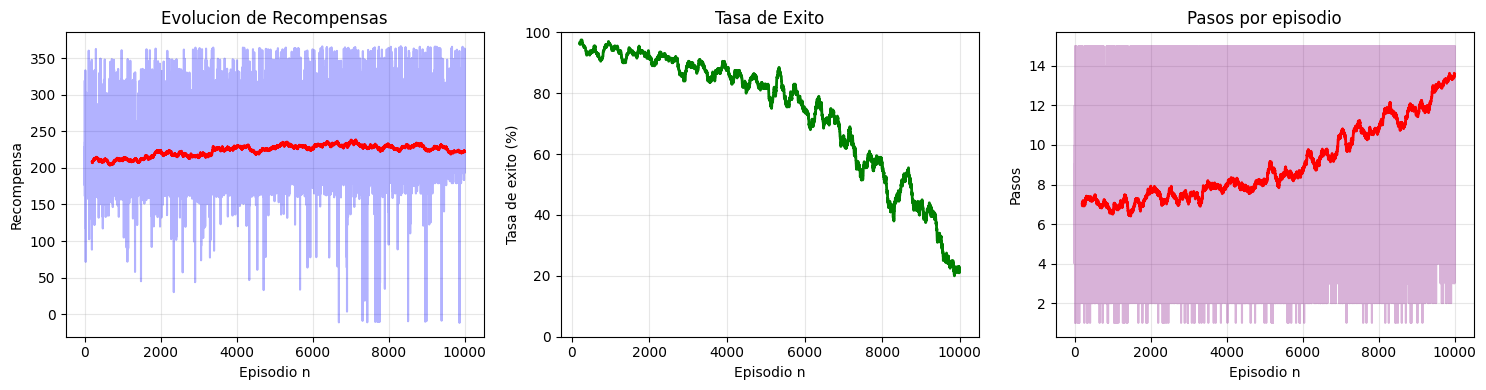


EVALUACION DE LA POLITICA APRENDIDA

Resultados sobre 100 pruebas:
  Tasa de exito: 0.0% (0/100)
  Recompensa promedio: 357.01
  Pasos promedio: 25.00


In [25]:
import numpy as np
import random
from collections import defaultdict
import matplotlib.pyplot as plt

"""
================================================================================
ALGORITMO 3.4.1 (Q-LEARNING) - IMPLEMENTACION EXACTA
================================================================================

PASOS DEL ALGORITMO:

PASO 1: Fijamos Q0 ∈ Q; N > 0; n = 0; y (αn) una sucesion que cumple con
        ∑_n αn(x,a) = ∞, ∑_n αn^2(x,a) < ∞, ∀(x,a) ∈ K.

PASO 2: Seleccionamos un estado Xn = xn ∈ X de manera arbitraria. Despues escogemos
        Yn = an ∈ A(xn) siguiendo algun procedimiento.

PASO 3: Observamos los resultados de realizar la accion an en el sistema.
        Es decir, obtenemos r(xn, an) y el nuevo estado del sistema Xn+1 = s.

PASO 4: Para todo (x, a) ∈ K, calculamos Qn+1(x, a) como:
        
        Qn+1(x,a) = { (1-αn(x,a))Qn(x,a) + αn(x,a)(r(x,a) + γ·Wn(s))  si (x,a)=(xn,an)
                    { Qn(x,a)                                           si (x,a)≠(xn,an)
        
        siendo Wn(x) := max_{a'∈A(x)} Qn(x, a')

PASO 5: Si n+1 = N, ir al paso 6. En caso contrario incrementar n en una unidad y
        regresar al paso 2 con Xn = s.

PASO 6: Para cada x ∈ X, escogemos dN(x) = argmax_{a∈A(x)} Qn+1(x, a)

================================================================================
"""

# ============================================================================
# CONFIGURACION INICIAL
# ============================================================================

# Parametros del estado simplificado
MAX_SUMA_DISTANCIAS = 15.0   # Valor maximo esperado para la suma de distancias
NUM_ESTADOS = 40              # Cantidad de estados discretos (0, 1, 2, ..., 20)
BUCKET_SIZE = MAX_SUMA_DISTANCIAS / NUM_ESTADOS

# Centroides (para los agentes originales)
centroides = {
    0: np.array([0.5, 0.5]),
    1: np.array([4.5, 0.5]),
    2: np.array([0.5, 4.5]),
    3: np.array([2.5, 2.5]),  # OBJETIVO
    4: np.array([4.5, 4.5])
}
CENTROIDE_OBJETIVO = 3

# ============================================================================
# CLASE AGENTE (MODELO ORIGINAL)
# ============================================================================

class AgenteOriginal:
    """Agente con creencia sobre el centroide objetivo (sin cambios)"""
    
    def __init__(self, id_agente, ruido_std):
        self.id = id_agente
        self.ruido_std = ruido_std
        self.reset()
    
    def reset(self):
        self.creencia = np.array([2.5, 2.5])  # Creencia inicial en el centro
        self.decision = None
        self.ha_decidido = False
    
    def observar(self):
        ruido = np.random.randn(2) * self.ruido_std
        observacion = centroides[CENTROIDE_OBJETIVO] + ruido
        return observacion
    
    def actualizar_por_observacion(self, observacion, alpha=0.3):
        self.creencia = (1 - alpha) * self.creencia + alpha * observacion
    
    def consultar(self, otras_creencias):
        if otras_creencias:
            todas = [self.creencia] + otras_creencias
            self.creencia = np.mean(todas, axis=0)
    
    def decidir(self):
        distancias = {idx: np.linalg.norm(self.creencia - c) 
                     for idx, c in centroides.items()}
        self.decision = min(distancias, key=distancias.get)
        self.ha_decidido = True
        return self.decision

# ============================================================================
# FUNCION DE ESTADO SIMPLIFICADO Xn
# ============================================================================

def estado_simplificado(env):
    """
    Calcula Xn = estado discreto a partir de las posiciones de los 3 agentes.
    
    f(x1,y1,x2,y2,x3,y3) = sum_{i<j} ||(xi,yi)-(xj,yj)||
    """
    # Obtener posiciones
    posiciones = [agente.creencia for agente in env.agentes]
    
    # Suma de distancias entre pares
    suma = 0
    for i in range(3):
        for j in range(i+1, 3):
            suma += np.linalg.norm(posiciones[i] - posiciones[j])
    
    # Discretizar a estado Xn
    xn = int(suma / BUCKET_SIZE)
    if xn >= NUM_ESTADOS:
        xn = NUM_ESTADOS - 1
    
    return xn

# ============================================================================
# ENTORNO
# ============================================================================

class Entorno:
    """Entorno con 3 agentes"""
    
    def __init__(self, max_pasos=25):
        self.max_pasos = max_pasos
        self.paso_actual = 0
        ruidos = [0.5, 1.0, 0.8]
        self.agentes = [AgenteOriginal(i, ruidos[i]) for i in range(3)]
        
        self.costos = {
            'esperar': -0.2,
            'observar': -1.0,
            'consultar': -0.5,
            'decidir': 0.0
        }
    
    def r(self, acciones):
        """
        Funcion de recompensa r(xn, an)
        """
        # Costo individual
        costo_total = sum(self.costos[acc] for acc in acciones)
        
        # Recompensa por acuerdos
        decisiones = [a.decision for a in self.agentes if a.ha_decidido]
        delta_acuerdo = 0
        if len(decisiones) >= 2:
            if decisiones.count(CENTROIDE_OBJETIVO) >= 2:
                delta_acuerdo = 15
            else:
                delta_acuerdo = -30
        
        # Recompensa final
        delta_final = 0
        if all(a.ha_decidido for a in self.agentes):
            decisions = [a.decision for a in self.agentes]
            if decisions.count(CENTROIDE_OBJETIVO) == 3:
                delta_final = 150
            elif decisions.count(CENTROIDE_OBJETIVO) >= 2:
                delta_final = 50
            elif len(set(decisions)) == 1:
                delta_final = 30
            else:
                delta_final = -100
        
        return costo_total + delta_acuerdo + delta_final
    
    def step(self, acciones):
        """
        PASO 3: Observamos r(xn,an) y Xn+1 = s
        """
        self.paso_actual += 1
        
        # Ejecutar acciones
        for i, accion in enumerate(acciones):
            agente = self.agentes[i]
            
            if accion == 'observar' and not agente.ha_decidido:
                obs = agente.observar()
                agente.actualizar_por_observacion(obs)
            elif accion == 'consultar' and not agente.ha_decidido:
                otras = [a.creencia for j, a in enumerate(self.agentes) 
                        if j != i and not a.ha_decidido]
                if otras:
                    agente.consultar(otras)
            elif accion == 'decidir' and not agente.ha_decidido:
                agente.decidir()
        
        # Obtener r(xn, an)
        recompensa = self.r(acciones)
        
        # Obtener nuevo estado Xn+1 = s
        nuevo_estado = estado_simplificado(self)
        
        # Verificar si es terminal
        terminal = all(a.ha_decidido for a in self.agentes) or self.paso_actual >= self.max_pasos
        
        return recompensa, nuevo_estado, terminal
    
    def reset(self):
        self.paso_actual = 0
        for agente in self.agentes:
            agente.reset()

# ============================================================================
# CONJUNTO DE ACCIONES K = X × A(x)
# ============================================================================

ACCIONES_POR_AGENTE = ['esperar', 'observar', 'consultar', 'decidir']

# Todas las combinaciones para 3 agentes
TODAS_ACCIONES = []
for a1 in ACCIONES_POR_AGENTE:
    for a2 in ACCIONES_POR_AGENTE:
        for a3 in ACCIONES_POR_AGENTE:
            TODAS_ACCIONES.append((a1, a2, a3))

def A(xn, env):
    """
    A(xn) = Acciones validas en el estado xn
    Si un agente ya decidio, solo puede 'esperar'
    """
    decididos = [a.ha_decidido for a in env.agentes]
    validas = []
    for accion in TODAS_ACCIONES:
        valida = True
        for i in range(3):
            if decididos[i] and accion[i] != 'esperar':
                valida = False
                break
        if valida:
            validas.append(accion)
    return validas

# ============================================================================
# ALGORITMO 3.4.1 - Q-LEARNING
# ============================================================================

class QLearning341:
    """
    Implementacion exacta del Algoritmo 3.4.1
    """
    
    def __init__(self, gamma=0.95):
        """
        PASO 1: Fijamos Q0 ∈ Q; N > 0; n = 0; y (αn)
        """
        self.gamma = gamma
        self.Q = defaultdict(float)      # Q0 = 0 para todo (x,a)
        self.visitas = defaultdict(int)  # Para calcular αn(x,a)
        self.n = 0                       # Contador de iteraciones
    
    def alpha_n(self, x, a):
        """
        αn(x,a) = 1 / (1 + visitas(x,a))
        
        Cumple: ∑_n αn = ∞ (serie armonica) y ∑_n αn^2 < ∞
        """
        return 1.0 / (1.0 + self.visitas[(x, a)])
    
    def Wn(self, s):
        """
        Wn(s) = max_{a'∈A(s)} Qn(s, a')
        """
        # Para calcular el maximo sobre todas las acciones posibles
        # En la practica, se puede calcular sobre TODAS_ACCIONES
        max_valor = -float('inf')
        for a in TODAS_ACCIONES:
            valor = self.Q[(s, a)]
            if valor > max_valor:
                max_valor = valor
        return max_valor
    
    def argmax_a(self, xn, env):
        """
        Encuentra argmax_{a∈A(xn)} Qn(xn, a)
        """
        acciones = A(xn, env)
        if not acciones:
            return ('esperar', 'esperar', 'esperar')
        
        valores = [self.Q[(xn, a)] for a in acciones]
        max_valor = max(valores)
        mejores = [a for a, v in zip(acciones, valores) if v == max_valor]
        return random.choice(mejores)

# ============================================================================
# PROCEDIMIENTO DE SELECCION DE ACCION (ε-greedy)
# ============================================================================

def seleccionar_accion(ql, xn, env, epsilon):
    """
    Procedimiento para escoger Yn = an ∈ A(xn)
    
    Usamos ε-greedy:
    - Con probabilidad ε: an ∼ Uniforme(A(xn))
    - Con probabilidad 1-ε: an = argmax_a Qn(xn, a)
    """
    acciones = A(xn, env)
    
    if not acciones:
        return ('esperar', 'esperar', 'esperar')
    
    if random.random() < epsilon:
        # an ∼ Uniforme(A(xn))
        return random.choice(acciones)
    else:
        # an = argmax_a Qn(xn, a)
        return ql.argmax_a(xn, env)

# ============================================================================
# ENTRENAMIENTO - ALGORITMO 3.4.1
# ============================================================================

def algoritmo_341(episodios=5000, max_pasos=15):
    """
    Ejecuta el Algoritmo 3.4.1 paso a paso
    
    PARAMETROS:
    - episodios = N (numero de iteraciones)
    - max_pasos = maximo de pasos por episodio
    """
    
    # PASO 1: Inicializacion
    ql = QLearning341(gamma=0.95)
    N = episodios
    n = 0
    
    # Para estadisticas
    recompensas_por_episodio = []
    exitos_por_episodio = []
    pasos_por_episodio = []
    
    # Para epsilon (decreciente para exploracion al inicio)
    epsilon_inicial = 0.9
    epsilon_final = 0.05
    
    print("=" * 80)
    print("ALGORITMO 3.4.1 - Q-LEARNING")
    print("=" * 80)
    print("\nPASO 1: Inicializacion")
    print(f"  Q0(x,a) = 0 para todo (x,a)")
    print(f"  N = {N}")
    print(f"  n = 0")
    print(f"  αn(x,a) = 1/(1+visitas) → cumple ∑αn=∞ y ∑αn²<∞")
    print(f"  γ = {ql.gamma}")
    print(f"  Estados posibles (X): {NUM_ESTADOS} (0 a {NUM_ESTADOS-1})")
    print(f"  Acciones por agente: {ACCIONES_POR_AGENTE}")
    print(f"  Total acciones combinadas: {len(TODAS_ACCIONES)}")
    print("-" * 80)
    
    # Bucle principal
    for episodio in range(N):
        
        # Reiniciar entorno
        env = Entorno(max_pasos=max_pasos)
        
        # Calcular epsilon (decreciente)
        epsilon = epsilon_inicial - (epsilon_inicial - epsilon_final) * (episodio / N)
        
        # PASO 2: Seleccionamos Xn = xn ∈ X de manera arbitraria
        xn = estado_simplificado(env)
        
        terminal = False
        recompensa_total = 0
        pasos = 0
        
        while not terminal:
            
            # PASO 2 (continuacion): Escogemos Yn = an ∈ A(xn)
            an = seleccionar_accion(ql, xn, env, epsilon)
            
            # PASO 3: Observamos r(xn, an) y el nuevo estado Xn+1 = s
            r_xn_an, s, terminal = env.step(an)
            
            recompensa_total += r_xn_an
            pasos += 1
            
            # PASO 4: Calculamos Qn+1(x,a) usando ecuacion (3.4.1)
            # Primero calculamos αn(xn, an)
            alpha = ql.alpha_n(xn, an)
            
            # Calculamos Wn(s) = max_{a'∈A(s)} Qn(s, a')
            if terminal:
                # Si es terminal, no hay futuro
                objetivo = r_xn_an
            else:
                Wn_s = ql.Wn(s)
                objetivo = r_xn_an + ql.gamma * Wn_s
            
            # Actualizamos Qn+1(xn, an)
            q_actual = ql.Q[(xn, an)]
            q_nuevo = (1 - alpha) * q_actual + alpha * objetivo
            ql.Q[(xn, an)] = q_nuevo
            
            # Incrementamos visitas para este par
            ql.visitas[(xn, an)] += 1
            
            # Para los demas (x,a) ≠ (xn, an), Q no cambia (defaultdict ya los tiene)
            
            # PASO 5: Preparamos para siguiente iteracion
            xn = s  # Xn = s
            n += 1   # Incrementamos n implicitamente en el bucle
        
        # Determinar si fue exito
        decisiones = [a.decision for a in env.agentes if a.ha_decidido]
        exito = False
        if len(decisiones) == 3:
            exito = decisiones.count(CENTROIDE_OBJETIVO) >= 2
        
        recompensas_por_episodio.append(recompensa_total)
        exitos_por_episodio.append(exito)
        pasos_por_episodio.append(pasos)
        
        # Mostrar progreso
        if (episodio + 1) % 500 == 0:
            avg_reward = np.mean(recompensas_por_episodio[-500:])
            avg_success = np.mean(exitos_por_episodio[-500:]) * 100
            avg_steps = np.mean(pasos_por_episodio[-500:])
            print(f"n={episodio+1:5d}/{N}: R={avg_reward:6.1f}, "
                  f"Exito={avg_success:5.1f}%, Pasos={avg_steps:4.1f}, ε={epsilon:.3f}")
    
    print("-" * 80)
    print(f"ENTRENAMIENTO COMPLETADO")
    print(f"Tasa de exito ultimos 500 episodios: {np.mean(exitos_por_episodio[-500:])*100:.1f}%")
    print("=" * 80)
    
    return ql, recompensas_por_episodio, exitos_por_episodio, pasos_por_episodio

# ============================================================================
# PASO 6: OBTENER POLITICA OPTIMA dN(x)
# ============================================================================

def paso6_politica_optima(ql):
    """
    PASO 6: Para cada x ∈ X, escogemos dN(x) = argmax_{a∈A(x)} Qn+1(x, a)
    """
    print("\n" + "=" * 100)
    print("PASO 6: POLITICA OPTIMA dN(x) = argmax_{a∈A(x)} Qn+1(x, a)")
    print("=" * 100)
    print(f"\nTotal estados: {NUM_ESTADOS}")
    print(f"Bucket size: {BUCKET_SIZE:.3f}")
    print()
    print(f"{'x':<6} | {'Rango suma distancias':<22} | {'dN(x) = mejor accion':<45} | {'Q(x,a)':<10}")
    print("-" * 100)
    
    for x in range(NUM_ESTADOS):
        # Calcular rango de suma de distancias
        rango_min = x * BUCKET_SIZE
        rango_max = (x + 1) * BUCKET_SIZE
        if x == NUM_ESTADOS - 1:
            rango = f"[{rango_min:.2f}, {MAX_SUMA_DISTANCIAS:.2f}]"
        else:
            rango = f"[{rango_min:.2f}, {rango_max:.2f})"
        
        # Encontrar argmax_a Q(x, a)
        mejor_valor = -float('inf')
        mejor_accion = None
        
        for a in TODAS_ACCIONES:
            valor = ql.Q[(x, a)]
            if valor > mejor_valor:
                mejor_valor = valor
                mejor_accion = a
        
        if mejor_accion:
            print(f"  {x:<4} | {rango:<22} | {str(mejor_accion):<45} | {mejor_valor:8.2f}")
    
    print("-" * 100)
    
    # Resumen
    from collections import Counter
    conteo = Counter()
    for x in range(NUM_ESTADOS):
        mejor_valor = -float('inf')
        mejor_accion = None
        for a in TODAS_ACCIONES:
            valor = ql.Q[(x, a)]
            if valor > mejor_valor:
                mejor_valor = valor
                mejor_accion = a
        if mejor_accion:
            conteo[mejor_accion] += 1
    
    print("\nRESUMEN:")
    for accion, count in conteo.most_common():
        print(f"  {accion}: {count} estados ({count/NUM_ESTADOS*100:.1f}%)")
    
    print("=" * 100)

# ============================================================================
# EVALUACION
# ============================================================================

def evaluar_politica(ql, n_pruebas=100):
    """
    Evalua la politica aprendida (usando solo explotacion)
    """
    print("\n" + "=" * 80)
    print("EVALUACION DE LA POLITICA APRENDIDA")
    print("=" * 80)
    
    exitos = 0
    recompensas = []
    pasos_lista = []
    
    for _ in range(n_pruebas):
        env = Entorno(max_pasos=25)
        xn = estado_simplificado(env)
        terminal = False
        recompensa_total = 0
        pasos = 0
        
        while not terminal:
            # Solo explotacion: argmax_a Q(x,a)
            acciones = A(xn, env)
            if not acciones:
                break
            
            valores = [ql.Q[(xn, a)] for a in acciones]
            max_valor = max(valores)
            mejores = [a for a, v in zip(acciones, valores) if v == max_valor]
            an = random.choice(mejores)
            
            r_xn_an, s, terminal = env.step(an)
            recompensa_total += r_xn_an
            pasos += 1
            xn = s
        
        decisiones = [a.decision for a in env.agentes if a.ha_decidido]
        if len(decisiones) == 3 and decisiones.count(CENTROIDE_OBJETIVO) >= 2:
            exitos += 1
        
        recompensas.append(recompensa_total)
        pasos_lista.append(pasos)
    
    print(f"\nResultados sobre {n_pruebas} pruebas:")
    print(f"  Tasa de exito: {exitos/n_pruebas*100:.1f}% ({exitos}/{n_pruebas})")
    print(f"  Recompensa promedio: {np.mean(recompensas):.2f}")
    print(f"  Pasos promedio: {np.mean(pasos_lista):.2f}")
    print("=" * 80)

# ============================================================================
# GRAFICOS
# ============================================================================

def graficar_resultados(recompensas, exitos, pasos):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    window = 200
    
    axes[0].plot(recompensas, alpha=0.3, color='blue')
    if len(recompensas) >= window:
        ma = np.convolve(recompensas, np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(recompensas)), ma, 'r-', linewidth=2)
    axes[0].set_xlabel('Episodio n')
    axes[0].set_ylabel('Recompensa')
    axes[0].set_title('Evolucion de Recompensas')
    axes[0].grid(True, alpha=0.3)
    
    success_rates = []
    for i in range(len(exitos) - window + 1):
        success_rates.append(np.mean(exitos[i:i+window]) * 100)
    axes[1].plot(range(window-1, len(exitos)), success_rates, 'g-', linewidth=2)
    axes[1].set_xlabel('Episodio n')
    axes[1].set_ylabel('Tasa de exito (%)')
    axes[1].set_title('Tasa de Exito')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 100)
    
    axes[2].plot(pasos, alpha=0.3, color='purple')
    if len(pasos) >= window:
        ma_pasos = np.convolve(pasos, np.ones(window)/window, mode='valid')
        axes[2].plot(range(window-1, len(pasos)), ma_pasos, 'r-', linewidth=2)
    axes[2].set_xlabel('Episodio n')
    axes[2].set_ylabel('Pasos')
    axes[2].set_title('Pasos por episodio')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# EJECUCION
# ============================================================================

if __name__ == "__main__":
    # Ejecutar Algoritmo 3.4.1
    ql, rewards, successes, steps = algoritmo_341(episodios=10000, max_pasos=15)
    
    # PASO 6: Imprimir politica optima
    paso6_politica_optima(ql)
    
    # Graficar
    graficar_resultados(rewards, successes, steps)
    
    # Evaluar
    evaluar_politica(ql, n_pruebas=100)

ALGORITMO 3.4.1 - Q-LEARNING

PASO 1: Inicializacion
  Q0(x,a) = 0 para todo (x,a)
  N = 5000
  n = 0
  αn(x,a) = 1/(1+visitas) → cumple ∑αn=∞ y ∑αn²<∞
  γ = 0.95
  Estados posibles (X): 40 (0 a 39)
  Acciones por agente: ['esperar', 'observar', 'consultar', 'decidir']
  Total acciones combinadas: 64
--------------------------------------------------------------------------------
n=  500/5000: R= 220.5, Exito=100.0%, Pasos= 7.5, ε=0.865
n= 1000/5000: R= 223.5, Exito=100.0%, Pasos= 7.1, ε=0.780
n= 1500/5000: R= 233.4, Exito=100.0%, Pasos= 7.5, ε=0.695
n= 2000/5000: R= 249.6, Exito=100.0%, Pasos= 8.6, ε=0.610
n= 2500/5000: R= 257.4, Exito=100.0%, Pasos= 9.1, ε=0.525
n= 3000/5000: R= 270.3, Exito=100.0%, Pasos= 9.9, ε=0.440
n= 3500/5000: R= 316.5, Exito=100.0%, Pasos=13.2, ε=0.355
n= 4000/5000: R= 338.2, Exito=100.0%, Pasos=14.4, ε=0.270
n= 4500/5000: R= 387.7, Exito=100.0%, Pasos=17.9, ε=0.185
n= 5000/5000: R= 552.0, Exito=100.0%, Pasos=29.3, ε=0.100
-------------------------------------

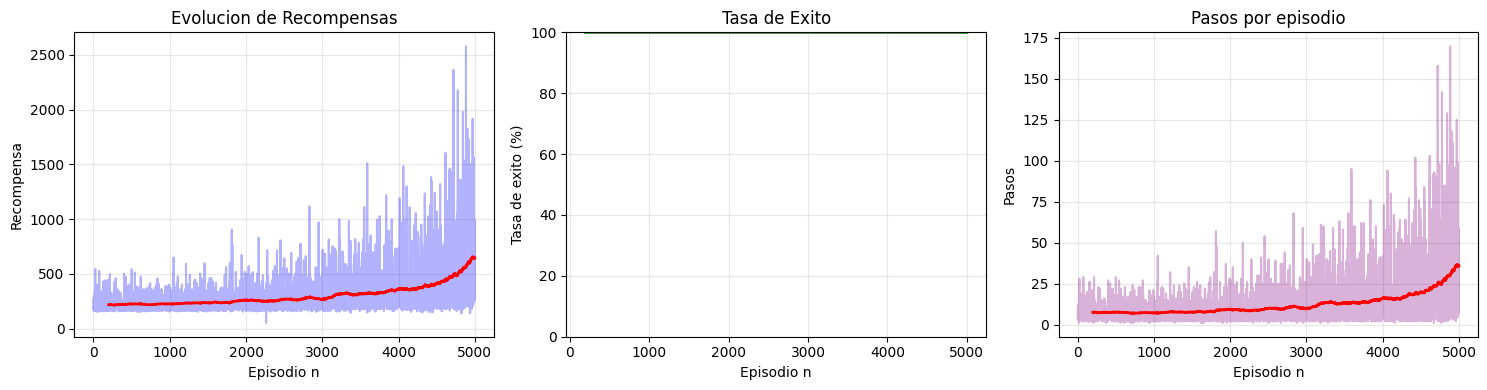


EVALUACION DE LA POLITICA APRENDIDA


KeyboardInterrupt: 

In [27]:
import numpy as np
import random
from collections import defaultdict
import matplotlib.pyplot as plt

"""
================================================================================
ALGORITMO 3.4.1 (Q-LEARNING) - IMPLEMENTACION EXACTA
================================================================================

PASOS DEL ALGORITMO:

PASO 1: Fijamos Q0 ∈ Q; N > 0; n = 0; y (αn) una sucesion que cumple con
        ∑_n αn(x,a) = ∞, ∑_n αn^2(x,a) < ∞, ∀(x,a) ∈ K.

PASO 2: Seleccionamos un estado Xn = xn ∈ X de manera arbitraria. Despues escogemos
        Yn = an ∈ A(xn) siguiendo algun procedimiento.

PASO 3: Observamos los resultados de realizar la accion an en el sistema.
        Es decir, obtenemos r(xn, an) y el nuevo estado del sistema Xn+1 = s.

PASO 4: Para todo (x, a) ∈ K, calculamos Qn+1(x, a) como:
        
        Qn+1(x,a) = { (1-αn(x,a))Qn(x,a) + αn(x,a)(r(x,a) + γ·Wn(s))  si (x,a)=(xn,an)
                    { Qn(x,a)                                           si (x,a)≠(xn,an)
        
        siendo Wn(x) := max_{a'∈A(x)} Qn(x, a')

PASO 5: Si n+1 = N, ir al paso 6. En caso contrario incrementar n en una unidad y
        regresar al paso 2 con Xn = s.

PASO 6: Para cada x ∈ X, escogemos dN(x) = argmax_{a∈A(x)} Qn+1(x, a)

NOTA: El episodio termina cuando se alcanza un estado terminal (todos los agentes
      han decidido). NO hay un max_pasos artificial.

================================================================================
"""

# ============================================================================
# CONFIGURACION INICIAL
# ============================================================================

# Parametros del estado simplificado
MAX_SUMA_DISTANCIAS = 15.0   # Valor maximo esperado para la suma de distancias
NUM_ESTADOS = 40              # Cantidad de estados discretos (0, 1, 2, ..., 20)
BUCKET_SIZE = MAX_SUMA_DISTANCIAS / NUM_ESTADOS

# Centroides (para los agentes originales)
centroides = {
    0: np.array([0.5, 0.5]),
    1: np.array([4.5, 0.5]),
    2: np.array([0.5, 4.5]),
    3: np.array([2.5, 2.5]),  # OBJETIVO
    4: np.array([4.5, 4.5])
}
CENTROIDE_OBJETIVO = 3

# ============================================================================
# CLASE AGENTE
# ============================================================================

class Agente:
    """Agente con creencia sobre el centroide objetivo"""
    
    def __init__(self, id_agente, ruido_std):
        self.id = id_agente
        self.ruido_std = ruido_std
        self.reset()
    
    def reset(self):
        self.creencia = np.array([2.5, 2.5])  # Creencia inicial en el centro
        self.decision = None
        self.ha_decidido = False
    
    def observar(self):
        ruido = np.random.randn(2) * self.ruido_std
        observacion = centroides[CENTROIDE_OBJETIVO] + ruido
        return observacion
    
    def actualizar_por_observacion(self, observacion, alpha=0.3):
        self.creencia = (1 - alpha) * self.creencia + alpha * observacion
    
    def consultar(self, otras_creencias):
        if otras_creencias:
            todas = [self.creencia] + otras_creencias
            self.creencia = np.mean(todas, axis=0)
    
    def decidir(self):
        distancias = {idx: np.linalg.norm(self.creencia - c) 
                     for idx, c in centroides.items()}
        self.decision = min(distancias, key=distancias.get)
        self.ha_decidido = True
        return self.decision

# ============================================================================
# FUNCION DE ESTADO SIMPLIFICADO Xn
# ============================================================================

def estado_simplificado(env):
    """
    Calcula Xn = estado discreto a partir de las posiciones de los 3 agentes.
    
    f(x1,y1,x2,y2,x3,y3) = sum_{i<j} ||(xi,yi)-(xj,yj)||
    """
    # Obtener posiciones
    posiciones = [agente.creencia for agente in env.agentes]
    
    # Suma de distancias entre pares
    suma = 0
    for i in range(3):
        for j in range(i+1, 3):
            suma += np.linalg.norm(posiciones[i] - posiciones[j])
    
    # Discretizar a estado Xn
    xn = int(suma / BUCKET_SIZE)
    if xn >= NUM_ESTADOS:
        xn = NUM_ESTADOS - 1
    
    return xn

# ============================================================================
# ENTORNO
# ============================================================================

class Entorno:
    """Entorno con 3 agentes"""
    
    def __init__(self):
        ruidos = [0.5, 1.0, 0.8]
        self.agentes = [Agente(i, ruidos[i]) for i in range(3)]
        
        self.costos = {
            'esperar': -0.2,
            'observar': -1.0,
            'consultar': -0.5,
            'decidir': 0.0
        }
    
    def r(self, acciones):
        """
        Funcion de recompensa r(xn, an)
        """
        # Costo individual
        costo_total = sum(self.costos[acc] for acc in acciones)
        
        # Recompensa por acuerdos
        decisiones = [a.decision for a in self.agentes if a.ha_decidido]
        delta_acuerdo = 0
        if len(decisiones) >= 2:
            if decisiones.count(CENTROIDE_OBJETIVO) >= 2:
                delta_acuerdo = 15
            else:
                delta_acuerdo = -30
        
        # Recompensa final (solo cuando es terminal)
        delta_final = 0
        if all(a.ha_decidido for a in self.agentes):
            decisions = [a.decision for a in self.agentes]
            if decisions.count(CENTROIDE_OBJETIVO) == 3:
                delta_final = 150
            elif decisions.count(CENTROIDE_OBJETIVO) >= 2:
                delta_final = 50
            elif len(set(decisions)) == 1:
                delta_final = 30
            else:
                delta_final = -100
        
        return costo_total + delta_acuerdo + delta_final
    
    def step(self, acciones):
        """
        PASO 3: Observamos r(xn,an) y Xn+1 = s
        """
        # Ejecutar acciones
        for i, accion in enumerate(acciones):
            agente = self.agentes[i]
            
            if accion == 'observar' and not agente.ha_decidido:
                obs = agente.observar()
                agente.actualizar_por_observacion(obs)
            elif accion == 'consultar' and not agente.ha_decidido:
                otras = [a.creencia for j, a in enumerate(self.agentes) 
                        if j != i and not a.ha_decidido]
                if otras:
                    agente.consultar(otras)
            elif accion == 'decidir' and not agente.ha_decidido:
                agente.decidir()
        
        # Obtener r(xn, an)
        recompensa = self.r(acciones)
        
        # Obtener nuevo estado Xn+1 = s
        nuevo_estado = estado_simplificado(self)
        
        # Verificar si es terminal (todos decidieron)
        terminal = all(a.ha_decidido for a in self.agentes)
        
        return recompensa, nuevo_estado, terminal
    
    def reset(self):
        for agente in self.agentes:
            agente.reset()

# ============================================================================
# CONJUNTO DE ACCIONES K = X × A(x)
# ============================================================================

ACCIONES_POR_AGENTE = ['esperar', 'observar', 'consultar', 'decidir']

# Todas las combinaciones para 3 agentes
TODAS_ACCIONES = []
for a1 in ACCIONES_POR_AGENTE:
    for a2 in ACCIONES_POR_AGENTE:
        for a3 in ACCIONES_POR_AGENTE:
            TODAS_ACCIONES.append((a1, a2, a3))

def A(xn, env):
    """
    A(xn) = Acciones validas en el estado xn
    Si un agente ya decidio, solo puede 'esperar'
    """
    decididos = [a.ha_decidido for a in env.agentes]
    validas = []
    for accion in TODAS_ACCIONES:
        valida = True
        for i in range(3):
            if decididos[i] and accion[i] != 'esperar':
                valida = False
                break
        if valida:
            validas.append(accion)
    return validas

# ============================================================================
# ALGORITMO 3.4.1 - Q-LEARNING
# ============================================================================

class QLearning341:
    """
    Implementacion exacta del Algoritmo 3.4.1
    """
    
    def __init__(self, gamma=0.95):
        """
        PASO 1: Fijamos Q0 ∈ Q; N > 0; n = 0; y (αn)
        """
        self.gamma = gamma
        self.Q = defaultdict(float)      # Q0 = 0 para todo (x,a)
        self.visitas = defaultdict(int)  # Para calcular αn(x,a)
        self.n = 0                       # Contador de iteraciones
    
    def alpha_n(self, x, a):
        """
        αn(x,a) = 1 / (1 + visitas(x,a))
        
        Cumple: ∑_n αn = ∞ (serie armonica) y ∑_n αn^2 < ∞
        """
        return 1.0 / (1.0 + self.visitas[(x, a)])
    
    def Wn(self, s):
        """
        Wn(s) = max_{a'∈A(s)} Qn(s, a')
        """
        max_valor = -float('inf')
        for a in TODAS_ACCIONES:
            valor = self.Q[(s, a)]
            if valor > max_valor:
                max_valor = valor
        return max_valor
    
    def argmax_a(self, xn, env):
        """
        Encuentra argmax_{a∈A(xn)} Qn(xn, a)
        """
        acciones = A(xn, env)
        if not acciones:
            return ('esperar', 'esperar', 'esperar')
        
        valores = [self.Q[(xn, a)] for a in acciones]
        max_valor = max(valores)
        mejores = [a for a, v in zip(acciones, valores) if v == max_valor]
        return random.choice(mejores)

# ============================================================================
# PROCEDIMIENTO DE SELECCION DE ACCION (ε-greedy)
# ============================================================================

def seleccionar_accion(ql, xn, env, epsilon):
    """
    Procedimiento para escoger Yn = an ∈ A(xn)
    
    Usamos ε-greedy:
    - Con probabilidad ε: an ∼ Uniforme(A(xn))
    - Con probabilidad 1-ε: an = argmax_a Qn(xn, a)
    """
    acciones = A(xn, env)
    
    if not acciones:
        return ('esperar', 'esperar', 'esperar')
    
    if random.random() < epsilon:
        # an ∼ Uniforme(A(xn))
        return random.choice(acciones)
    else:
        # an = argmax_a Qn(xn, a)
        return ql.argmax_a(xn, env)

# ============================================================================
# ENTRENAMIENTO - ALGORITMO 3.4.1
# ============================================================================

def algoritmo_341(episodios=5000):
    """
    Ejecuta el Algoritmo 3.4.1 paso a paso
    
    PARAMETROS:
    - episodios = N (numero de iteraciones)
    
    NOTA: NO hay max_pasos. El episodio termina SOLO cuando
          todos los agentes han decidido (estado terminal).
    """
    
    # PASO 1: Inicializacion
    ql = QLearning341(gamma=0.95)
    N = episodios
    
    # Para estadisticas
    recompensas_por_episodio = []
    exitos_por_episodio = []
    pasos_por_episodio = []
    
    # Para epsilon (decreciente para exploracion al inicio)
    epsilon_inicial = 0.95
    epsilon_final = 0.10
    
    print("=" * 80)
    print("ALGORITMO 3.4.1 - Q-LEARNING")
    print("=" * 80)
    print("\nPASO 1: Inicializacion")
    print(f"  Q0(x,a) = 0 para todo (x,a)")
    print(f"  N = {N}")
    print(f"  n = 0")
    print(f"  αn(x,a) = 1/(1+visitas) → cumple ∑αn=∞ y ∑αn²<∞")
    print(f"  γ = {ql.gamma}")
    print(f"  Estados posibles (X): {NUM_ESTADOS} (0 a {NUM_ESTADOS-1})")
    print(f"  Acciones por agente: {ACCIONES_POR_AGENTE}")
    print(f"  Total acciones combinadas: {len(TODAS_ACCIONES)}")
    print("-" * 80)
    
    # Bucle principal (PASO 5)
    for episodio in range(N):
        
        # Reiniciar entorno
        env = Entorno()
        
        # Calcular epsilon (decreciente)
        epsilon = epsilon_inicial - (epsilon_inicial - epsilon_final) * (episodio / N)
        
        # PASO 2: Seleccionamos Xn = xn ∈ X de manera arbitraria
        xn = estado_simplificado(env)
        
        terminal = False
        recompensa_total = 0
        pasos = 0
        
        while not terminal:
            
            # PASO 2 (continuacion): Escogemos Yn = an ∈ A(xn)
            an = seleccionar_accion(ql, xn, env, epsilon)
            
            # PASO 3: Observamos r(xn, an) y el nuevo estado Xn+1 = s
            r_xn_an, s, terminal = env.step(an)
            
            recompensa_total += r_xn_an
            pasos += 1
            
            # PASO 4: Calculamos Qn+1(x,a) usando ecuacion (3.4.1)
            # Primero calculamos αn(xn, an)
            alpha = ql.alpha_n(xn, an)
            
            # Calculamos Wn(s) = max_{a'∈A(s)} Qn(s, a')
            if terminal:
                # Si es terminal, no hay futuro
                objetivo = r_xn_an
            else:
                Wn_s = ql.Wn(s)
                objetivo = r_xn_an + ql.gamma * Wn_s
            
            # Actualizamos Qn+1(xn, an)
            q_actual = ql.Q[(xn, an)]
            q_nuevo = (1 - alpha) * q_actual + alpha * objetivo
            ql.Q[(xn, an)] = q_nuevo
            
            # Incrementamos visitas para este par
            ql.visitas[(xn, an)] += 1
            
            # Para los demas (x,a) ≠ (xn, an), Q no cambia (defaultdict ya los tiene)
            
            # PASO 5: Preparamos para siguiente iteracion
            xn = s  # Xn = s
        
        # Determinar si fue exito
        decisiones = [a.decision for a in env.agentes if a.ha_decidido]
        exito = False
        if len(decisiones) == 3:
            exito = decisiones.count(CENTROIDE_OBJETIVO) >= 2
        
        recompensas_por_episodio.append(recompensa_total)
        exitos_por_episodio.append(exito)
        pasos_por_episodio.append(pasos)
        
        # Mostrar progreso cada 500 episodios
        if (episodio + 1) % 500 == 0:
            avg_reward = np.mean(recompensas_por_episodio[-500:])
            avg_success = np.mean(exitos_por_episodio[-500:]) * 100
            avg_steps = np.mean(pasos_por_episodio[-500:])
            print(f"n={episodio+1:5d}/{N}: R={avg_reward:6.1f}, "
                  f"Exito={avg_success:5.1f}%, Pasos={avg_steps:4.1f}, ε={epsilon:.3f}")
    
    print("-" * 80)
    print(f"ENTRENAMIENTO COMPLETADO")
    print(f"Tasa de exito ultimos 500 episodios: {np.mean(exitos_por_episodio[-500:])*100:.1f}%")
    print("=" * 80)
    
    return ql, recompensas_por_episodio, exitos_por_episodio, pasos_por_episodio

# ============================================================================
# PASO 6: OBTENER POLITICA OPTIMA dN(x)
# ============================================================================

def paso6_politica_optima(ql):
    """
    PASO 6: Para cada x ∈ X, escogemos dN(x) = argmax_{a∈A(x)} Qn+1(x, a)
    """
    print("\n" + "=" * 100)
    print("PASO 6: POLITICA OPTIMA dN(x) = argmax_{a∈A(x)} Qn+1(x, a)")
    print("=" * 100)
    print(f"\nTotal estados: {NUM_ESTADOS}")
    print(f"Bucket size: {BUCKET_SIZE:.3f}")
    print()
    print(f"{'x':<6} | {'Rango suma distancias':<22} | {'dN(x) = mejor accion':<45} | {'Q(x,a)':<10}")
    print("-" * 100)
    
    for x in range(NUM_ESTADOS):
        # Calcular rango de suma de distancias
        rango_min = x * BUCKET_SIZE
        rango_max = (x + 1) * BUCKET_SIZE
        if x == NUM_ESTADOS - 1:
            rango = f"[{rango_min:.2f}, {MAX_SUMA_DISTANCIAS:.2f}]"
        else:
            rango = f"[{rango_min:.2f}, {rango_max:.2f})"
        
        # Encontrar argmax_a Q(x, a)
        mejor_valor = -float('inf')
        mejor_accion = None
        
        for a in TODAS_ACCIONES:
            valor = ql.Q[(x, a)]
            if valor > mejor_valor:
                mejor_valor = valor
                mejor_accion = a
        
        if mejor_accion:
            print(f"  {x:<4} | {rango:<22} | {str(mejor_accion):<45} | {mejor_valor:8.2f}")
    
    print("-" * 100)
    
    # Resumen
    from collections import Counter
    conteo = Counter()
    for x in range(NUM_ESTADOS):
        mejor_valor = -float('inf')
        mejor_accion = None
        for a in TODAS_ACCIONES:
            valor = ql.Q[(x, a)]
            if valor > mejor_valor:
                mejor_valor = valor
                mejor_accion = a
        if mejor_accion:
            conteo[mejor_accion] += 1
    
    print("\nRESUMEN:")
    for accion, count in conteo.most_common():
        print(f"  {accion}: {count} estados ({count/NUM_ESTADOS*100:.1f}%)")
    
    print("=" * 100)

# ============================================================================
# EVALUACION
# ============================================================================

def evaluar_politica(ql, n_pruebas=100):
    """
    Evalua la politica aprendida (usando solo explotacion)
    """
    print("\n" + "=" * 80)
    print("EVALUACION DE LA POLITICA APRENDIDA")
    print("=" * 80)
    
    exitos = 0
    recompensas = []
    pasos_lista = []
    
    for _ in range(n_pruebas):
        env = Entorno()
        xn = estado_simplificado(env)
        terminal = False
        recompensa_total = 0
        pasos = 0
        
        while not terminal:
            # Solo explotacion: argmax_a Q(x,a)
            acciones = A(xn, env)
            if not acciones:
                break
            
            valores = [ql.Q[(xn, a)] for a in acciones]
            max_valor = max(valores)
            mejores = [a for a, v in zip(acciones, valores) if v == max_valor]
            an = random.choice(mejores)
            
            r_xn_an, s, terminal = env.step(an)
            recompensa_total += r_xn_an
            pasos += 1
            xn = s
        
        decisiones = [a.decision for a in env.agentes if a.ha_decidido]
        if len(decisiones) == 3 and decisiones.count(CENTROIDE_OBJETIVO) >= 2:
            exitos += 1
        
        recompensas.append(recompensa_total)
        pasos_lista.append(pasos)
    
    print(f"\nResultados sobre {n_pruebas} pruebas:")
    print(f"  Tasa de exito: {exitos/n_pruebas*100:.1f}% ({exitos}/{n_pruebas})")
    print(f"  Recompensa promedio: {np.mean(recompensas):.2f}")
    print(f"  Pasos promedio: {np.mean(pasos_lista):.2f}")
    print("=" * 80)

# ============================================================================
# GRAFICOS
# ============================================================================

def graficar_resultados(recompensas, exitos, pasos):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    window = 200
    
    axes[0].plot(recompensas, alpha=0.3, color='blue')
    if len(recompensas) >= window:
        ma = np.convolve(recompensas, np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(recompensas)), ma, 'r-', linewidth=2)
    axes[0].set_xlabel('Episodio n')
    axes[0].set_ylabel('Recompensa')
    axes[0].set_title('Evolucion de Recompensas')
    axes[0].grid(True, alpha=0.3)
    
    success_rates = []
    for i in range(len(exitos) - window + 1):
        success_rates.append(np.mean(exitos[i:i+window]) * 100)
    axes[1].plot(range(window-1, len(exitos)), success_rates, 'g-', linewidth=2)
    axes[1].set_xlabel('Episodio n')
    axes[1].set_ylabel('Tasa de exito (%)')
    axes[1].set_title('Tasa de Exito')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 100)
    
    axes[2].plot(pasos, alpha=0.3, color='purple')
    if len(pasos) >= window:
        ma_pasos = np.convolve(pasos, np.ones(window)/window, mode='valid')
        axes[2].plot(range(window-1, len(pasos)), ma_pasos, 'r-', linewidth=2)
    axes[2].set_xlabel('Episodio n')
    axes[2].set_ylabel('Pasos')
    axes[2].set_title('Pasos por episodio')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# EJECUCION
# ============================================================================

if __name__ == "__main__":
    # Ejecutar Algoritmo 3.4.1
    ql, rewards, successes, steps = algoritmo_341(episodios=5000)
    
    # PASO 6: Imprimir politica optima
    paso6_politica_optima(ql)
    
    # Graficar
    graficar_resultados(rewards, successes, steps)
    
    # Evaluar
    evaluar_politica(ql, n_pruebas=100)

In [32]:
import numpy as np
import random
from collections import defaultdict

"""
ALGORITMO 3.4.1 (Q-LEARNING) - IMPLEMENTACION EXACTA

PASO 1: Inicializar Q0=0, N, n=0, αn(x,a)=1/(1+visitas)
PASO 2: Seleccionar xn ∈ X, luego an ∈ A(xn) con ε-greedy
PASO 3: Observar r(xn,an) y Xn+1 = s
PASO 4: Actualizar solo Q(xn,an) con ecuación (3.4.1)
PASO 5: Si n+1=N ir a PASO 6, sino n=n+1, Xn=s, volver PASO 2
PASO 6: dN(x) = argmax_a Q(x,a) para cada x
"""

# ============================================================
# PARAMETROS
# ============================================================
MAX_SUMA_DISTANCIAS = 15.0
NUM_ESTADOS = 40
BUCKET_SIZE = MAX_SUMA_DISTANCIAS / NUM_ESTADOS
N_EPISODIOS = 10000
GAMMA = 0.95

# Centroides
centroides = {
    0: np.array([0.5, 0.5]),
    1: np.array([4.5, 0.5]),
    2: np.array([0.5, 4.5]),
    3: np.array([2.5, 2.5]),  # OBJETIVO
    4: np.array([4.5, 4.5])
}
CENTROIDE_OBJETIVO = 3

# Acciones
ACCIONES_POR_AGENTE = ['esperar', 'observar', 'consultar', 'decidir']
TODAS_ACCIONES = [(a1,a2,a3) for a1 in ACCIONES_POR_AGENTE 
                           for a2 in ACCIONES_POR_AGENTE 
                           for a3 in ACCIONES_POR_AGENTE]

costos = {'esperar': -20.2, 'observar': -1.0, 'consultar': -0.5, 'decidir': 0.0}

# ============================================================
# CLASE AGENTE
# ============================================================
class Agente:
    def __init__(self, id_agente, ruido_std):
        self.id = id_agente
        self.ruido_std = ruido_std
        self.reset()
    
    def reset(self):
        self.creencia = np.array([2.5, 2.5])
        self.decision = None
        self.ha_decidido = False
    
    def observar(self):
        ruido = np.random.randn(2) * self.ruido_std
        return centroides[CENTROIDE_OBJETIVO] + ruido
    
    def actualizar_por_observacion(self, obs, alpha=0.3):
        self.creencia = (1 - alpha) * self.creencia + alpha * obs
    
    def consultar(self, otras):
        if otras:
            todas = [self.creencia] + otras
            self.creencia = np.mean(todas, axis=0)
    
    def decidir(self):
        distancias = {idx: np.linalg.norm(self.creencia - c) for idx, c in centroides.items()}
        self.decision = min(distancias, key=distancias.get)
        self.ha_decidido = True

# ============================================================
# FUNCIONES DEL ENTORNO
# ============================================================
def estado_simplificado(env):
    pos = [a.creencia for a in env.agentes]
    suma = 0
    for i in range(3):
        for j in range(i+1, 3):
            suma += np.linalg.norm(pos[i] - pos[j])
    x = int(suma / BUCKET_SIZE)
    return min(x, NUM_ESTADOS - 1)

def calcular_recompensa(env, acciones):
    # Costos
    recompensa = sum(costos[a] for a in acciones)
    
    # Acuerdos parciales
    decisions = [a.decision for a in env.agentes if a.ha_decidido]
    if len(decisions) >= 2:
        if decisions.count(CENTROIDE_OBJETIVO) >= 2:
            recompensa += 15
        else:
            recompensa += -30
    
    # Final
    if all(a.ha_decidido for a in env.agentes):
        dec = [a.decision for a in env.agentes]
        if dec.count(CENTROIDE_OBJETIVO) == 3:
            recompensa += 150
        elif dec.count(CENTROIDE_OBJETIVO) >= 2:
            recompensa += 50
        elif len(set(dec)) == 1:
            recompensa += 30
        else:
            recompensa += -100
    
    return recompensa

class Entorno:
    def __init__(self):
        self.agentes = [Agente(0, 0.5), Agente(1, 1.0), Agente(2, 0.8)]
    
    def step(self, acciones):
        for i, acc in enumerate(acciones):
            a = self.agentes[i]
            if acc == 'observar' and not a.ha_decidido:
                a.actualizar_por_observacion(a.observar())
            elif acc == 'consultar' and not a.ha_decidido:
                otras = [a2.creencia for j, a2 in enumerate(self.agentes) 
                        if j != i and not a2.ha_decidido]
                if otras:
                    a.consultar(otras)
            elif acc == 'decidir' and not a.ha_decidido:
                a.decidir()
        
        recompensa = calcular_recompensa(self, acciones)
        nuevo_estado = estado_simplificado(self)
        terminal = all(a.ha_decidido for a in self.agentes)
        
        return recompensa, nuevo_estado, terminal
    
    def reset(self):
        for a in self.agentes:
            a.reset()

# ============================================================
# ACCIONES VALIDAS A(xn)
# ============================================================
def acciones_validas(env):
    decididos = [a.ha_decidido for a in env.agentes]
    validas = []
    for acc in TODAS_ACCIONES:
        valida = True
        for i in range(3):
            if decididos[i] and acc[i] != 'esperar':
                valida = False
                break
        if valida:
            validas.append(acc)
    return validas

# ============================================================
# ALGORITMO 3.4.1
# ============================================================
class QLearning:
    def __init__(self):
        self.Q = defaultdict(float)
        self.visitas = defaultdict(int)
        self.n = 0
    
    def alpha_n(self, x, a):
        return 1.0 / (1.0 + self.visitas[(x, a)])
    
    def Wn(self, s):
        max_val = -float('inf')
        for a in TODAS_ACCIONES:
            val = self.Q[(s, a)]
            if val > max_val:
                max_val = val
        return max_val
    
    def argmax_a(self, xn, env):
        acciones = acciones_validas(env)
        if not acciones:
            return ('esperar','esperar','esperar')
        valores = [self.Q[(xn, a)] for a in acciones]
        max_val = max(valores)
        mejores = [a for a, v in zip(acciones, valores) if v == max_val]
        return random.choice(mejores)

def seleccionar_accion(ql, xn, env, epsilon):
    acciones = acciones_validas(env)
    if not acciones:
        return ('esperar','esperar','esperar')
    if random.random() < epsilon:
        return random.choice(acciones)
    else:
        return ql.argmax_a(xn, env)

# ============================================================
# ENTRENAMIENTO
# ============================================================
print("=" * 70)
print("ALGORITMO 3.4.1 - Q-LEARNING")
print("=" * 70)
print(f"Estados: {NUM_ESTADOS}, Acciones: {len(TODAS_ACCIONES)}")
print(f"Episodios: {N_EPISODIOS}, gamma={GAMMA}")
print("-" * 70)

ql = QLearning()
epsilon = 0.95

for episodio in range(N_EPISODIOS):
    env = Entorno()
    xn = estado_simplificado(env)
    terminal = False
    recompensa_total = 0
    pasos = 0
    
    # Decaimiento de epsilon
    eps = epsilon * (1 - episodio / N_EPISODIOS)
    eps = max(eps, 0.05)
    
    while not terminal:
        # PASO 2: Seleccionar an
        an = seleccionar_accion(ql, xn, env, eps)
        
        # PASO 3: Observar r y s
        r, s, terminal = env.step(an)
        recompensa_total += r
        pasos += 1
        
        # PASO 4: Actualizar Q(xn, an)
        alpha = ql.alpha_n(xn, an)
        
        if terminal:
            objetivo = r
        else:
            objetivo = r + GAMMA * ql.Wn(s)
        
        q_actual = ql.Q[(xn, an)]
        q_nuevo = (1 - alpha) * q_actual + alpha * objetivo
        ql.Q[(xn, an)] = q_nuevo
        ql.visitas[(xn, an)] += 1
        
        # Mostrar actualizacion cada ciertos pasos (opcional)
        if episodio % 500 == 0 and pasos == 1:
            print(f"Ep{episodio:5d} | x={xn:2d} | a={an} | r={r:5.1f} | s={s:2d} | Q={q_nuevo:6.2f}")
        
        # PASO 5: Preparar siguiente iteracion
        xn = s
    
    # Mostrar progreso cada 500 episodios
    if (episodio + 1) % 500 == 0:
        print(f"\n--- Episodio {episodio+1}/{N_EPISODIOS} completado ---")
        print(f"    Pasos: {pasos}, Recompensa total: {recompensa_total:.1f}")
        print()

print("-" * 70)
print("ENTRENAMIENTO COMPLETADO")
print("=" * 70)

# ============================================================
# PASO 6: POLITICA OPTIMA dN(x) = argmax_a Q(x,a)
# ============================================================
print("\n" + "=" * 90)
print("PASO 6: POLITICA OPTIMA dN(x) = argmax_a Q(x,a)")
print("=" * 90)
print()
print(f"{'x':<6} | {'Rango suma distancias':<25} | {'dN(x) = mejor accion':<45} | {'Q(x,a)':<10}")
print("-" * 90)

for x in range(NUM_ESTADOS):
    rango_min = x * BUCKET_SIZE
    rango_max = (x + 1) * BUCKET_SIZE
    if x == NUM_ESTADOS - 1:
        rango = f"[{rango_min:.2f}, {MAX_SUMA_DISTANCIAS:.2f}]"
    else:
        rango = f"[{rango_min:.2f}, {rango_max:.2f})"
    
    mejor_valor = -float('inf')
    mejor_accion = None
    
    for a in TODAS_ACCIONES:
        valor = ql.Q[(x, a)]
        if valor > mejor_valor:
            mejor_valor = valor
            mejor_accion = a
    
    print(f"  {x:<4} | {rango:<25} | {str(mejor_accion):<45} | {mejor_valor:8.2f}")

print("-" * 90)

# Resumen
from collections import Counter
conteo = Counter()
for x in range(NUM_ESTADOS):
    mejor_valor = -float('inf')
    mejor_accion = None
    for a in TODAS_ACCIONES:
        if ql.Q[(x, a)] > mejor_valor:
            mejor_valor = ql.Q[(x, a)]
            mejor_accion = a
    if mejor_accion:
        conteo[mejor_accion] += 1

print("\nRESUMEN DE LA POLITICA OPTIMA:")
for accion, count in conteo.most_common():
    print(f"  {accion}: {count} estados ({count/NUM_ESTADOS*100:.1f}%)")
print("=" * 90)

ALGORITMO 3.4.1 - Q-LEARNING
Estados: 40, Acciones: 64
Episodios: 10000, gamma=0.95
----------------------------------------------------------------------
Ep    0 | x= 0 | a=('observar', 'esperar', 'esperar') | r=-41.4 | s= 1 | Q=-41.40

--- Episodio 500/10000 completado ---
    Pasos: 11, Recompensa total: -149.4

Ep  500 | x= 0 | a=('consultar', 'decidir', 'decidir') | r= 14.5 | s= 0 | Q=189.52

--- Episodio 1000/10000 completado ---
    Pasos: 5, Recompensa total: 59.9

Ep 1000 | x= 0 | a=('consultar', 'decidir', 'decidir') | r= 14.5 | s= 0 | Q=194.32

--- Episodio 1500/10000 completado ---
    Pasos: 4, Recompensa total: 91.5

Ep 1500 | x= 0 | a=('esperar', 'observar', 'observar') | r=-22.2 | s= 2 | Q=155.25

--- Episodio 2000/10000 completado ---
    Pasos: 12, Recompensa total: -127.5

Ep 2000 | x= 0 | a=('esperar', 'observar', 'observar') | r=-22.2 | s= 2 | Q=161.79

--- Episodio 2500/10000 completado ---
    Pasos: 12, Recompensa total: -190.3

Ep 2500 | x= 0 | a=('observar', '

In [33]:
import numpy as np

# ============================================================
# CONFIGURACION DE CENTROIDES
# ============================================================

centroides = {
    0: np.array([0.5, 0.5]),
    1: np.array([4.5, 0.5]),
    2: np.array([0.5, 4.5]),
    3: np.array([2.5, 2.5]),  # OBJETIVO
    4: np.array([4.5, 4.5])
}

CENTROIDE_OBJETIVO = 3

# ============================================================
# VERIFICACION
# ============================================================

print("Centroides:")
for i in range(5):
    if i == CENTROIDE_OBJETIVO:
        print(f"  {i}: {centroides[i]} <- OBJETIVO")
    else:
        print(f"  {i}: {centroides[i]}")

Centroides:
  0: [0.5 0.5]
  1: [4.5 0.5]
  2: [0.5 4.5]
  3: [2.5 2.5] <- OBJETIVO
  4: [4.5 4.5]


In [55]:
# ============================================================
# ACCIONES POSIBLES (continuación del PASO 2)
# ============================================================

# Acciones que puede tomar cada agente
ACCIONES_POR_AGENTE = ['esperar', 'observar', 'consultar', 'decidir']

# Costo de cada acción
costos = {
    'esperar': -10.2,
    'observar': -1.0,
    'consultar': -0.5,
    'decidir': 0.0
}

# Todas las combinaciones de acciones para 3 agentes (4^3 = 64)
TODAS_ACCIONES = []
for a1 in ACCIONES_POR_AGENTE:
    for a2 in ACCIONES_POR_AGENTE:
        for a3 in ACCIONES_POR_AGENTE:
            TODAS_ACCIONES.append((a1, a2, a3))

# ============================================================
# VERIFICACION
# ============================================================

print(f"Acciones por agente: {ACCIONES_POR_AGENTE}")
print(f"Costos: {costos}")
print(f"Total de combinaciones de acciones: {len(TODAS_ACCIONES)}")
print()
print("Ejemplos de acciones combinadas:")
for i in range(5):
    print(f"  {TODAS_ACCIONES[i]}")

Acciones por agente: ['esperar', 'observar', 'consultar', 'decidir']
Costos: {'esperar': -10.2, 'observar': -1.0, 'consultar': -0.5, 'decidir': 0.0}
Total de combinaciones de acciones: 64

Ejemplos de acciones combinadas:
  ('esperar', 'esperar', 'esperar')
  ('esperar', 'esperar', 'observar')
  ('esperar', 'esperar', 'consultar')
  ('esperar', 'esperar', 'decidir')
  ('esperar', 'observar', 'esperar')


In [56]:
# ============================================================
# CLASE AGENTE COMPLETA (con ruido configurable)
# ============================================================

class Agente:
    def __init__(self, id_agente, ruido_std):
        self.id = id_agente
        self.ruido_std = ruido_std  # Desviacion estandar del ruido
        self.reset()
    
    def reset(self):
        self.creencia = np.array([2.5, 2.5])  # Creencia inicial
        self.decision = None
        self.ha_decidido = False
    
    def observar(self):
        # Observacion = objetivo + ruido gaussiano con desviacion ruido_std
        ruido = np.random.randn(2) * self.ruido_std
        observacion = centroides[CENTROIDE_OBJETIVO] + ruido
        return observacion
    
    def actualizar_por_observacion(self, observacion, alpha=0.3):
        self.creencia = (1 - alpha) * self.creencia + alpha * observacion
    
    def consultar(self, otras_creencias):
        if otras_creencias:
            todas = [self.creencia] + otras_creencias
            self.creencia = np.mean(todas, axis=0)
    
    def decidir(self):
        distancias = {idx: np.linalg.norm(self.creencia - c) 
                     for idx, c in centroides.items()}
        self.decision = min(distancias, key=distancias.get)
        self.ha_decidido = True

# ============================================================
# VERIFICACION
# ============================================================

# Crear agentes con diferentes niveles de ruido
agente1 = Agente(0, 0.5)  # Ruido bajo (mas preciso)
agente2 = Agente(1, 1.0)  # Ruido medio
agente3 = Agente(2, 2.0)  # Ruido alto (menos preciso)

In [57]:
# ============================================================
# PASO 3: FUNCION DE TRANSICION (dinamica del sistema)
# ============================================================

def transicion(env, acciones):
    """
    Aplica las acciones y devuelve:
    - recompensa inmediata
    - nuevo estado (creencias)
    - si es terminal
    """
    
    # 1. Ejecutar acciones en cada agente
    for i, accion in enumerate(acciones):
        agente = env.agentes[i]
        
        if accion == 'observar' and not agente.ha_decidido:
            obs = agente.observar()
            agente.actualizar_por_observacion(obs, alpha=0.3)
            
        elif accion == 'consultar' and not agente.ha_decidido:
            # Obtener creencias de otros agentes que no han decidido
            otras = []
            for j, a in enumerate(env.agentes):
                if j != i and not a.ha_decidido:
                    otras.append(a.creencia)
            if otras:
                agente.consultar(otras)
                
        elif accion == 'decidir' and not agente.ha_decidido:
            agente.decidir()
    
    # 2. Calcular recompensa
    costos = {'esperar': -0.2, 'observar': -1.0, 'consultar': -0.5, 'decidir': 0.0}
    recompensa = sum(costos[acc] for acc in acciones)
    
    # 3. Verificar si es terminal
    terminal = all(a.ha_decidido for a in env.agentes)
    
    return recompensa, terminal

# ============================================================
# VERIFICACION
# ============================================================

# Creamos entorno de prueba
class EntornoPrueba:
    def __init__(self):
        self.agentes = [
            Agente(0, 0.5),  # ruido bajo
            Agente(1, 1.0),  # ruido medio
            Agente(2, 0.8)   # ruido medio-bajo
        ]
    
    def reset(self):
        for a in self.agentes:
            a.reset()
    
    def step(self, acciones):
        return transicion(self, acciones)

# Probar
env = EntornoPrueba()
print("Creencias iniciales:")
for a in env.agentes:
    print(f"  Agente {a.id}: {a.creencia}, decidio: {a.ha_decidido}")
print()

# Caso 1: Solo observar
print("Caso 1: ('observar', 'esperar', 'esperar')")
r, terminal = env.step(('observar', 'esperar', 'esperar'))
print(f"  Recompensa: {r}")
print(f"  Terminal: {terminal}")
print("  Creencias:")
for a in env.agentes:
    print(f"    Agente {a.id}: {a.creencia}, decidio: {a.ha_decidido}")
print()

# Caso 2: Todos deciden (pero aun no saben)
print("Caso 2: ('decidir', 'decidir', 'decidir')")
env.reset()
r, terminal = env.step(('decidir', 'decidir', 'decidir'))
print(f"  Recompensa: {r}")
print(f"  Terminal: {terminal}")
print("  Creencias:")
for a in env.agentes:
    print(f"    Agente {a.id}: creencia={a.creencia}, decision={a.decision}, decidio={a.ha_decidido}")

Creencias iniciales:
  Agente 0: [2.5 2.5], decidio: False
  Agente 1: [2.5 2.5], decidio: False
  Agente 2: [2.5 2.5], decidio: False

Caso 1: ('observar', 'esperar', 'esperar')
  Recompensa: -1.4
  Terminal: False
  Creencias:
    Agente 0: [2.51578133 2.49527261], decidio: False
    Agente 1: [2.5 2.5], decidio: False
    Agente 2: [2.5 2.5], decidio: False

Caso 2: ('decidir', 'decidir', 'decidir')
  Recompensa: 0.0
  Terminal: True
  Creencias:
    Agente 0: creencia=[2.5 2.5], decision=3, decidio=True
    Agente 1: creencia=[2.5 2.5], decision=3, decidio=True
    Agente 2: creencia=[2.5 2.5], decision=3, decidio=True


In [58]:
# ============================================================
# PASO 4: FUNCION DE ESTADO SIMPLIFICADO
# ============================================================

# Parametros de discretizacion
MAX_SUMA_DISTANCIAS = 15.0
NUM_ESTADOS = 40
BUCKET_SIZE = MAX_SUMA_DISTANCIAS / NUM_ESTADOS

def estado_simplificado(env):
    """
    Calcula Xn = f(x1,y1,x2,y2,x3,y3)
    f = suma de distancias entre los 3 agentes
    """
    # Obtener posiciones de los agentes
    posiciones = [agente.creencia for agente in env.agentes]
    
    # Calcular suma de distancias entre pares
    suma = 0
    for i in range(3):
        for j in range(i+1, 3):
            distancia = np.linalg.norm(posiciones[i] - posiciones[j])
            suma += distancia
    
    # Discretizar a estado
    xn = int(suma / BUCKET_SIZE)
    if xn >= NUM_ESTADOS:
        xn = NUM_ESTADOS - 1
    
    return xn

# ============================================================
# VERIFICACION
# ============================================================

# Crear entorno
class EntornoCompleto:
    def __init__(self):
        self.agentes = [
            Agente(0, 0.5),
            Agente(1, 1.0),
            Agente(2, 0.8)
        ]
    
    def reset(self):
        for a in self.agentes:
            a.reset()

# Probar diferentes configuraciones
env = EntornoCompleto()

print("Calculo de estado simplificado:")
print(f"Parametros: MAX={MAX_SUMA_DISTANCIAS}, NUM_ESTADOS={NUM_ESTADOS}, BUCKET_SIZE={BUCKET_SIZE:.3f}")
print()

# Caso 1: Todos juntos en el centro
print("Caso 1: Todos los agentes en [2.5, 2.5]")
for a in env.agentes:
    a.creencia = np.array([2.5, 2.5])
estado = estado_simplificado(env)
print(f"  Estado: {estado}")
print()

# Caso 2: Agentes separados
print("Caso 2: Agentes en esquinas")
env.agentes[0].creencia = np.array([0.5, 0.5])   # esquina inferior izquierda
env.agentes[1].creencia = np.array([4.5, 4.5])   # esquina superior derecha
env.agentes[2].creencia = np.array([4.5, 0.5])   # esquina inferior derecha
estado = estado_simplificado(env)
print(f"  Estado: {estado}")
print()

# Caso 3: Calcular suma real para entender
print("Calculo detallado:")
pos = [np.array([0.5,0.5]), np.array([4.5,4.5]), np.array([4.5,0.5])]
suma_real = 0
for i in range(3):
    for j in range(i+1, 3):
        d = np.linalg.norm(pos[i] - pos[j])
        suma_real += d
        print(f"  Distancia entre agente {i} y {j}: {d:.2f}")
print(f"  Suma total: {suma_real:.2f}")
print(f"  Bucket: int({suma_real:.2f} / {BUCKET_SIZE:.3f}) = {int(suma_real / BUCKET_SIZE)}")
print(f"  Estado final: {estado_simplificado(env)}")

Calculo de estado simplificado:
Parametros: MAX=15.0, NUM_ESTADOS=40, BUCKET_SIZE=0.375

Caso 1: Todos los agentes en [2.5, 2.5]
  Estado: 0

Caso 2: Agentes en esquinas
  Estado: 36

Calculo detallado:
  Distancia entre agente 0 y 1: 5.66
  Distancia entre agente 0 y 2: 4.00
  Distancia entre agente 1 y 2: 4.00
  Suma total: 13.66
  Bucket: int(13.66 / 0.375) = 36
  Estado final: 36


In [63]:
def estado_simplificado(env):
    """
    Retorna tupla (d, A) donde:
    - d = suma de distancias discretizada (0 a 39)
    - A = agente más alejado (0, 1, 2)
    """
    posiciones = [a.creencia for a in env.agentes]
    
    # Calcular suma de distancias
    suma = 0
    distancias_por_agente = [0, 0, 0]
    
    for i in range(3):
        for j in range(i+1, 3):
            d = np.linalg.norm(posiciones[i] - posiciones[j])
            suma += d
            distancias_por_agente[i] += d
            distancias_por_agente[j] += d
    
    # Discretizar suma
    d = int(suma / BUCKET_SIZE)
    if d >= NUM_ESTADOS:
        d = NUM_ESTADOS - 1
    
    # Agente más alejado
    A = np.argmax(distancias_por_agente)
    
    return (d, A)  # Tupla, no entero

# ============================================================
# VERIFICACION
# ============================================================

print("Estados como tuplas:")
print()

# Caso 1: Todos juntos
env = Entorno()
for a in env.agentes:
    a.creencia = np.array([2.5, 2.5])
print(f"Todos en centro: {estado_simplificado(env)}")

# Caso 2: Agente 0 alejado
env.agentes[0].creencia = np.array([0.5, 0.5])
env.agentes[1].creencia = np.array([2.5, 2.5])
env.agentes[2].creencia = np.array([2.5, 2.5])
print(f"Agente 0 alejado: {estado_simplificado(env)}")

# Caso 3: Agente 1 alejado
env.agentes[0].creencia = np.array([2.5, 2.5])
env.agentes[1].creencia = np.array([4.5, 4.5])
env.agentes[2].creencia = np.array([2.5, 2.5])
print(f"Agente 1 alejado: {estado_simplificado(env)}")

# Caso 4: Agente 2 alejado
env.agentes[0].creencia = np.array([2.5, 2.5])
env.agentes[1].creencia = np.array([2.5, 2.5])
env.agentes[2].creencia = np.array([4.5, 0.5])
print(f"Agente 2 alejado: {estado_simplificado(env)}")

Estados como tuplas:

Todos en centro: (0, np.int64(0))
Agente 0 alejado: (15, np.int64(0))
Agente 1 alejado: (15, np.int64(1))
Agente 2 alejado: (15, np.int64(2))


In [68]:
def calcular_recompensa(env, acciones):
    recompensa = 0
    
    # 1. Costos de acciones
    for acc in acciones:
        if acc == 'observar':
            recompensa += -1.0
        elif acc == 'consultar':
            recompensa += -0.5
        elif acc == 'esperar':
            recompensa += -0.2
        # decidir: costo 0 (pero tal vez eliminamos 'decidir'?)
    
    # 2. Recompensa por estado (d, A)
    d, A = estado_simplificado(env)
    
    # Recompensa por cercania: cuando d es pequeno
    # d = 0 es el maximo acuerdo (todos juntos)
    max_d = NUM_BUCKETS_D - 1
    recompensa += (max_d - d) * 0.5  # Lineal: cuando d=0 → +19.5, d=39 → 0
    
    return recompensa

In [72]:
import numpy as np
import random
from collections import defaultdict

# ============================================================
# CONFIGURACION
# ============================================================

# Centroides
centroides = {
    0: np.array([0.5, 0.5]),
    1: np.array([4.5, 0.5]),
    2: np.array([0.5, 4.5]),
    3: np.array([2.5, 2.5]),  # OBJETIVO
    4: np.array([4.5, 4.5])
}
CENTROIDE_OBJETIVO = 3

# Acciones
ACCIONES_POR_AGENTE = ['esperar', 'observar', 'consultar', 'decidir']
TODAS_ACCIONES = [(a1, a2, a3) for a1 in ACCIONES_POR_AGENTE 
                           for a2 in ACCIONES_POR_AGENTE 
                           for a3 in ACCIONES_POR_AGENTE]

# Costos de acciones
costos = {'esperar': -0.2, 'observar': -1.0, 'consultar': -0.5, 'decidir': 0.0}

# Parametros del estado simplificado
MAX_SUMA_DISTANCIAS = 15.0
NUM_BUCKETS_D = 40
BUCKET_SIZE = MAX_SUMA_DISTANCIAS / NUM_BUCKETS_D

# ============================================================
# CLASE AGENTE
# ============================================================

class Agente:
    def __init__(self, id_agente, ruido_std):
        self.id = id_agente
        self.ruido_std = ruido_std
        self.reset()
    
    def reset(self):
        self.creencia = np.array([2.5, 2.5])
        self.decision = None
        self.ha_decidido = False
    
    def observar(self):
        ruido = np.random.randn(2) * self.ruido_std
        return centroides[CENTROIDE_OBJETIVO] + ruido
    
    def actualizar_por_observacion(self, observacion, alpha=0.3):
        self.creencia = (1 - alpha) * self.creencia + alpha * observacion
    
    def consultar(self, otras_creencias):
        if otras_creencias:
            todas = [self.creencia] + otras_creencias
            self.creencia = np.mean(todas, axis=0)
    
    def decidir(self):
        distancias = {idx: np.linalg.norm(self.creencia - c) 
                     for idx, c in centroides.items()}
        self.decision = min(distancias, key=distancias.get)
        self.ha_decidido = True

# ============================================================
# FUNCION DE ESTADO SIMPLIFICADO
# ============================================================

def estado_simplificado(env):
    """
    Retorna tupla (d, A) donde:
    - d = suma de distancias discretizada (0 a NUM_BUCKETS_D-1)
    - A = agente mas alejado (0, 1, 2)
    """
    posiciones = [a.creencia for a in env.agentes]
    
    suma = 0
    distancias_por_agente = [0, 0, 0]
    
    for i in range(3):
        for j in range(i+1, 3):
            d = np.linalg.norm(posiciones[i] - posiciones[j])
            suma += d
            distancias_por_agente[i] += d
            distancias_por_agente[j] += d
    
    d = int(suma / BUCKET_SIZE)
    if d >= NUM_BUCKETS_D:
        d = NUM_BUCKETS_D - 1
    
    A = np.argmax(distancias_por_agente)
    
    return (d, A)

# ============================================================
# FUNCION DE RECOMPENSA
# ============================================================

def calcular_recompensa(env, acciones):
    recompensa = 0
    
    # Costos de acciones
    for acc in acciones:
        recompensa += costos[acc]
    
    # Recompensa por acuerdos
    decisiones = [a.decision for a in env.agentes if a.ha_decidido]
    
    if len(decisiones) == 2 and decisiones[0] == decisiones[1]:
        recompensa += 10   # Dos agentes de acuerdo
    
    elif len(decisiones) == 3:
        if decisiones[0] == decisiones[1] == decisiones[2]:
            recompensa += 30   # Los tres de acuerdo
        elif decisiones.count(decisiones[0]) == 2 or decisiones.count(decisiones[1]) == 2:
            recompensa += 10   # Mayoria (2 de 3) de acuerdo
    
    return recompensa

# ============================================================
# CLASE ENTORNO
# ============================================================

class Entorno:
    def __init__(self):
        self.agentes = [
            Agente(0, 0.5),
            Agente(1, 1.0),
            Agente(2, 0.8)
        ]
    
    def reset(self):
        for a in self.agentes:
            a.reset()
    
    def step(self, acciones):
        # Ejecutar acciones
        for i, accion in enumerate(acciones):
            agente = self.agentes[i]
            
            if accion == 'observar' and not agente.ha_decidido:
                obs = agente.observar()
                agente.actualizar_por_observacion(obs, alpha=0.3)
            elif accion == 'consultar' and not agente.ha_decidido:
                otras = []
                for j, a in enumerate(self.agentes):
                    if j != i and not a.ha_decidido:
                        otras.append(a.creencia)
                if otras:
                    agente.consultar(otras)
            elif accion == 'decidir' and not agente.ha_decidido:
                agente.decidir()
        
        # Calcular recompensa
        recompensa = calcular_recompensa(self, acciones)
        
        # Nuevo estado
        s = estado_simplificado(self)
        
        # Verificar si terminal (todos decidieron)
        terminal = all(a.ha_decidido for a in self.agentes)
        
        return recompensa, s, terminal

# ============================================================
# CLASE Q-LEARNING AGENT
# ============================================================

class QLearningAgent:
    def __init__(self, gamma=0.95):
        self.Q = defaultdict(float)
        self.visitas = defaultdict(int)
        self.gamma = gamma
    
    def alpha_n(self, estado, accion):
        return 1.0 / (1.0 + self.visitas[(estado, accion)])
    
    def Wn(self, s):
        max_val = -float('inf')
        for a in TODAS_ACCIONES:
            val = self.Q[(s, a)]
            if val > max_val:
                max_val = val
        return max_val
    
    def seleccionar_accion(self, estado, epsilon):
        if random.random() < epsilon:
            return random.choice(TODAS_ACCIONES)
        else:
            valores = [self.Q[(estado, a)] for a in TODAS_ACCIONES]
            max_val = max(valores)
            mejores = [a for a, v in zip(TODAS_ACCIONES, valores) if v == max_val]
            return random.choice(mejores)
    
    def actualizar(self, estado, accion, recompensa, estado_siguiente, terminal):
        alpha = self.alpha_n(estado, accion)
        
        if terminal:
            objetivo = recompensa
        else:
            objetivo = recompensa + self.gamma * self.Wn(estado_siguiente)
        
        q_actual = self.Q[(estado, accion)]
        q_nuevo = (1 - alpha) * q_actual + alpha * objetivo
        self.Q[(estado, accion)] = q_nuevo
        self.visitas[(estado, accion)] += 1

# ============================================================
# INICIALIZAR AGENTES EN POSICIONES EXTREMAS
# ============================================================

def inicializar_agentes_extremos(env):
    env.agentes[0].creencia = np.array([0.5, 0.5])
    env.agentes[1].creencia = np.array([4.5, 4.5])
    env.agentes[2].creencia = np.array([4.5, 0.5])
    
    for a in env.agentes:
        a.ha_decidido = False
        a.decision = None

# ============================================================
# ALGORITMO 3.4.1
# ============================================================

def algoritmo_341(N=20000):
    agente = QLearningAgent(gamma=0.95)
    
    env = Entorno()
    inicializar_agentes_extremos(env)
    zn = estado_simplificado(env)
    
    print("=" * 70)
    print("ALGORITMO 3.4.1 - Q-LEARNING")
    print("=" * 70)
    print(f"N = {N} iteraciones")
    print(f"γ = {agente.gamma}")
    print(f"αn = 1/(1+visitas)")
    print(f"Estado: (d, A) con d=0..{NUM_BUCKETS_D-1}, A=0,1,2")
    print(f"Total estados: {NUM_BUCKETS_D * 3}")
    print(f"Total acciones: {len(TODAS_ACCIONES)}")
    print(f"Estado inicial: {zn}")
    print("-" * 70)
    
    for n in range(N):
        epsilon = max(0.05, 0.95 * (1 - n / N))
        
        an = agente.seleccionar_accion(zn, epsilon)
        recompensa, zn_siguiente, terminal = env.step(an)
        agente.actualizar(zn, an, recompensa, zn_siguiente, terminal)
        
        zn = zn_siguiente
        
        if terminal:
            env.reset()
            inicializar_agentes_extremos(env)
            zn = estado_simplificado(env)
        
        if (n + 1) % 2000 == 0:
            print(f"n = {n+1:5d}/{N} | zn = {zn} | ε = {epsilon:.3f}")
    
    print("-" * 70)
    print("ENTRENAMIENTO COMPLETADO")
    print("=" * 70)
    
    return agente

# ============================================================
# POLITICA OPTIMA
# ============================================================

def imprimir_politica(agente):
    print("\n" + "=" * 100)
    print("PASO 6: POLITICA OPTIMA dN(x) = argmax_a Q(x,a)")
    print("=" * 100)
    print()
    print(f"{'Estado (d,A)':<15} | {'Mejor accion (a1,a2,a3)':<50} | {'Q(estado,a)':<10}")
    print("-" * 100)
    
    for d in range(NUM_BUCKETS_D):
        for A in range(3):
            estado = (d, A)
            mejor_valor = -float('inf')
            mejor_accion = None
            
            for a in TODAS_ACCIONES:
                valor = agente.Q[(estado, a)]
                if valor > mejor_valor:
                    mejor_valor = valor
                    mejor_accion = a
            
            print(f"  ({d:2d},{A})       | {str(mejor_accion):<50} | {mejor_valor:8.2f}")
    
    print("=" * 100)

# ============================================================
# EJECUCION
# ============================================================

if __name__ == "__main__":
    agente = algoritmo_341(N=100000)
    imprimir_politica(agente)

ALGORITMO 3.4.1 - Q-LEARNING
N = 100000 iteraciones
γ = 0.95
αn = 1/(1+visitas)
Estado: (d, A) con d=0..39, A=0,1,2
Total estados: 120
Total acciones: 64
Estado inicial: (36, np.int64(0))
----------------------------------------------------------------------
n =  2000/100000 | zn = (7, np.int64(1)) | ε = 0.931
n =  4000/100000 | zn = (23, np.int64(0)) | ε = 0.912
n =  6000/100000 | zn = (18, np.int64(0)) | ε = 0.893
n =  8000/100000 | zn = (23, np.int64(2)) | ε = 0.874
n = 10000/100000 | zn = (36, np.int64(0)) | ε = 0.855
n = 12000/100000 | zn = (36, np.int64(0)) | ε = 0.836
n = 14000/100000 | zn = (5, np.int64(0)) | ε = 0.817
n = 16000/100000 | zn = (32, np.int64(0)) | ε = 0.798
n = 18000/100000 | zn = (6, np.int64(1)) | ε = 0.779
n = 20000/100000 | zn = (10, np.int64(2)) | ε = 0.760
n = 22000/100000 | zn = (3, np.int64(2)) | ε = 0.741
n = 24000/100000 | zn = (36, np.int64(0)) | ε = 0.722
n = 26000/100000 | zn = (23, np.int64(1)) | ε = 0.703
n = 28000/100000 | zn = (6, np.int64(0)) | 

In [73]:
def imprimir_todos_los_q_para_estado(agente, estado):
    """
    Imprime todos los valores Q para un estado específico
    estado = (d, A) por ejemplo (5, 1)
    """
    print(f"\nTODOS LOS VALORES Q PARA ESTADO {estado}:")
    print("=" * 80)
    print(f"{'Accion (a1,a2,a3)':<50} | {'Q(estado,a)':<10} | {'Visitas':<8}")
    print("-" * 80)
    
    # Ordenar acciones por valor Q (de mayor a menor)
    valores = []
    for a in TODAS_ACCIONES:
        valor = agente.Q[(estado, a)]
        visitas = agente.visitas[(estado, a)]
        valores.append((a, valor, visitas))
    
    # Ordenar por valor Q descendente
    valores.sort(key=lambda x: x[1], reverse=True)
    
    for a, valor, visitas in valores:
        print(f"{str(a):<50} | {valor:10.2f} | {visitas:<8}")
    
    print("=" * 80)

# Ejemplo de uso:
estado_ejemplo = (5, 1)  # d=5, A=1
imprimir_todos_los_q_para_estado(agente, estado_ejemplo)


TODOS LOS VALORES Q PARA ESTADO (5, 1):
Accion (a1,a2,a3)                                  | Q(estado,a) | Visitas 
--------------------------------------------------------------------------------
('consultar', 'esperar', 'esperar')                |     134.26 | 2123    
('consultar', 'esperar', 'consultar')              |     133.19 | 27      
('observar', 'consultar', 'observar')              |     133.13 | 27      
('esperar', 'esperar', 'observar')                 |     133.05 | 16      
('esperar', 'consultar', 'observar')               |     132.99 | 31      
('esperar', 'esperar', 'consultar')                |     132.54 | 25      
('consultar', 'observar', 'consultar')             |     132.42 | 10      
('esperar', 'observar', 'observar')                |     132.40 | 28      
('consultar', 'observar', 'observar')              |     131.70 | 17      
('esperar', 'observar', 'esperar')                 |     131.54 | 30      
('esperar', 'esperar', 'esperar')                  |